In [6]:
import pandas as pd
import numpy as np
import time
import pickle
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
from scipy.stats import norm
from tqdm import tqdm
import tifffile
from scipy.signal import butter, lfilter,find_peaks, convolve
from scipy.signal.windows import gaussian
from scipy.ndimage import gaussian_filter
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
import ibllib.io.raw_data_loaders as rawio
from ibllib.io.extractors.training_wheel import get_wheel_position, extract_wheel_moves, extract_wheel_velocity
import brainbox.behavior.wheel as wh
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from dataclasses import dataclass
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none' 

In [3]:
def compute_group_uev_session(
    F,                  # (N_neurons, T)
    design_matrix,      # (T, P)
    ridge_model,        # array/list of length N_neurons, each a dict as above
    group_predictors    # list of *base* names, e.g. ['vis_left_choice_times', 'aud_left_choice_times']
):
    """
    Compute unique explained variance for a *group* of predictors
    (e.g., all lags of vis_left_choice_times + aud_left_choice_times)
    using a drop-group approach.

    F is assumed to be (N, T): neurons x time
    design_matrix is (T, P): time x predictors
    """

    N = len(ridge_model)
    predictors = ridge_model[0]['predictors']  # full shifted predictor names
    P = len(predictors)

    # ---- find indices of all shifted copies for the group ----
    # More strict: require that the predictor name *starts with* the base name
    # or contains it followed by an underscore.
    group_idx = []
    for j, pname in enumerate(predictors):
        for g in group_predictors:
            if g in pname:
                group_idx.append(j)
                break  # don't double-add if two bases match
    group_idx = np.array(sorted(set(group_idx)), dtype=int)
    #print(group_idx)

    if group_idx.size == 0:
        raise ValueError(f"No predictors found for group_predictors={group_predictors}")

    # ---- build beta/intercept arrays ----
    beta = np.zeros((N, P))
    intercepts = np.zeros(N)

    for i, cell in enumerate(ridge_model):
        beta[i, :] = cell['beta']              # (P,)
        intercepts[i] = cell['intercepts']     # scalar

    # ---- compute UEV for the group ----
    uev_group = np.zeros(N)

    # sanity on shapes
    # F: (N, T), design_matrix: (T, P)
    assert design_matrix.shape[1] == P, "Design matrix P mismatch with predictors"
    assert F.shape[1] == design_matrix.shape[0], "Time dimension mismatch between F and design_matrix"

    for i in range(N):
        y = F[i, :]                               # (T,)

        # full model
        y_hat_full = design_matrix @ beta[i, :] + intercepts[i]
        rss_full = np.sum((y - y_hat_full) ** 2)

        # reduced model: zero out all lags of the group predictors
        b_red = beta[i, :].copy()
        b_red[group_idx] = 0.0
        y_hat_red = design_matrix @ b_red + intercepts[i]
        rss_red = np.sum((y - y_hat_red) ** 2)

        # unique explained variance of the *group*
        uev_group[i] = (rss_red - rss_full) / rss_full

    return uev_group

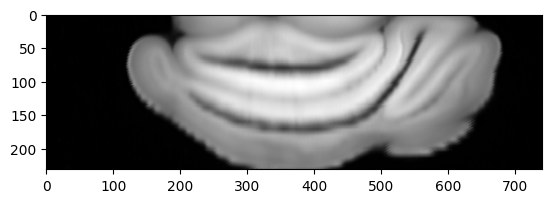

In [4]:
loaded = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025', 'roi_polygons.npz'), allow_pickle=True)
roi_polygons = {k: loaded[k] for k in loaded.files}
atlas_template = np.load(r'I:\Cerebellum_imaging_Dec2025\Registration\atlas_template_slice51.npy')
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template, cmap='gray')
roi_masks_full = polygons_to_masks(roi_polygons, atlas_template.shape)

In [5]:
agg_data = {}
behav_train_path = r'I:\Cerebellum_imaging_Dec2025\training_data'
ca_img_path = r'I:\Cerebellum_Imaging_Dec2025'
mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2'] 
#mouse_ids = ['AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'AF_L2'] 
# mouse_ids = ['J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            try:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
            frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
            arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
            arm1_dff_for_video = arm1_dff[:,tf_arm1_table_for_img['ruleCue_times'][0]:tf_arm1_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm1']['design_matrix']    # (T, P)
            F = arm1_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm1']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new
            mouse_data[date]['arm1']['unique_predictors_extended'] = list(unique_predictors) + ['left_choice_group', 'right_choice_group']
        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            try:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
            frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
            arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
            arm2_dff_for_video = arm2_dff[:,tf_arm2_table_for_img['ruleCue_times'][0]:tf_arm2_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm2']['design_matrix']    # (T, P)
            F = arm2_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm2']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new


        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:15]
    
    
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            if 'arm1' in mouse_data[date]:
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
                tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
                arm1_bsl_psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm1_bsl_psth = get_trial_PSTH(arm1_dff, arm1_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm1_bsl_psth = arm1_bsl_psth.reshape(arm1_bsl_psth.shape[0], -1)
                arm1_bsl_mean = np.mean(arm1_bsl_psth, axis=1)
                arm1_bsl_sd = np.std(arm1_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm1_bsl_mean[np.newaxis, :, np.newaxis]) / arm1_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
            if 'arm2' in mouse_data[date]:  
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy')) 
                tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
                arm2_bsl_psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm2_bsl_psth = get_trial_PSTH(arm2_dff, arm2_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm2_bsl_psth = arm2_bsl_psth.reshape(arm2_bsl_psth.shape[0], -1)
                arm2_bsl_mean = np.mean(arm2_bsl_psth, axis=1)
                arm2_bsl_sd = np.std(arm2_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm2_bsl_mean[np.newaxis, :, np.newaxis]) / arm2_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
    agg_data[mouse] = mouse_data
    

2026-06-08 10:56:22.814 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 117657  I:\Cerebellum_Imaging_Dec2025\AE_L2\20250729_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-06-08 10:58:55.659 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 113967  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250617_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-06-08 11:01:31.395 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 66038  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-06-08 11:01:31.399 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 177585  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_beha

In [109]:
def _as_bool_mask(x, n=None):
    x = np.asarray(x)
    if x.dtype == bool:
        out = x.copy()
    else:
        out = np.isfinite(x)
    if n is not None and out.size != n:
        raise ValueError(f"Mask length mismatch: {out.size} vs expected {n}")
    return out


def _timepoints_from_window(t0, t1, n_time, frames_per_s):
    """
    Matches the frame-index output from find_frame_indices approximately.
    """
    return t0 + np.arange(n_time) / frames_per_s


def _safe_standardize_train(X_train):
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0, ddof=1)
    sd[~np.isfinite(sd)] = 1.0
    sd[sd == 0] = 1.0
    return mu, sd


def _finite_col(df, col):
    if col not in df.columns:
        return np.zeros(len(df), dtype=bool)
    return np.isfinite(pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float))


def make_binary_labels_from_column(
    table,
    col,
    positive_value,
    negative_value,
    positive_label=1,
    negative_label=0,
):
    """
    For dense columns like:
      choice: -1 / 1
      feedbackType: -1 / 1
      modality: 0 / 1
      visual_trial: 0 / 1
    """
    vals = pd.to_numeric(table[col], errors="coerce").to_numpy()

    labels = np.full(len(table), np.nan)
    labels[vals == positive_value] = positive_label
    labels[vals == negative_value] = negative_label

    mask = np.isfinite(labels)
    return labels, mask


def make_binary_labels_from_event_columns(
    table,
    positive_cols,
    negative_cols,
    positive_label=1,
    negative_label=0,
):
    """
    For sparse event-time columns:
      left_vis_stimOn_times = frame index on matching trials, NaN otherwise
    """
    n = len(table)

    pos = np.zeros(n, dtype=bool)
    neg = np.zeros(n, dtype=bool)

    for c in positive_cols:
        pos |= pd.to_numeric(table[c], errors="coerce").notna().to_numpy()

    for c in negative_cols:
        neg |= pd.to_numeric(table[c], errors="coerce").notna().to_numpy()

    labels = np.full(n, np.nan)

    # require clean one-sided assignment
    labels[pos & ~neg] = positive_label
    labels[neg & ~pos] = negative_label

    mask = np.isfinite(labels)
    return labels, mask

def get_axis_labels(table, axis_name):
    """
    Returns:
      labels: array of 0/1/nan
      mask: valid trials
      label_names: dict mapping label value to readable condition
    """

    if axis_name in ["context_cue", "pre_stim_context_state"]:
        # In this table: modality 0 = visual, modality 1 = auditory
        labels, mask = make_binary_labels_from_column(
            table,
            col="modality",
            positive_value=0,   # visual
            negative_value=1,   # auditory
        )
        label_names = {1: "visual", 0: "auditory"}

    elif axis_name == "visual_stim_side":
        labels, mask = make_binary_labels_from_event_columns(
            table,
            positive_cols=["left_vis_stimOn_times"],
            negative_cols=["right_vis_stimOn_times"],
        )
        label_names = {1: "left visual stimulus", 0: "right visual stimulus"}

    elif axis_name == "auditory_stim_side":
        labels, mask = make_binary_labels_from_event_columns(
            table,
            positive_cols=["left_aud_stimOn_times"],
            negative_cols=["right_aud_stimOn_times"],
        )
        label_names = {1: "left auditory stimulus", 0: "right auditory stimulus"}

    elif axis_name == "all_stim_side":
        labels, mask = make_binary_labels_from_event_columns(
            table,
            positive_cols=["left_vis_stimOn_times", "left_aud_stimOn_times"],
            negative_cols=["right_vis_stimOn_times", "right_aud_stimOn_times"],
        )
        label_names = {1: "left stimulus", 0: "right stimulus"}

    elif axis_name == "choice_side":
        # Based on event-column check:
        # choice = -1 corresponds to left-choice event columns
        # choice =  1 corresponds to right-choice event columns
        labels, mask = make_binary_labels_from_column(
            table,
            col="choice",
            positive_value=-1,  # left choice
            negative_value=1,   # right choice
        )
        label_names = {1: "left choice", 0: "right choice"}

    elif axis_name == "outcome":
        labels, mask = make_binary_labels_from_column(
            table,
            col="feedbackType",
            positive_value=1,   # reward
            negative_value=-1,  # punish
        )
        label_names = {1: "reward", 0: "punish"}

    else:
        raise ValueError(f"Unknown axis_name: {axis_name}")

    return labels, mask, label_names

def add_common_event_columns(table):
    table = table.copy()

    if 'all_choice_times' not in table.columns and 'lastMovement_times' in table.columns:
        table['all_choice_times'] = pd.to_numeric(table['lastMovement_times'], errors='coerce') - 3

    if 'consume_times' not in table.columns:
        if 'reward_times' in table.columns and 'punish_times' in table.columns:
            table['consume_times'] = table['reward_times'].fillna(table['punish_times'])
        elif 'feedback_times' in table.columns:
            table['consume_times'] = table['feedback_times']
    if 'stimOn_times' in table.columns:
        table['stimOn_times'] = table["vis_stimOn_times"].combine_first(table["aud_stimOn_times"])

    return table

In [28]:
def loo_reconstruct_activity(neuron, X, preds, full_predictors, exact_match=True):
    """
    Reconstruct activity for a single neuron using the full model and a
    leave-one-out (LOO) version where all columns belonging to `pred` are removed
    (by zeroing their betas). No refitting is performed.

    Parameters
    ----------
    neuron : dict
        Must contain:
          - 'beta': (P,) or (1,P) array of weights for this neuron (matches X columns)
          - 'intercept': scalar
    X : array, shape (T, P)
        Design matrix used to fit the model (same column order as full_predictors).
    pred : list of str
        Unique predictor name to leave out (matches columns in `full_predictors`).
    full_predictors : list[str] of length P
        Names for each column of X (e.g., expanded supports for events).
    exact_match : bool, default True
        If True, match columns where name == pred or name startswith(pred).
        If False, use substring containment (pred in name).

    Returns
    -------
    y_full : (T,) ndarray
        Reconstruction with all predictors: X @ beta + intercept.
    y_loo : (T,) ndarray
        Reconstruction with `pred` columns removed (their contribution zeroed).
    contrib : (T,) ndarray
        The contribution of `pred` alone (y_full - y_loo).
    idx : (K,) ndarray
        Integer indices of columns belonging to `pred`.
    """
    beta = np.asarray(neuron['beta']).ravel()
    b0 = float(neuron.get('intercept', 0.0))

    if X.shape[1] != beta.size:
        raise ValueError(f"Shape mismatch: X has {X.shape[1]} columns but beta has {beta.size}.")

    # pick columns for this unique predictor
    all_idx = []
    if exact_match:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if (nm == pred) or nm.startswith(pred)],
                dtype=int
            )
            all_idx.append(idx)
    else:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if pred in nm],
                dtype=int
            )
            all_idx.append(idx)
    all_idx = np.concatenate(all_idx)
    #print(idx)
    # full reconstruction
    y_full = X @ beta + b0

    # contribution of the predictor's columns
    if all_idx.size > 0:
        contrib = X[:, all_idx] @ beta[all_idx]
    else:
        contrib = np.zeros(X.shape[0], dtype=float)

    # LOO reconstruction (remove that contribution)
    y_loo = y_full - contrib

    return y_full, y_loo, contrib

def build_residual_tensor(
    neurons,                 # list[dict], each has neuron['beta'], neuron['intercept'],
    dff,                     # (n_neurons, n_time), need to have same length as neurons
    design_matrix,           # (T_model, P)
    predictors,              # list[str] length P (column names for design_matrix)
    table_for_img,           # dict-like with trial info; needs ['ruleCue_times'] and label cols
    preds_to_exclude,        # list[str]; predictors to leave out (e.g., ['choice']), should be same as align_pred?
    psth_time_start,         # e.g., -1.0  (seconds; whatever your find_frame_indices expects)
    psth_time_end,           # e.g., 1.0
    align_pred,              # str passed to find_frame_indices, e.g., 'ruleCue' or your event name. the activity around which the prediction is made
    frames_per_s=15,         # your frame rate if find_frame_indices needs it
):
    """
    Returns:
      residual_tensor: (n_neurons, n_trials, n_time) ndarray
      psth_frame_idx:  (n_trials, n_time) ndarray of absolute frame indices used
      
    """
    assert(len(neurons) == dff.shape[0])
    # get the per-trial absolute frame indices covering the time window
    table_for_img['all_choice_times'] = (
        table_for_img['lastMovement_times'] - 3
    ).astype(float)
    # print(table_for_img['choice_times'].to_numpy())
    # print(np.sum(~np.isnan(table_for_img['choice_times'].to_numpy())))
    psth_frame_idx = find_frame_indices(
        table_for_img,
        frames_per_s,
        (psth_time_start, psth_time_end),
        align_pred
    ).astype(int)  # shape: (n_trials, n_time)
    #print(psth_frame_idx.shape)
    n_trials, n_time = psth_frame_idx.shape
    trial_mask = ~np.isnan(table_for_img[align_pred])
    # build residuals for each neuron
    pad_len = int(table_for_img['ruleCue_times'][0])  # how many zeros to pre-pad (your convention)
    residual_blocks = []

    for i, nrn in enumerate(neurons):
        # print('building residual tensor for neuron: ', i)
        # predict with LOO (exclude chosen predictors, no refit)
        if preds_to_exclude is not None and len(preds_to_exclude) > 0:
            _, y_loo, contrib = loo_reconstruct_activity(
                nrn, design_matrix, preds_to_exclude, full_predictors=predictors, exact_match=False
            )
            # align y_loo to F with the same pre-padding convention
            y_loo_aligned = np.concatenate([np.zeros(pad_len, dtype=float), y_loo])
            contrib_aligned = np.concatenate([np.zeros(pad_len, dtype=float), contrib])
            assert(len(y_loo_aligned) == table_for_img['intervals_1'].iloc[-1])
            assert(len(contrib_aligned) == table_for_img['intervals_1'].iloc[-1])
            # residual = raw - y_loo
            F = np.asarray(dff[i]).ravel()
            y_loo_aligned = np.concatenate([y_loo_aligned, np.zeros(len(F)-len(y_loo_aligned), dtype=float)])
            contrib_aligned = np.concatenate([contrib_aligned, np.zeros(len(F)-len(contrib_aligned), dtype=float)])
            if F.shape[0] != y_loo_aligned.shape[0]:
                raise ValueError(f"Length mismatch: F={F.shape[0]} vs y_loo_aligned={y_loo_aligned.shape[0]}")
            resid = F - y_loo_aligned
            #resid = contrib_aligned
        else:
            resid = dff[i]  # if no predictors to exclude, just use raw activity as "residual"
        # slice residuals into (n_trials, n_time) via advanced indexing
        # (broadcasting: for each trial row, grab those absolute frames)
        resid_trials_time = resid[psth_frame_idx]  # shape (n_trials, n_time)
        residual_blocks.append(resid_trials_time)

    residual_tensor = np.stack(residual_blocks, axis=0)  # (n_neurons, n_trials, n_time)
    return residual_tensor, psth_frame_idx, trial_mask





In [29]:
def assign_neuron_to_roi(
    neuron,
    roi_masks_bool,      # dict[str] -> (H,W) bool
    frac_thresh=0.2,
):
    """
    Returns (best_roi, best_frac) or (None, 0.0) if no ROI meets thresh.
    """
    if ('xcoord_atlas' not in neuron) or ('ycoord_atlas' not in neuron):
        return None, 0.0

    x = np.asarray(neuron['xcoord_atlas'], dtype=int)
    y = np.asarray(neuron['ycoord_atlas'], dtype=int)
    if x.size == 0 or y.size == 0:
        return None, 0.0

    best_roi = None
    best_frac = 0.0

    for roi_name, roi_mask in roi_masks_bool.items():
        H, W = roi_mask.shape
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue

        xx = x[ok]
        yy = y[ok]
        n_pix_total = xx.size
        if n_pix_total == 0:
            continue

        n_pix_in_roi = np.count_nonzero(roi_mask[yy, xx])
        frac_in_roi = n_pix_in_roi / n_pix_total

        if frac_in_roi > best_frac:
            best_frac = frac_in_roi
            best_roi = roi_name

    if best_roi is not None and best_frac > frac_thresh:
        return best_roi, float(best_frac)
    return None, 0.0

def group_neurons_by_roi(
    neurons,             # list of neuron dicts (stats)
    roi_masks_full,      # dict[str] -> (H,W) mask (any dtype)
    roi_order=None,
    frac_thresh=0.2,
    require_reward_psth=True,
):
    """
    Returns:
      roi_to_neurons: dict[roi] -> list of neuron dicts assigned to that roi
      roi_counts: dict[roi] -> int
      unassigned: list of neuron dicts
      roi_order: final roi order used
    """
    roi_masks_bool = {r: np.asarray(m, dtype=bool) for r, m in roi_masks_full.items()}
    if roi_order is None:
        roi_order = list(roi_masks_bool.keys())

    roi_to_neurons = {roi: [] for roi in roi_order}
    roi_neuron_idx = {roi: [] for roi in roi_order}
    unassigned = []

    for i, neuron in enumerate(neurons):
        if require_reward_psth:
            if ('vis_reward_times_psth' not in neuron) or ('aud_reward_times_psth' not in neuron):
                continue

        roi, frac = assign_neuron_to_roi(neuron, roi_masks_bool, frac_thresh=frac_thresh)
        if roi is None:
            unassigned.append(neuron)
        else:
            # if roi not in roi_order for some reason, skip or add dynamically:
            if roi not in roi_to_neurons:
                roi_to_neurons[roi] = []
            roi_to_neurons[roi].append(neuron)
            roi_neuron_idx[roi].append(i)

    roi_counts = {roi: len(lst) for roi, lst in roi_to_neurons.items()}
    return roi_to_neurons, roi_neuron_idx, roi_counts, unassigned, roi_order

In [ ]:
@dataclass
class AxisSpec:
    name: str
    align_pred: str
    traj_window: tuple
    train_window: tuple
    positive_label_name: str
    negative_label_name: str

    # exactly one of these label definitions should be used
    positive_event_cols: tuple = None
    negative_event_cols: tuple = None
    label_col: str = None
    positive_col_value: float = None
    negative_col_value: float = None

    # which model predictors to retain in residual activity
    # If None, uses raw fluorescence.
    preds_to_exclude: tuple = None


def fit_axis_and_project(
    residual_tensor,        # neurons x trials x time
    labels,                 # trials
    trial_mask,             # trials
    timepoints,             # time
    train_window,           # seconds relative to align_pred
    positive_label=1,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    max_iter=5000,
    min_trials_per_class=10,
):
    """
    Train one linear decoder in a fixed window and project held-out full trajectories.

    Returns
    -------
    result : dict
        Contains projection, weights, fold accuracies, AUC, labels, etc.
    """

    Y = np.asarray(residual_tensor, dtype=np.float32)  # neurons x trials x time
    n_neurons, n_trials, n_time = Y.shape
    #print(f'residual_tensor shape: {Y.shape}')
    labels = np.asarray(labels).ravel()
    if labels.size != n_trials:
        raise ValueError("labels length must match residual_tensor trials.")

    trial_mask = _as_bool_mask(trial_mask, n_trials)
    label_mask = np.isfinite(labels)
    valid = trial_mask & label_mask

    y_valid = labels[valid]
    classes, counts = np.unique(y_valid, return_counts=True)

    if len(classes) != 2:
        raise ValueError(f"Need exactly two classes after masking. Got {classes}")

    if np.min(counts) < min_trials_per_class:
        raise ValueError(f"Too few trials per class: {dict(zip(classes, counts))}")

    # Ensure labels are 0/1 with positive class = 1.
    y_binary = np.zeros_like(labels, dtype=float)
    y_binary[:] = np.nan
    y_binary[labels == positive_label] = 1
    y_binary[(labels != positive_label) & np.isfinite(labels)] = 0

    valid_idx = np.where(valid)[0]
    y = y_binary[valid_idx].astype(int)

    # axis-defining time window
    train_mask_t = (timepoints >= train_window[0]) & (timepoints <= train_window[1])
    if not np.any(train_mask_t):
        raise ValueError(f"No timepoints found in train_window={train_window}")

    # Average neural activity in training window: trials x neurons
    X_all = np.nanmean(Y[:, :, train_mask_t], axis=2).T  # trials x neurons
    X_valid = X_all[valid_idx]

    skf = StratifiedKFold(
        n_splits=min(n_splits, np.min(np.bincount(y))),
        shuffle=True,
        random_state=random_state
    )

    projection = np.full((n_trials, n_time), np.nan, dtype=np.float32)
    fold_weights = []
    fold_intercepts = []
    fold_acc = []
    fold_bal_acc = []
    fold_auc = []
    fold_info = []

    for fold_i, (tr, te) in enumerate(skf.split(X_valid, y)):
        Xtr = X_valid[tr]
        Xte = X_valid[te]
        ytr = y[tr]
        yte = y[te]

        mu, sd = _safe_standardize_train(Xtr)
        Xtrz = (Xtr - mu) / sd
        Xtez = (Xte - mu) / sd

        clf = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=l1_ratio,
            C=C,
            max_iter=max_iter,
            tol=1e-3,
            random_state=random_state + fold_i,
            n_jobs=1,
        )
        clf.fit(Xtrz, ytr)

        w = clf.coef_.ravel().astype(float)
        b = float(clf.intercept_[0])

        # Sign convention: positive projection should mean positive_label.
        train_proj = Xtrz @ w
        if np.nanmean(train_proj[ytr == 1]) < np.nanmean(train_proj[ytr == 0]):
            w *= -1
            b *= -1

        # Decode performance in the axis-defining window.
        test_proj = Xtez @ w + b
        yhat = (test_proj > 0).astype(int)

        fold_acc.append(np.mean(yhat == yte))
        fold_bal_acc.append(balanced_accuracy_score(yte, yhat))

        try:
            fold_auc.append(roc_auc_score(yte, test_proj))
        except Exception:
            fold_auc.append(np.nan)

        # Project the whole trajectory for held-out trials.
        test_global_idx = valid_idx[te]

        # trials x time x neurons
        Y_test = np.transpose(Y[:, test_global_idx, :], (1, 2, 0))

        # standardize each neuron using training-window train-trial statistics
        Y_test_z = (Y_test - mu[None, None, :]) / sd[None, None, :]

        # trials x time
        proj_test = np.einsum("btn,n->bt", Y_test_z, w)
        projection[test_global_idx, :] = proj_test.astype(np.float32)

        fold_weights.append(w)
        fold_intercepts.append(b)
        fold_info.append({
            "fold": fold_i,
            "train_idx_global": valid_idx[tr],
            "test_idx_global": test_global_idx,
            "mu": mu,
            "sd": sd,
        })

    result = {
        "projection": projection,          # trials x time, held-out only
        "labels": labels,
        "labels_binary": y_binary,
        "valid_mask": valid,
        "timepoints": np.asarray(timepoints),
        "train_window": train_window,
        "fold_weights": fold_weights,
        "fold_intercepts": fold_intercepts,
        "fold_info": fold_info,
        "acc": np.asarray(fold_acc),
        "acc_bal": np.asarray(fold_bal_acc),
        "auc": np.asarray(fold_auc),
        "mean_acc": float(np.nanmean(fold_acc)),
        "mean_bal_acc": float(np.nanmean(fold_bal_acc)),
        "mean_auc": float(np.nanmean(fold_auc)),
        "n_neurons": int(n_neurons),
        "n_trials": int(np.sum(valid)),
        "class_counts": dict(zip(classes.tolist(), counts.tolist())),
    }

    return result

In [55]:
def _resolve_dff_path(mouse, date, arm, dff_root=None):
    """
    Find dff file for one mouse/date/arm.

    Set dff_root explicitly if your path is different.
    """
    candidate_roots = []

    if dff_root is not None:
        candidate_roots.append(dff_root)

    # Common variants from your code.
    candidate_roots.extend([
        r"I:\Cerebellum_imaging_Dec2025",
        r"I:\Cerebellum_Imaging_Dec2025",
    ])

    for root in candidate_roots:
        p = os.path.join(
            root,
            mouse,
            date,
            arm,
            "dff_moving_percentile_pc_lowpass_0p5hz.npy",
        )
        if os.path.exists(p):
            return p

    raise FileNotFoundError(
        f"Could not find dff file for {mouse} {date} {arm}. "
        f"Pass dff_root explicitly."
    )


def _combine_trial_masks(arm_blocks):
    """
    Combine trial masks across arms. This is safer than assuming arm1 and arm2
    have exactly identical valid event windows.
    """
    if len(arm_blocks) == 0:
        raise ValueError("No arm_blocks.")

    common = arm_blocks[0]["trial_mask"].copy()
    for blk in arm_blocks[1:]:
        common &= blk["trial_mask"]

    return common


def _check_labels_compatible(arm_blocks):
    """
    Labels should be identical across arm1 and arm2 because they come from the
    same behavioral trial table. This checks that assumption.
    """
    labels0 = arm_blocks[0]["labels"]

    for blk in arm_blocks[1:]:
        labels_i = blk["labels"]

        if len(labels_i) != len(labels0):
            raise ValueError(
                f"Trial count mismatch across arms: {len(labels0)} vs {len(labels_i)}"
            )

        ok = (
            (np.isnan(labels0) & np.isnan(labels_i)) |
            (labels0 == labels_i)
        )

        if not np.all(ok):
            raise ValueError("Labels are not identical across arms.")

    return labels0


def _check_timepoints_compatible(arm_blocks):
    """
    Timepoints should be identical across arms for a given axis.
    """
    timepoints0 = arm_blocks[0]["timepoints"]

    for blk in arm_blocks[1:]:
        if len(blk["timepoints"]) != len(timepoints0):
            raise ValueError("Timepoint length mismatch across arms.")

        if not np.allclose(blk["timepoints"], timepoints0):
            raise ValueError("Timepoints are not identical across arms.")

    return timepoints0


def _fit_population_axis(
    tensor,
    labels,
    trial_mask,
    timepoints,
    axis_name,
    spec,
    label_names,
    mouse,
    date,
    population,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    min_trials_per_class=10,
):
    """
    Small wrapper around fit_axis_and_project that adds metadata.
    """
    res = fit_axis_and_project(
        residual_tensor=tensor,
        labels=labels,
        trial_mask=trial_mask,
        timepoints=timepoints,
        train_window=spec["train_window"],
        positive_label=1,
        n_splits=n_splits,
        C=C,
        l1_ratio=l1_ratio,
        random_state=random_state,
        min_trials_per_class=min_trials_per_class,
    )

    res.update({
        "mouse": mouse,
        "date": date,
        "axis": axis_name,
        "population": population,
        "align_col": spec["align_col"],
        "traj_window": spec["traj_window"],
        "train_window": spec["train_window"],
        "target_predictors": spec.get("target_predictors", None),
        "positive_label_name": label_names[1],
        "negative_label_name": label_names[0],
    })

    return res



In [110]:
def decode_axis_one_session(
    agg_data,
    mouse,
    date,
    axis_name,
    axis_specs,
    predictors,
    roi_masks_full=None,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    frac_thresh=0.2,
    include_all=True,
    frames_per_s=15,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    min_neurons=20,
    min_trials_per_class=10,
    require_reward_psth=False,
    dff_root=None,
    activity_mode="target_retained_residual",
    verbose=True,
    return_debug_tensors=False,
):
    """
    Decode one fixed task axis in one mouse/date.

    Important convention
    --------------------
    build_residual_tensor returns:
        residual_tensor: neurons x valid_trials x time
        event_trial_mask: bool mask in original trial coordinates

    Therefore labels must be compressed as:
        labels = labels_full[event_trial_mask]

    not:
        labels = labels_full[:residual_tensor.shape[1]]
    """

    if axis_name not in axis_specs:
        raise KeyError(f"{axis_name} not found in axis_specs.")

    spec = axis_specs[axis_name]
    session = agg_data[mouse][date]
    out = {}
    debug_tensors = {}

    # Determine activity mode
    if activity_mode == "target_retained_residual":
        preds_to_exclude = spec.get("target_predictors", None)
    elif activity_mode == "raw":
        preds_to_exclude = None
    else:
        raise ValueError(
            "activity_mode must be 'target_retained_residual' or 'raw'."
        )

    # ------------------------------------------------------------
    # Build arm-level tensors
    # ------------------------------------------------------------
    arm_blocks = []

    for arm in ("arm1", "arm2"):
        if arm not in session:
            continue

        arm_session = session[arm]
        neurons = list(arm_session["stat"])
        table = add_common_event_columns(arm_session["table_for_img"])
        design_matrix = arm_session["design_matrix"]

        labels_full, label_mask_full, label_names = get_axis_labels(table, axis_name)

        dff_path = _resolve_dff_path(
            mouse=mouse,
            date=date,
            arm=arm,
            dff_root=dff_root,
        )
        dff = np.load(dff_path)

        residual_tensor, frame_idx, event_trial_mask = build_residual_tensor(
            neurons=neurons,
            dff=dff,
            design_matrix=design_matrix,
            predictors=predictors,
            table_for_img=table,
            preds_to_exclude=preds_to_exclude,
            psth_time_start=spec["traj_window"][0],
            psth_time_end=spec["traj_window"][1],
            align_pred=spec["align_col"],
            frames_per_s=frames_per_s,
        )

        if residual_tensor is None:
            if verbose:
                print(f"[{mouse} {date} {arm} {axis_name}] skipped: residual_tensor is None")
            continue

        # ------------------------------------------------------------
        # Critical label compression
        # ------------------------------------------------------------
        event_trial_mask = np.asarray(event_trial_mask, dtype=bool)

        labels = np.asarray(labels_full)[event_trial_mask]
        label_mask = np.asarray(label_mask_full, dtype=bool)[event_trial_mask]

        n_trials_tensor = residual_tensor.shape[1]
        if len(labels) != n_trials_tensor:
            raise ValueError(
                f"{mouse} {date} {arm} {axis_name}: "
                f"labels after event_trial_mask do not match tensor trials. "
                f"len(labels)={len(labels)}, tensor trials={n_trials_tensor}, "
                f"sum(event_trial_mask)={np.sum(event_trial_mask)}"
            )

        # Local mask in tensor-trial coordinates.
        trial_mask = label_mask.copy()

        # Match old choice behavior: exclude 0 choices if any remain.
        # Usually redundant if get_axis_labels already maps only -1/1.
        if axis_name == "choice_side":
            trial_mask &= np.isfinite(labels)

        # Match old decoder timepoint convention for debugging.
        timepoints = np.linspace(
            spec["traj_window"][0],
            spec["traj_window"][1],
            residual_tensor.shape[2],
        )

        # ------------------------------------------------------------
        # ROI assignment, computed once per arm
        # ------------------------------------------------------------
        roi_neuron_idx = None
        roi_counts = None

        if roi_masks_full is not None:
            _, roi_neuron_idx, roi_counts, _, _ = group_neurons_by_roi(
                neurons,
                roi_masks_full=roi_masks_full,
                roi_order=list(roi_order),
                frac_thresh=frac_thresh,
                require_reward_psth=require_reward_psth,
            )

        arm_blocks.append({
            "arm": arm,
            "neurons": neurons,
            "tensor": residual_tensor,          # neurons x valid_trials x time
            "labels": labels,                   # valid_trials
            "trial_mask": trial_mask,           # valid_trials
            "base_trial_mask": event_trial_mask, # original trial coordinates
            "timepoints": timepoints,
            "label_names": label_names,
            "roi_neuron_idx": roi_neuron_idx,
            "roi_counts": roi_counts,
            "frame_idx": frame_idx,
        })

        if verbose:
            n_pos = int(np.sum(trial_mask & (labels == 1)))
            n_neg = int(np.sum(trial_mask & (labels == 0)))
            print(
                f"{mouse} {date} {arm} | {axis_name}: "
                f"neurons={len(neurons)}, tensor trials={n_trials_tensor}, "
                f"valid decode trials={np.sum(trial_mask)}, "
                f"{label_names[1]}={n_pos}, {label_names[0]}={n_neg}"
            )

    if len(arm_blocks) == 0:
        raise RuntimeError(f"No valid arm data found for {mouse} {date} {axis_name}")

    # ------------------------------------------------------------
    # Check arm compatibility
    # ------------------------------------------------------------
    labels0 = arm_blocks[0]["labels"]
    trial_mask0 = arm_blocks[0]["trial_mask"]
    timepoints0 = arm_blocks[0]["timepoints"]
    label_names0 = arm_blocks[0]["label_names"]
    base_trial_mask0 = arm_blocks[0]["base_trial_mask"]

    for blk in arm_blocks[1:]:
        if not np.array_equal(base_trial_mask0, blk["base_trial_mask"]):
            raise ValueError(
                f"{mouse} {date} {axis_name}: arm1/arm2 event trial masks differ. "
                "Cannot concatenate neurons across arms safely."
            )

        if len(blk["labels"]) != len(labels0):
            raise ValueError(
                f"{mouse} {date} {axis_name}: arm labels length mismatch after event masking."
            )

        ok_labels = (
            (np.isnan(labels0) & np.isnan(blk["labels"])) |
            (labels0 == blk["labels"])
        )
        if not np.all(ok_labels):
            raise ValueError(
                f"{mouse} {date} {axis_name}: arm labels differ after event masking."
            )

        if not np.array_equal(trial_mask0, blk["trial_mask"]):
            raise ValueError(
                f"{mouse} {date} {axis_name}: arm tensor-local trial masks differ."
            )

        if not np.allclose(timepoints0, blk["timepoints"]):
            raise ValueError(
                f"{mouse} {date} {axis_name}: arm timepoints differ."
            )

    # ------------------------------------------------------------
    # All neurons pooled across arms
    # ------------------------------------------------------------
    if include_all:
        tensor_all = np.concatenate(
            [blk["tensor"] for blk in arm_blocks],
            axis=0,
        )

        if return_debug_tensors:
            debug_tensors["all"] = {
                "tensor": tensor_all,
                "labels": labels0.copy(),
                "trial_mask": trial_mask0.copy(),
                "base_trial_mask": base_trial_mask0.copy(),
                "timepoints": timepoints0.copy(),
                "label_names": label_names0.copy(),
                "axis_name": axis_name,
                "mouse": mouse,
                "date": date,
                "population": "all",
                "align_col": spec["align_col"],
                "train_window": spec["train_window"],
                "traj_window": spec["traj_window"],
                "activity_mode": activity_mode,
            }

        if tensor_all.shape[0] >= min_neurons:
            try:
                out["all"] = _fit_population_axis(
                    tensor=tensor_all,
                    labels=labels0,
                    trial_mask=trial_mask0,
                    timepoints=timepoints0,
                    axis_name=axis_name,
                    spec=spec,
                    label_names=label_names0,
                    mouse=mouse,
                    date=date,
                    population="all",
                    n_splits=n_splits,
                    C=C,
                    l1_ratio=l1_ratio,
                    random_state=random_state,
                    min_trials_per_class=min_trials_per_class,
                )
            except ValueError as e:
                if verbose:
                    print(f"[{mouse} {date} all {axis_name}] skipped: {e}")
        else:
            if verbose:
                print(
                    f"[{mouse} {date} all {axis_name}] skipped: "
                    f"too few neurons ({tensor_all.shape[0]} < {min_neurons})"
                )

    # ------------------------------------------------------------
    # ROI-specific populations
    # ------------------------------------------------------------
    if roi_masks_full is not None:
        for roi in roi_order:
            roi_tensors = []
            contributing_arms = []

            for blk in arm_blocks:
                roi_neuron_idx = blk["roi_neuron_idx"]
                if roi_neuron_idx is None:
                    continue

                idx = roi_neuron_idx.get(roi, [])
                if len(idx) == 0:
                    continue

                idx = np.asarray(idx, dtype=int)
                roi_tensors.append(blk["tensor"][idx, :, :])
                contributing_arms.append(blk["arm"])

            if len(roi_tensors) == 0:
                continue

            tensor_roi = np.concatenate(roi_tensors, axis=0)

            if tensor_roi.shape[0] < min_neurons:
                if verbose:
                    print(
                        f"[{mouse} {date} {roi} {axis_name}] skipped: "
                        f"too few neurons ({tensor_roi.shape[0]} < {min_neurons})"
                    )
                continue

            # Since arm masks were already checked compatible, use trial_mask0.
            trial_mask_roi = trial_mask0.copy()

            if return_debug_tensors:
                debug_tensors[roi] = {
                    "tensor": tensor_roi,
                    "labels": labels0.copy(),
                    "trial_mask": trial_mask_roi.copy(),
                    "base_trial_mask": base_trial_mask0.copy(),
                    "timepoints": timepoints0.copy(),
                    "label_names": label_names0.copy(),
                    "axis_name": axis_name,
                    "mouse": mouse,
                    "date": date,
                    "population": roi,
                    "contributing_arms": contributing_arms,
                    "align_col": spec["align_col"],
                    "train_window": spec["train_window"],
                    "traj_window": spec["traj_window"],
                    "activity_mode": activity_mode,
                }

            try:
                res = _fit_population_axis(
                    tensor=tensor_roi,
                    labels=labels0,
                    trial_mask=trial_mask_roi,
                    timepoints=timepoints0,
                    axis_name=axis_name,
                    spec=spec,
                    label_names=label_names0,
                    mouse=mouse,
                    date=date,
                    population=roi,
                    n_splits=n_splits,
                    C=C,
                    l1_ratio=l1_ratio,
                    random_state=random_state,
                    min_trials_per_class=min_trials_per_class,
                )
            except ValueError as e:
                if verbose:
                    print(f"[{mouse} {date} {roi} {axis_name}] skipped: {e}")
                continue

            out[roi] = res

    if return_debug_tensors:
        out["_debug_tensors"] = debug_tensors

    return out

In [10]:
mouse = "AE_L3"
date = [d for d in agg_data[mouse].keys() if str(d).startswith("202")][0]
print(date)
print(agg_data[mouse][date]["arm1"]["table_for_img"].columns.tolist())

20250612
['intervals_0', 'intervals_1', 'ruleCue_times', 'ruleCueTrigger_times', 'response_times', 'choice', 'stimOnTrigger_times', 'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume', 'probabilityLeft', 'firstMovement_times', 'modality', 'omission', 'vis_stimOn_times', 'aud_stimOn_times', 'lastMovement_times', 'reward_times', 'punish_times', 'omission_times', 'visual_trial', 'aud_trial', 'vis_reward_times', 'aud_reward_times', 'vis_punish_times', 'aud_punish_times', 'vis_ruleCue_times', 'aud_ruleCue_times', 'left_vis_stimOn_times', 'right_vis_stimOn_times', 'left_aud_stimOn_times', 'right_aud_stimOn_times', 'vis_left_choice_times', 'vis_right_choice_times', 'aud_left_choice_times', 'aud_right_choice_times', 'previous_feedbackType', 'reward_history']


In [117]:
axis_specs = {
    "context_cue": {
        "align_col": "ruleCue_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.3),
        "target_predictors": ["vis_ruleCue_times", "aud_ruleCue_times"],
    },

    "pre_stim_context_state": {
        "align_col": "stimOn_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (-0.3, -0.1),
        "target_predictors": ["vis_ruleCue_times", "aud_ruleCue_times"],
    },

    "visual_stim_side": {
        "align_col": "vis_stimOn_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.3),
        "target_predictors": ["left_vis_stimOn_times", "right_vis_stimOn_times"],
    },

    "auditory_stim_side": {
        "align_col": "aud_stimOn_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.3),
        "target_predictors": ["left_aud_stimOn_times", "right_aud_stimOn_times"],
    },

    "all_stim_side": {
        "align_col": "stimOn_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.3),
        "target_predictors": [
            "left_vis_stimOn_times", "right_vis_stimOn_times",
            "left_aud_stimOn_times", "right_aud_stimOn_times",
        ],
    },

    "choice_side": {
        "align_col": "all_choice_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.2),
        "target_predictors": [
            "vis_left_choice_times", "vis_right_choice_times",
            "aud_left_choice_times", "aud_right_choice_times",
        ],
    },

    "outcome": {
        "align_col": "feedback_times",
        "traj_window": (-0.4, 1.2),
        "train_window": (0.0, 0.8),
        "target_predictors": [
            "vis_reward_times", "aud_reward_times",
            "vis_punish_times", "aud_punish_times",
        ],
    },
}

In [34]:
def summarize_axis_labels(table, axis_names=None):
    if axis_names is None:
        axis_names = [
            "context_cue",
            "pre_stim_context_state",
            "visual_stim_side",
            "auditory_stim_side",
            "all_stim_side",
            "choice_side",
            "outcome",
        ]

    rows = []

    for axis_name in axis_names:
        labels, mask, label_names = get_axis_labels(table, axis_name)

        n_pos = np.sum(mask & (labels == 1))
        n_neg = np.sum(mask & (labels == 0))
        n_valid = np.sum(mask)
        n_invalid = len(table) - n_valid

        rows.append({
            "axis": axis_name,
            "positive": label_names[1],
            "negative": label_names[0],
            "n_positive": int(n_pos),
            "n_negative": int(n_neg),
            "n_valid": int(n_valid),
            "n_invalid": int(n_invalid),
        })

    return pd.DataFrame(rows)

In [17]:
mouse = "AE_L3"
date = [d for d in agg_data[mouse].keys() if str(d).startswith("202")][2]
summarize_axis_labels(agg_data[mouse][date]["arm1"]["table_for_img"])

,axis,positive,negative,n_positive,n_negative,n_valid,n_invalid
0,context_cue,visual,auditory,151,150,301,0
1,pre_stim_context_state,visual,auditory,151,150,301,0
2,visual_stim_side,left visual stimulus,right visual stimulus,73,78,151,150
3,auditory_stim_side,left auditory stimulus,right auditory stimulus,61,89,150,151
4,all_stim_side,left stimulus,right stimulus,134,167,301,0
5,choice_side,left choice,right choice,138,163,301,0
6,outcome,reward,punish,132,169,301,0


In [118]:
axis_name = "pre_stim_context_state"
mouse = "AE_L3"
for date in agg_data[mouse].keys():
    if date.startswith("training"):
        continue
    res_prestim_residual = decode_axis_one_session(
        agg_data=agg_data,
        mouse=mouse,
        date=date,
        axis_name=axis_name,
        axis_specs=axis_specs,
        predictors=predictors,
        roi_masks_full=roi_masks_full,
        roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
        frac_thresh=0.2,
        include_all=True,
        frames_per_s=15,
        n_splits=5,
        C=1.0,
        l1_ratio=1.0,
        random_state=0,
        min_neurons=20,
        min_trials_per_class=10,
        require_reward_psth=False,
        dff_root=r"I:\Cerebellum_Imaging_Dec2025",
        activity_mode="target_retained_residual",
        verbose=True,
        return_debug_tensors=True,
    )

    for pop, r in res_prestim_residual.items():
        if pop.startswith("_debug_tensors"):
            continue
        print(
            pop,
            "n_neurons =", r["n_neurons"],
            "n_trials =", r["n_trials"],
            "AUC =", np.round(r["mean_auc"], 3),
            "bal acc =", np.round(r["mean_bal_acc"], 3),
        )

AE_L3 20250612 arm1 | pre_stim_context_state: neurons=637, tensor trials=248, valid decode trials=248, visual=128, auditory=120
AE_L3 20250612 arm2 | pre_stim_context_state: neurons=605, tensor trials=248, valid decode trials=248, visual=128, auditory=120
residual_tensor shape: (1242, 248, 25)
residual_tensor shape: (312, 248, 25)
residual_tensor shape: (267, 248, 25)
residual_tensor shape: (358, 248, 25)
residual_tensor shape: (221, 248, 25)
all n_neurons = 1242 n_trials = 248 AUC = 0.668 bal acc = 0.627
lob_V n_neurons = 312 n_trials = 248 AUC = 0.582 bal acc = 0.552
lob_VI n_neurons = 267 n_trials = 248 AUC = 0.504 bal acc = 0.505
simplex n_neurons = 358 n_trials = 248 AUC = 0.733 bal acc = 0.649
crus_I n_neurons = 221 n_trials = 248 AUC = 0.535 bal acc = 0.52
AE_L3 20250617_valvesilent arm1 | pre_stim_context_state: neurons=636, tensor trials=319, valid decode trials=319, visual=159, auditory=160
AE_L3 20250617_valvesilent arm2 | pre_stim_context_state: neurons=657, tensor trials=3

In [94]:
neural_decoding_res = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025\AE_L3', 'choice_residual_neural_decoding_choice_by_roi_shuffled_results_auc.pkl'), allow_pickle=True)

In [99]:
neural_decoding_res[11]['all']['auc']

array([0.54749388, 0.52635748, 0.54850209, 0.49492294, 0.57716405,
       0.46651303, 0.55037448, 0.65548034, 0.77142446, 0.80170676,
       0.77185655, 0.61335158, 0.60294541, 0.66725479, 0.58724615,
       0.66955927, 0.58904652, 0.67157569, 0.59848048, 0.53478323,
       0.64601037, 0.55293101, 0.54522541, 0.56650583, 0.54893418])

In [78]:
def plot_choice_single_neuron_traces(
    debug,
    sort_window=(0.0, 0.3),
    neuron_indices=None,
    n_neurons=12,
    n_cols=4,
    smooth=False,
    show_sem=True,
    title=None,
):
    """
    Plot single-neuron left/right choice PSTH traces.

    Parameters
    ----------
    debug : dict
        One entry from out["_debug_tensors"], e.g. out["_debug_tensors"]["all"].

    neuron_indices : array-like or None
        If provided, plot these neuron indices.
        If None, plot neurons with strongest |left-right| modulation in sort_window.

    n_neurons : int
        Number of neurons to plot if neuron_indices is None.

    Tensor shape
    ------------
    tensor: neurons x trials x time

    Labels
    ------
    labels == 1: positive class, here left choice
    labels == 0: negative class, here right choice
    """

    tensor = np.asarray(debug["tensor"], dtype=float)
    labels = np.asarray(debug["labels"])
    trial_mask = np.asarray(debug["trial_mask"], dtype=bool)
    timepoints = np.asarray(debug["timepoints"])
    label_names = debug["label_names"]

    left_mask = trial_mask & (labels == 1)
    right_mask = trial_mask & (labels == 0)

    left_data = tensor[:, left_mask, :]     # neurons x left_trials x time
    right_data = tensor[:, right_mask, :]   # neurons x right_trials x time

    left_mean = np.nanmean(left_data, axis=1)     # neurons x time
    right_mean = np.nanmean(right_data, axis=1)

    if show_sem:
        left_sem = np.nanstd(left_data, axis=1, ddof=1) / np.sqrt(np.sum(left_mask))
        right_sem = np.nanstd(right_data, axis=1, ddof=1) / np.sqrt(np.sum(right_mask))
    else:
        left_sem = np.zeros_like(left_mean)
        right_sem = np.zeros_like(right_mean)

    if smooth:
        from scipy.ndimage import gaussian_filter1d
        left_mean = gaussian_filter1d(left_mean, sigma=1, axis=1)
        right_mean = gaussian_filter1d(right_mean, sigma=1, axis=1)
        left_sem = gaussian_filter1d(left_sem, sigma=1, axis=1)
        right_sem = gaussian_filter1d(right_sem, sigma=1, axis=1)

    # Choose neurons
    if neuron_indices is None:
        sort_mask = (timepoints >= sort_window[0]) & (timepoints <= sort_window[1])
        diff = left_mean - right_mean
        pref = np.nanmean(diff[:, sort_mask], axis=1)
        strength_order = np.argsort(np.abs(pref))[::-1]
        neuron_indices = strength_order[:n_neurons]
    else:
        neuron_indices = np.asarray(neuron_indices, dtype=int)
        n_neurons = len(neuron_indices)

    n_rows = int(np.ceil(n_neurons / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.2 * n_cols, 2.4 * n_rows),
        sharex=True,
        sharey=False,
    )

    axes = np.asarray(axes).ravel()

    for ax_i, neuron_idx in enumerate(neuron_indices):
        ax = axes[ax_i]

        lm = left_mean[neuron_idx]
        rm = right_mean[neuron_idx]
        ls = left_sem[neuron_idx]
        rs = right_sem[neuron_idx]

        ax.plot(timepoints, lm, label=label_names[1])
        if show_sem:
            ax.fill_between(timepoints, lm - ls, lm + ls, alpha=0.25)

        ax.plot(timepoints, rm, label=label_names[0])
        if show_sem:
            ax.fill_between(timepoints, rm - rs, rm + rs, alpha=0.25)

        ax.axvline(0, color="k", lw=1, alpha=0.7)
        ax.axhline(0, color="k", lw=0.75, alpha=0.25)

        # quantify preference in sort window
        sort_mask = (timepoints >= sort_window[0]) & (timepoints <= sort_window[1])
        pref_val = np.nanmean(lm[sort_mask] - rm[sort_mask])

        ax.set_title(f"Neuron {neuron_idx} | Δ={pref_val:.2f}", fontsize=9)

        if ax_i % n_cols == 0:
            ax.set_ylabel("Activity")
        if ax_i >= (n_rows - 1) * n_cols:
            ax.set_xlabel("Time from alignment (s)")

    # Turn off unused axes
    for j in range(len(neuron_indices), len(axes)):
        axes[j].set_axis_off()

    axes[0].legend(frameon=False, fontsize=8)

    if title is None:
        title = (
            f"{debug['mouse']} {debug['date']} | {debug['population']} | "
            f"{debug['axis_name']} | {debug['activity_mode']}"
        )

    fig.suptitle(title)
    plt.tight_layout()

    return fig, axes, neuron_indices

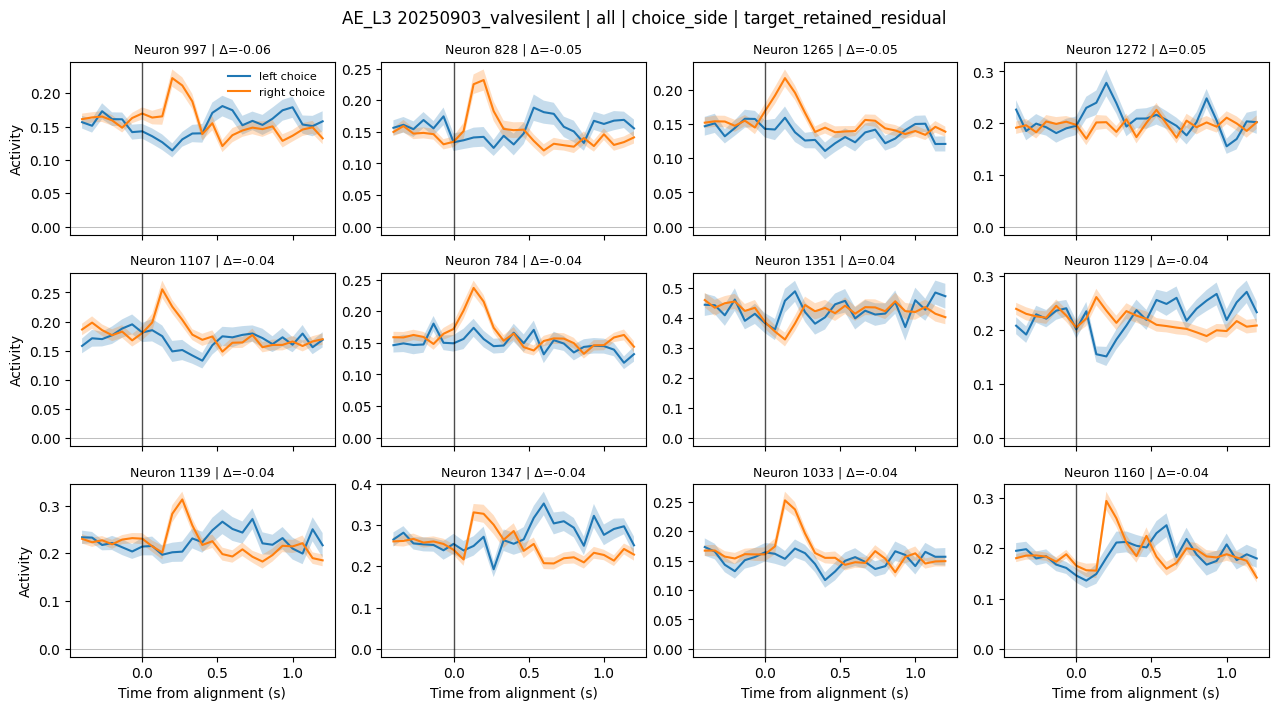

In [104]:
debug_all = res_choice_raw["_debug_tensors"]["all"]

fig, axes, chosen_neurons = plot_choice_single_neuron_traces(
    debug_all,
    sort_window=(0.0, 0.3),
    n_neurons=12,
    n_cols=4,
    smooth=False,
    show_sem=True,
)

In [119]:
def _fold_acc_for_time(
    X_t, y_t, splits, C, l1_ratio, max_iter, tol, random_state,
    return_fold_models=False,
):
    """
    Train/test on each CV split for a single timepoint using labels y_t.

    Returns:
      raw_mean, raw_std, bal_mean, bal_std
      (optionally) fold_models: list of dicts with {mu, sd, clf}
    """
    raw_accs = []
    bal_accs = []
    fold_models = [] if return_fold_models else None

    for train_idx, test_idx in splits:
        Xtr = X_t[train_idx]
        Xte = X_t[test_idx]
        ytr = y_t[train_idx]
        yte = y_t[test_idx]

        # standardize using train stats
        mu = Xtr.mean(axis=0, dtype=np.float64)
        sd = Xtr.std(axis=0, ddof=1, dtype=np.float64)
        sd[sd == 0] = 1.0

        Xtrz = (Xtr - mu) / sd
        Xtez = (Xte - mu) / sd

        clf = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=l1_ratio,
            C=C,
            max_iter=max_iter,
            tol=tol,
            n_jobs=1,          # parallelization handled outside
            warm_start=True,
            random_state=random_state,
        )
        clf.fit(Xtrz, ytr)

        y_pred = clf.predict(Xtez)

        raw_acc = np.mean(y_pred == yte)
        bal_acc = balanced_accuracy_score(yte, y_pred)

        raw_accs.append(raw_acc)
        bal_accs.append(bal_acc)

        if return_fold_models:
            # store what we need to reuse this fold-model on new data
            fold_models.append(dict(
                mu=mu.astype(np.float64, copy=True),
                sd=sd.astype(np.float64, copy=True),
                clf=clf,
            ))

    raw_accs = np.asarray(raw_accs, dtype=np.float64)
    bal_accs = np.asarray(bal_accs, dtype=np.float64)

    raw_mean = raw_accs.mean()
    raw_std  = raw_accs.std(ddof=1) if raw_accs.size > 1 else 0.0

    bal_mean = bal_accs.mean()
    bal_std  = bal_accs.std(ddof=1) if bal_accs.size > 1 else 0.0

    if return_fold_models:
        return raw_mean, raw_std, bal_mean, bal_std, fold_models
    else:
        return raw_mean, raw_std, bal_mean, bal_std

def decode_timecourse_L1_fast(
    residual_tensor,     # (n_features, n_trials, n_time) in your motion case
    labels,              # (n_trials,)
    trial_mask=None,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    max_iter=2000,
    tol=1e-3,
    n_jobs_time=-1,
    dtype=np.float32,
    do_shuffle=True,
    return_cv_models=False,   # NEW
):
    """
    Returns a dict with accuracy curves. If return_cv_models:
      result['cv_models'] is a dict with:
        - fold_models_by_time: list length n_time, each is list length n_splits
          where each entry has {mu, sd, clf}
        - splits: list of (train_idx, test_idx) in MASKED-trial space
        - n_features, n_time
        - classes_
    """
    n_features, n_trials, n_time = residual_tensor.shape
    labels = np.asarray(labels).ravel()
    if labels.shape[0] != n_trials:
        raise ValueError("labels length must match number of trials in residual_tensor")

    # mask trials
    if trial_mask is None:
        trial_mask = np.ones(n_trials, dtype=bool)
    else:
        trial_mask = np.asarray(trial_mask, dtype=bool)
        if trial_mask.shape[0] != n_trials:
            raise ValueError("trial_mask length must match number of trials")

    y_all = labels[trial_mask]
    if len(np.unique(y_all)) != 2:
        raise ValueError("labels must contain exactly two classes after masking")

    # majority baseline
    _, counts = np.unique(y_all, return_counts=True)
    majority_baseline = counts.max() / counts.sum()

    # Prep data: X_all[t] = (n_trials_masked, n_features)
    # original residual_tensor is (n_features, n_trials, n_time)
    X_all = residual_tensor[:, trial_mask, :].transpose(2, 1, 0)  # (n_time, n_trials_masked, n_features)
    X_all = X_all.astype(dtype, copy=False)
    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

    # CV splits in masked-trial space
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = list(skf.split(np.zeros_like(y_all), y_all))

    # ---- REAL LABELS ----
    if return_cv_models:
        outs_real = Parallel(n_jobs=n_jobs_time, prefer="processes")(
            delayed(_fold_acc_for_time)(
                X_all[t], y_all, splits, C, l1_ratio, max_iter, tol, random_state,
                return_fold_models=True,
            )
            for t in range(n_time)
        )
        # each entry: (raw_mean, raw_std, bal_mean, bal_std, fold_models)
        acc_time_raw     = np.array([o[0] for o in outs_real], dtype=np.float64)
        acc_std_time_raw = np.array([o[1] for o in outs_real], dtype=np.float64)
        acc_time_bal     = np.array([o[2] for o in outs_real], dtype=np.float64)
        acc_std_time_bal = np.array([o[3] for o in outs_real], dtype=np.float64)
        fold_models_by_time = [o[4] for o in outs_real]

        # get classes from first fold model
        classes_ = fold_models_by_time[0][0]["clf"].classes_

    else:
        outs_real = Parallel(n_jobs=n_jobs_time, prefer="processes")(
            delayed(_fold_acc_for_time)(
                X_all[t], y_all, splits, C, l1_ratio, max_iter, tol, random_state
            )
            for t in range(n_time)
        )
        acc_time_raw     = np.array([o[0] for o in outs_real], dtype=np.float64)
        acc_std_time_raw = np.array([o[1] for o in outs_real], dtype=np.float64)
        acc_time_bal     = np.array([o[2] for o in outs_real], dtype=np.float64)
        acc_std_time_bal = np.array([o[3] for o in outs_real], dtype=np.float64)

    result = {
        'acc_time_raw': acc_time_raw,
        'acc_std_time_raw': acc_std_time_raw,
        'acc_time_bal': acc_time_bal,
        'acc_std_time_bal': acc_std_time_bal,
        'majority_baseline': majority_baseline,
    }

    if return_cv_models:
        result["cv_models"] = dict(
            fold_models_by_time=fold_models_by_time,  # list[n_time][n_splits]
            splits=splits,                             # in masked-trial space
            n_features=n_features,
            n_time=n_time,
            classes_=classes_,
            # optional: store hyperparams for traceability
            C=C, l1_ratio=l1_ratio, max_iter=max_iter, tol=tol, random_state=random_state,
        )

    # ---- SHUFFLED LABELS ----
    if do_shuffle:
        rng = np.random.default_rng(random_state)
        y_shuf = rng.permutation(y_all)

        outs_shuf = Parallel(n_jobs=n_jobs_time, prefer="processes")(
            delayed(_fold_acc_for_time)(
                X_all[t], y_shuf, splits, C, l1_ratio, max_iter, tol, random_state
            )
            for t in range(n_time)
        )

        shuf_acc_time_raw     = np.array([o[0] for o in outs_shuf], dtype=np.float64)
        shuf_acc_std_time_raw = np.array([o[1] for o in outs_shuf], dtype=np.float64)
        shuf_acc_time_bal     = np.array([o[2] for o in outs_shuf], dtype=np.float64)
        shuf_acc_std_time_bal = np.array([o[3] for o in outs_shuf], dtype=np.float64)

        result.update({
            'shuf_acc_time_raw': shuf_acc_time_raw,
            'shuf_acc_std_time_raw': shuf_acc_std_time_raw,
            'shuf_acc_time_bal': shuf_acc_time_bal,
            'shuf_acc_std_time_bal': shuf_acc_std_time_bal,
        })

    return result

def plot_decoding_accuracy(
    results,
    ax=None,
    title=None,
    time_range_ms=None,    # e.g. (-500, 1000)
    show_zero_line=True,
    color='C0',
    metric='raw',          # 'raw', 'balanced', or 'auc'
    show_shuffled=True,
    shuffled_color='gray',
    auc_baseline=0.5,      # baseline for ROC AUC
):
    """
    Plot decoding performance over time with ±1 SD (or available spread) and baseline.

    Parameters
    ----------
    results : dict
        For accuracy:
          - 'timepoints' (s)
          - 'acc', 'acc_std'                (raw accuracy)
          - 'acc_bal', 'acc_bal_std'        (balanced accuracy)
          - 'baseline'                      (majority baseline for raw)
          - Optionally: 'shuf_acc', 'shuf_acc_std', etc.

        For AUC:
          - 'timepoints' (s)
          - 'auc'                          (ROC AUC timecourse)
          - Optionally: 'auc_std'          (if you computed it)
          - Optionally: 'shuf_auc', 'shuf_auc_std'
    metric : {'raw','balanced','auc'}
        'raw'      -> plots acc vs majority baseline
        'balanced' -> plots acc_bal vs 0.5
        'auc'      -> plots auc vs 0.5
    """
    tp_s = np.asarray(results['timepoints'])

    # --- choose metric ---
    if metric == 'raw':
        acc = np.asarray(results['acc'])
        sd  = np.asarray(results['acc_std'])
        baseline = results.get('baseline', 0.5)
        baseline_label = f'Baseline = {baseline:.2f}'
        baseline_y = baseline
        ylabel = 'Accuracy'

        # shuffled (if exists)
        acc_shuf = results.get('shuf_acc', None)
        sd_shuf  = results.get('shuf_acc_std', None)

    elif metric == 'balanced':
        acc = np.asarray(results['acc_bal'])
        sd  = np.asarray(results['acc_bal_std'])
        baseline_y = 0.5
        baseline_label = 'Chance = 0.5 (balanced)'
        ylabel = 'Balanced accuracy'

        # shuffled (if exists)
        acc_shuf = results.get('shuf_acc_bal', None)
        sd_shuf  = results.get('shuf_acc_bal_std', None)

    elif metric in ('auc', 'roc_auc', 'rocauc'):
        # AUC timecourse
        if 'auc' not in results:
            raise KeyError("metric='auc' requested but results has no 'auc' key.")

        acc = np.asarray(results['auc'])
        sd = results.get('auc_std', None)
        sd = None if sd is None else np.asarray(sd)

        baseline_y = float(auc_baseline)
        baseline_label = f'Chance = {baseline_y:.2f} (AUC)'
        ylabel = 'ROC AUC'

        # shuffled (if exists)
        acc_shuf = results.get('shuf_auc', None)
        sd_shuf  = results.get('shuf_auc_std', None)
        if acc_shuf is not None:
            acc_shuf = np.asarray(acc_shuf)
        if sd_shuf is not None:
            sd_shuf = np.asarray(sd_shuf)

    else:
        raise ValueError("metric must be 'raw', 'balanced', or 'auc'")

    # --- convert timepoints (s → ms) ---
    tp_ms = tp_s * 1000

    # --- create axis ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 2.2))

    # --- plot shuffled curve first (if available) ---
    if show_shuffled and acc_shuf is not None:
        ax.plot(tp_ms, acc_shuf, color=shuffled_color, lw=1.5, ls='--', label='Shuffled')
        if sd_shuf is not None:
            ax.fill_between(tp_ms, acc_shuf - sd_shuf, acc_shuf + sd_shuf,
                            color=shuffled_color, alpha=0.2)

    # --- plot real curve ---
    ax.plot(tp_ms, acc, color=color, lw=2.5, label='Real decoding')
    if sd is not None:
        ax.fill_between(tp_ms, acc - sd, acc + sd, color=color, alpha=0.25)

    # --- baseline ---
    ax.axhline(baseline_y, ls=':', lw=1.3, color='gray', label=baseline_label)

    # --- zero ms vertical line ---
    if show_zero_line:
        ax.axvline(0, color='k', ls='--', lw=1)

    # --- aesthetics ---
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(ylabel)
    if time_range_ms is not None:
        ax.set_xlim(*time_range_ms)
    if title:
        ax.set_title(title)

    # y-limits: keep sensible defaults per metric
    if metric in ('auc', 'roc_auc', 'rocauc'):
        ax.set_ylim(0.4, 1.0)   # common for AUC too; adjust if you want wider
    else:
        ax.set_ylim(0.4, 1.0)

    ax.legend(loc='best', frameon=False)
    ax.grid(alpha=0.3)

    return ax

In [179]:
def build_motion_tensor(
    motion,               # np.ndarray, shape (T_video, n_features) or (T_video,)
    table_for_video,      # DataFrame with trial rows, same order as motion-aligned trials
    psth_time_start,      # e.g. -0.5 (s)
    psth_time_end,        # e.g.  1.0 (s)
    align_pred,           # e.g. 'reward_consume_times'
    frames_per_s=60,      # video frame rate
):
    """
    Build a tensor of motion features aligned to an event, similar to residual_tensor.

    Returns:
      motion_tensor  : (n_features, n_trials_kept, n_time)
      psth_frame_idx : (n_trials_kept, n_time) absolute video-frame indices
      trial_mask     : (n_trials_full,) bool; which trials from table_for_video were kept
    """
    motion = np.asarray(motion)

    # Ensure 2D: (T_video, n_features)
    if motion.ndim == 1:
        motion = motion[:, None]

    T_video = motion.shape[0]

    # Per-trial frame indices around align_pred, like for imaging but with 60 Hz
    psth_frame_idx = find_frame_indices(
        table_for_video,
        frames_per_s,
        (psth_time_start, psth_time_end),
        align_pred
    ).astype(int)  # (n_trials_kept, n_time)

    # Optionally sanity-check index range
    if psth_frame_idx.max() >= T_video:
        raise ValueError(
            f"Video frame indices exceed motion length: max={psth_frame_idx.max()}, "
            f"T_video={T_video}"
        )

    n_trials_kept, n_time = psth_frame_idx.shape
    # trial_mask in *full* table space: kept trials are True
    trial_mask = ~np.isnan(table_for_video[align_pred].to_numpy())
    # (assuming find_frame_indices drops exactly those with NaN in align_pred)

    # Gather motion: (n_trials_kept, n_time, n_features)
    motion_trials_time_feat = motion[psth_frame_idx]          # index frames
    print(motion_trials_time_feat.shape)
    # Reorder axes: (n_features, n_trials_kept, n_time)
    motion_tensor = np.moveaxis(motion_trials_time_feat, 2, 0)


    return motion_tensor, psth_frame_idx, trial_mask
from sklearn.metrics import roc_auc_score

def _scores_from_clf(clf, X, pos_col=1):
    """Continuous scores for ROC AUC."""
    if hasattr(clf, "predict_proba"):
        P = clf.predict_proba(X)
        return P[:, pos_col]
    if hasattr(clf, "decision_function"):
        return clf.decision_function(X)
    raise ValueError("Classifier has neither predict_proba nor decision_function.")

def motion_decode_timecourse_session(
    data,
    mouse,
    date,
    motion_key,           # 'body_motion', 'face_motion', 'lick', etc.
    psth_time_start,      # e.g. -0.5
    psth_time_end,        # e.g.  1.0
    align_pred,           # e.g. 'reward_consume_times'
    SVD_comp_idxs=None,   # list[int] or None for all
    motion=None,          # override motion data if already extracted
    label_key='modality', # e.g. 'modality' or 'choice'
    custom_labels=None,
    trial_mask=None,      # external mask over trials (correct-only, etc.)
    frames_per_s=60,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=2000,
    do_shuffle=True,
    return_tensor=False,

    # NEW:
    auc_n_shuffles=200,
    compute_auc=True,
    compute_accuracy=True,
):
    """
    Decode labels from motion-only features around an event for one session.
    Returns accuracy curves (raw + balanced) AND ROC AUC curves (if enabled).

    Notes
    -----
    - Accuracy curves come from decode_timecourse_L1_fast directly.
    - AUC curves are computed from out-of-fold scores using decode_timecourse_L1_fast(cv_models).
    """
    session_data = data[mouse][date]
    table_for_video = session_data['table_for_video']
    table_for_img = session_data['arm1']['table_for_img']

    lastMove_diff = (table_for_img['lastMovement_times'] - table_for_img['ruleCueTrigger_times']) * 4
    table_for_video['all_choice_times'] = (
        table_for_video['ruleCueTrigger_times'] + lastMove_diff - 12
    ).astype(float)
    table_for_video['vis_stimOn_times'] = table_for_video['vis_stimOn_times'].replace(0, np.nan)
    table_for_video['aud_stimOn_times'] = table_for_video['aud_stimOn_times'].replace(0, np.nan)
    table_for_video['stimOn_times'] = table_for_video["vis_stimOn_times"].combine_first(table_for_video["aud_stimOn_times"])
    if 'reward_consume_times' not in table_for_video.columns:
        table_for_video['omission'].fillna(0, inplace=True)
        table_for_video['reward_consume_times'] = np.where(
            (table_for_video['feedbackType'] == 1) & (table_for_video['omission'] == 0),
            table_for_video['feedback_times'],
            np.nan
        )
    if 'label_key' == 'feedbackType' and 'punish_consume_times' in table_for_video.columns:
        table_for_video['consume_times'] = table_for_video['reward_consume_times'].fillna(table_for_video['punish_consume_times'])
    if motion is None:
        motion = session_data[motion_key]
        if SVD_comp_idxs is not None:
            motion = motion[:, SVD_comp_idxs]

    # 1) Build motion tensor (features x trials x time)
    motion_tensor, psth_frame_idx, base_trial_mask = build_motion_tensor(
        motion,
        table_for_video,
        psth_time_start,
        psth_time_end,
        align_pred,
        frames_per_s=frames_per_s,
    )

    # 2) Labels in full space, then restrict to kept trials
    if custom_labels is not None:
        labels_full = np.asarray(custom_labels).ravel()
    else:
        labels_full = np.asarray(table_for_video[label_key]).ravel()

    if labels_full.shape[0] != base_trial_mask.shape[0]:
        raise ValueError("labels_full and table_for_video length mismatch")

    labels = labels_full[base_trial_mask]  # length == motion_tensor.shape[1]

    # 3) Final trial mask in filtered space
    final_trial_mask = np.ones_like(labels, dtype=bool)

    if trial_mask is not None:
        trial_mask = np.asarray(trial_mask).ravel()
        if trial_mask.shape[0] != base_trial_mask.shape[0]:
            raise ValueError("external trial_mask length must match table_for_video")
        final_trial_mask &= trial_mask[base_trial_mask]

    if label_key == 'choice':
        final_trial_mask &= (labels != 0)

    # 4) Run decoder (always request cv models if we might compute AUC)
    decode_out = decode_timecourse_L1_fast(
        motion_tensor,
        labels,
        trial_mask=final_trial_mask,
        n_splits=n_splits,
        C=C,
        l1_ratio=l1_ratio,
        random_state=random_state,
        max_iter=max_iter,
        do_shuffle=do_shuffle,
        return_cv_models=bool(compute_auc),
    )

    # 5) Time axis
    n_time = psth_frame_idx.shape[1]
    timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

    # Base output fields
    out = dict(
        mouse=mouse,
        date=date,
        motion_key=motion_key,
        align_pred=align_pred,
        timepoints=timepoints,
        baseline=decode_out.get('majority_baseline', None),
        psth_frame_idx=psth_frame_idx,
        labels=labels,
        final_trial_mask=final_trial_mask,
        base_trial_mask=base_trial_mask,
    )

    # -------------------------
    # Accuracy outputs
    # -------------------------
    if compute_accuracy:
        out.update(
            acc=decode_out['acc_time_raw'],
            acc_std=decode_out['acc_std_time_raw'],
            acc_bal=decode_out['acc_time_bal'],
            acc_bal_std=decode_out['acc_std_time_bal'],
            shuf_acc=decode_out.get('shuf_acc_time_raw', None),
            shuf_acc_std=decode_out.get('shuf_acc_std_time_raw', None),
            shuf_acc_bal=decode_out.get('shuf_acc_time_bal', None),
            shuf_acc_bal_std=decode_out.get('shuf_acc_std_time_bal', None),
        )

    # -------------------------
    # AUC outputs
    # -------------------------
    if compute_auc:
        def _scores_from_clf(clf, X, pos_col=1):
            if hasattr(clf, "predict_proba"):
                return clf.predict_proba(X)[:, pos_col]
            if hasattr(clf, "decision_function"):
                return clf.decision_function(X)
            raise ValueError("Classifier has neither predict_proba nor decision_function.")

        cv = decode_out["cv_models"]
        fold_models_by_time = cv["fold_models_by_time"]   # list[n_time][n_splits]
        splits = cv["splits"]                              # list[(train_idx, test_idx)] in masked space
        classes_ = np.asarray(cv.get("classes_", None))    # sklearn classes ordering

        keep = final_trial_mask
        y_all = np.asarray(labels)[keep].ravel()

        uniq = np.unique(y_all)
        if uniq.size != 2:
            raise ValueError(f"ROC AUC requires 2 classes after masking; got {uniq}.")

        # Define positive class consistent with predict_proba[:,1]
        pos_class = classes_[1] if classes_ is not None else uniq.max()
        y01 = (y_all == pos_class).astype(int)

        # X_all[t] = (n_trials_masked, n_features) like decoder
        X_all = motion_tensor[:, keep, :].transpose(2, 1, 0).astype(np.float32, copy=False)
        X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

        auc_time = np.full(n_time, np.nan, dtype=float)
        # Optional fold-based variability (std across folds of per-fold AUC)
        auc_fold_std = np.full(n_time, np.nan, dtype=float)

        shuf_auc_mean = np.full(n_time, np.nan, dtype=float) if do_shuffle else None
        shuf_auc_std  = np.full(n_time, np.nan, dtype=float) if do_shuffle else None

        for t in range(n_time):
            scores = np.full(y01.shape[0], np.nan, dtype=float)

            # also compute per-fold AUCs (useful "std across folds")
            fold_aucs = np.full(len(splits), np.nan, dtype=float)

            for k, (_, test_idx) in enumerate(splits):
                test_idx = np.asarray(test_idx, dtype=int)

                pack = fold_models_by_time[t][k]
                mu = np.asarray(pack["mu"])
                sd = np.asarray(pack["sd"])
                clf = pack["clf"]

                Xt = X_all[t][test_idx]

                sd_safe = np.where(sd == 0, 1.0, sd)
                Xt_z = (Xt - mu) / sd_safe

                if hasattr(clf, "classes_"):
                    pos_col = int(np.where(clf.classes_ == pos_class)[0][0])
                else:
                    pos_col = 1

                s = _scores_from_clf(clf, Xt_z, pos_col=pos_col)
                scores[test_idx] = s

                # per-fold AUC on that fold's test set (if both classes present)
                y_fold = y01[test_idx]
                if np.unique(y_fold).size == 2:
                    fold_aucs[k] = roc_auc_score(y_fold, s)

            if not np.all(np.isfinite(scores)):
                raise ValueError(
                    f"Missing out-of-fold scores at time index {t}. "
                    "This implies test_idx coverage is incomplete."
                )

            auc_time[t] = roc_auc_score(y01, scores)
            # variability across folds (not across trials)
            good = np.isfinite(fold_aucs)
            auc_fold_std[t] = np.std(fold_aucs[good], ddof=1) if np.sum(good) > 1 else 0.0

            if do_shuffle:
                rng = np.random.default_rng(random_state + 1000 + t)
                shufs = np.empty(int(auc_n_shuffles), dtype=float)
                for i in range(int(auc_n_shuffles)):
                    y_shuf = rng.permutation(y01)
                    shufs[i] = roc_auc_score(y_shuf, scores)
                shuf_auc_mean[t] = shufs.mean()
                shuf_auc_std[t]  = shufs.std(ddof=1) if shufs.size > 1 else 0.0

        out.update(
            auc=auc_time,
            auc_std=auc_fold_std,         # std across folds of per-fold AUCs
            shuf_auc=shuf_auc_mean,
            shuf_auc_std=shuf_auc_std,
        )

    # Optionally return tensor
    if return_tensor:
        out['motion_tensor'] = motion_tensor

    # Pack models (only if present)
    out["cv_models_pack"] = dict(
        cv_models=decode_out.get("cv_models", None),
        motion_key=motion_key,
        align_pred=align_pred,
        psth_time_start=psth_time_start,
        psth_time_end=psth_time_end,
        frames_per_s=frames_per_s,
        label_key=label_key,
        SVD_comp_idxs=None if SVD_comp_idxs is None else list(SVD_comp_idxs),
        auc_n_shuffles=int(auc_n_shuffles),
        compute_auc=bool(compute_auc),
        compute_accuracy=bool(compute_accuracy),
    )
    return out

def predict_timecourse_from_cv_models(
    cv_models,            # result['cv_models']
    motion_tensor,        # (n_features, n_trials, n_time)
    labels=None,          # optional (n_trials,)
    trial_mask=None,      # (n_trials,) bool in this session's KEPT space
):
    """
    Cross-session inference using fold ensemble per timepoint.

    Returns dict:
      y_pred_time  : (n_trials_masked, n_time)
      y_proba_time : (n_trials_masked, n_time, n_classes)
      acc_time     : (n_time,) if labels provided
    """
    motion_tensor = np.asarray(motion_tensor)
    if motion_tensor.ndim != 3:
        raise ValueError(f"motion_tensor must be 3D (n_features, n_trials, n_time). Got {motion_tensor.shape}")

    n_features, n_trials, n_time = motion_tensor.shape

    if n_features != cv_models["n_features"]:
        raise ValueError(
            f"Feature mismatch: tensor n_features={n_features}, cv_models expects {cv_models['n_features']}"
        )
    if n_time != cv_models["n_time"]:
        raise ValueError(
            f"Time mismatch: tensor n_time={n_time}, cv_models expects {cv_models['n_time']}"
        )

    if trial_mask is None:
        trial_mask = np.ones(n_trials, dtype=bool)
    else:
        trial_mask = np.asarray(trial_mask, dtype=bool).ravel()
        if trial_mask.shape[0] != n_trials:
            raise ValueError("trial_mask must match n_trials")

    X = motion_tensor[:, trial_mask, :]  # (n_features, n_trials_masked, n_time)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    n_trials_masked = X.shape[1]
    classes_ = cv_models["classes_"]
    n_classes = len(classes_)

    y_proba_time = np.empty((n_trials_masked, n_time, n_classes), dtype=np.float64)
    y_pred_time = np.empty((n_trials_masked, n_time), dtype=object)

    fold_models_by_time = cv_models["fold_models_by_time"]

    for t in range(n_time):
        X_t = X[:, :, t].T.astype(np.float64, copy=False)  # (n_trials_masked, n_features)

        # ensemble across folds
        probas = []
        for fm in fold_models_by_time[t]:
            mu = fm["mu"]
            sd = fm["sd"]
            clf = fm["clf"]

            Xz = (X_t - mu) / sd
            probas.append(clf.predict_proba(Xz))  # (n_trials_masked, n_classes)

        proba_mean = np.mean(probas, axis=0)
        y_proba_time[:, t, :] = proba_mean
        y_pred_time[:, t] = classes_[np.argmax(proba_mean, axis=1)]

    out = dict(
        y_pred_time=y_pred_time,
        y_proba_time=y_proba_time,
        classes_=classes_,
        n_trials_masked=n_trials_masked,
    )

    if labels is not None:
        labels = np.asarray(labels).ravel()
        if labels.shape[0] != n_trials:
            raise ValueError("labels length must match n_trials")
        y_true = labels[trial_mask]
        out["acc_time"] = np.mean(y_pred_time == y_true[:, None], axis=0).astype(float)

    return out

def _prepare_labels_and_mask(
    table_for_video,
    align_pred,
    label_key='modality',
    custom_labels=None,
    trial_mask=None,
    base_trial_mask=None,
):
    """
    Returns:
      labels_filtered : (n_trials_kept,)
      final_trial_mask: (n_trials_kept,) bool
    """
    # base_trial_mask is in *full* table space; if not provided, infer it here.
    if base_trial_mask is None:
        base_trial_mask = ~np.isnan(table_for_video[align_pred].to_numpy())

    # Labels in full-trial space
    if custom_labels is not None:
        labels_full = np.asarray(custom_labels).ravel()
    else:
        labels_full = np.asarray(table_for_video[label_key]).ravel()

    if labels_full.shape[0] != base_trial_mask.shape[0]:
        raise ValueError("labels_full and table_for_video length mismatch")

    # Restrict labels to kept trials (align_pred non-NaN)
    labels_filtered = labels_full[base_trial_mask]

    # Final trial mask in filtered space
    final_trial_mask = np.ones_like(labels_filtered, dtype=bool)

    # External mask provided in full-trial space -> align to kept trials
    if trial_mask is not None:
        trial_mask = np.asarray(trial_mask).ravel()
        if trial_mask.shape[0] != base_trial_mask.shape[0]:
            raise ValueError("external trial_mask length must match table_for_video")
        final_trial_mask &= trial_mask[base_trial_mask]

    # Optionally drop choice==0
    if label_key == 'choice':
        final_trial_mask &= (labels_filtered != 0)

    return labels_filtered, final_trial_mask, base_trial_mask


def run_decode_for_day_from_saved_motion(
    agg_data,
    mouse,
    date,
    facemap_out_path,
    regions,
    control_name,
    align_pred,
    label_key,
    psth_time_start=-0.4,
    psth_time_end=1.2,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
):
    # --- 1) load the PREVIOUS file that contains motion ---
    # This should be the file you created earlier that has `{region}_motion`
    prev_path = os.path.join(facemap_out_path, "face_ind_roi_motion_decode_ipca.npz")
    prev_npz = np.load(prev_path, allow_pickle=True)

    # pull motion arrays into a normal dict (or read lazily per region)
    # Here: lazy per region to avoid copying all arrays at once.
    decode_dict = {}
    decode_dict["regions"] = np.array(regions + [control_name], dtype=object)

    # --- 2) decode per region using saved motion ---
    for region in regions:
        key = f"{region}_motion"
        if key not in prev_npz.files:
            print(f"[{mouse} {date}] missing motion key: {key} -> skipping region")
            continue

        motion_tc = prev_npz[key]  # (T, K)

        res = motion_decode_timecourse_session(
            agg_data,
            mouse=mouse,
            date=date,
            motion_key=None,
            psth_time_start=psth_time_start,
            psth_time_end=psth_time_end,
            align_pred=align_pred,
            SVD_comp_idxs=None,
            motion=motion_tc,
            label_key=label_key,
            C=C,
            l1_ratio=l1_ratio,
            n_splits=n_splits,
            do_shuffle=True,
            auc_n_shuffles=200,
            compute_auc=True,
            compute_accuracy=True,
        )
        decode_dict[f"{region}_decode_res"] = np.array(res, dtype=object)

    # --- 3) control decode (example: face_motion top-30 comps) ---
    comp_idxs = np.arange(30, dtype=int)
    res_ctrl = motion_decode_timecourse_session(
        agg_data,
        mouse=mouse,
        date=date,
        motion_key="face_motion",  # uses motion from agg_data pipeline, not from npz
        psth_time_start=psth_time_start,
        psth_time_end=psth_time_end,
        align_pred=align_pred,
        SVD_comp_idxs=comp_idxs,
        label_key=label_key,
        C=C,
        l1_ratio=l1_ratio,
        n_splits=n_splits,
        do_shuffle=True,
    )
    decode_dict[f"{control_name}_comp_idxs"] = comp_idxs
    decode_dict[f"{control_name}_scores_baseK"] = np.full(comp_idxs.size, np.nan)
    decode_dict[f"{control_name}_decode_res"] = np.array(res_ctrl, dtype=object)

    # --- 4) save NEW decode-only file ---
    out_path = os.path.join(
        facemap_out_path,
        f"face_ind_roi_decode_{align_pred}_{label_key}_auc.npz"
    )
    np.savez_compressed(out_path, **decode_dict)
    return out_path


# -------------------------
# main loop
# -------------------------


In [180]:
agg_data['AE_L3']['20250624_valvesilent']['table_for_video']['vis_stimOn_times']

0         103
1         424
2         837
3        1539
4        2214
        ...  
296         0
297         0
298         0
299         0
300    181326
Name: vis_stimOn_times, Length: 301, dtype: int64

In [324]:
align_pred = "ruleCue_times"   # new one
label_key  = "modality"              # new one
mice = ['AE_L2',
 'AE_L3',
 'AF_R3',
 'AF_L2',
 'AF_L3',
 'AB_R2',
 'J_L2',
 'A_R2',
 'A_R3',
 'O_R2',
 'R_L2']
regions = ["nose", "jaw", "lick", "face", "eye", "ear", "whisker", "shoulder", "limb"]
control_name = "all"
for mouse in mice:
    for date in agg_data[mouse].keys():
        if "training" in date:
            continue

        facemap_out_path = os.path.join(
            r"I:\Cerebellum_imaging_Dec2025", mouse, date, "behavior", "raw_video_data"
        )

        # optional: skip if previous motion file doesn't exist
        prev_path = os.path.join(facemap_out_path, "face_ind_roi_motion_decode_ipca.npz")
        if not os.path.exists(prev_path):
            print(f"[{mouse} {date}] missing previous motion file -> skip")
            continue

        out_path = run_decode_for_day_from_saved_motion(
            agg_data=agg_data,
            mouse=mouse,
            date=date,
            facemap_out_path=facemap_out_path,
            regions=regions,
            control_name=control_name,
            align_pred=align_pred,
            label_key=label_key,
        )
        print(f"[{mouse} {date}] saved: {out_path}")

        #print(f"Saved results to: {out_path}")

(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 10)
(130, 97, 30)
[AE_L2 20250612] saved: I:\Cerebellum_imaging_Dec2025\AE_L2\20250612\behavior\raw_video_data\face_ind_roi_decode_ruleCue_times_modality_auc.npz
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 10)
(262, 97, 30)
[AE_L2 20250624_valvesilent] saved: I:\Cerebellum_imaging_Dec2025\AE_L2\20250624_valvesilent\behavior\raw_video_data\face_ind_roi_decode_ruleCue_times_modality_auc.npz
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 10)
(295, 97, 30)
[AE_L2 20250701_valvesilent] saved: I:\Cerebellum_imaging_Dec2025\AE_L2\20250701_valvesilent\behavior\raw_video_data\face_ind_roi_decode_ruleCue_times_modality_auc.npz
(258, 97, 10)
(258, 97, 10)
(258, 97, 10)
(258, 97, 10)
(258, 97, 10)
(258, 97, 10)
(258, 97, 10)
(2

In [181]:
res= motion_decode_timecourse_session(
    agg_data,
    mouse='AE_L3',
    date='20250828_valvesilent',
    motion_key='face_motion',
    psth_time_start=-0.4,
    psth_time_end=1.2,
    align_pred='stimOn_times',
    SVD_comp_idxs= None,
    label_key='modality',   # or 'choice'
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    do_shuffle=True,
    auc_n_shuffles=100,
    compute_auc=True,
    compute_accuracy=True,
)

(321, 97, 500)


In [182]:
agg_data['AE_L3']['20250828_valvesilent']['table_for_video']['stimOn_times']

0          81.0
1         562.0
2        1236.0
3        1850.0
4        2297.0
         ...   
316    127382.0
317    127811.0
318    128398.0
319    128776.0
320    129064.0
Name: stimOn_times, Length: 321, dtype: float64

<Axes: xlabel='Time (ms)', ylabel='Balanced accuracy'>

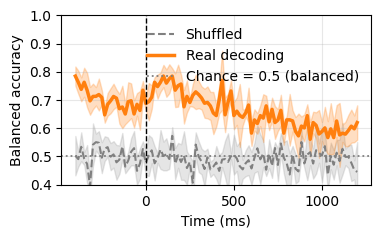

In [183]:
plot_decoding_accuracy(res, metric="balanced", color="C1")

In [167]:
import traceback
def get_session_dates_for_mouse(agg_data, mouse):
    """
    Return real imaging/session dates, excluding the training metadata entry.
    """
    dates = []
    for date, session_data in agg_data[mouse].items():
        if date == "training":
            continue
        if not isinstance(session_data, dict):
            continue
        if "table_for_video" not in session_data:
            continue
        dates.append(date)

    # Works for dates like '20250701' and '20250701_valvesilent'
    def _date_sort_key(x):
        return int(str(x)[:8]) if str(x)[:8].isdigit() else str(x)

    return sorted(dates, key=_date_sort_key)


def strip_large_fields_from_motion_res(
    res,
    keep_cv_models=False,
    keep_tensor=False,
):
    """
    Remove large fields before saving, unless you explicitly want them.

    keep_cv_models=True saves all trained CV models. This can make files huge.
    keep_tensor=True saves the full motion tensor. Also can be huge.
    """
    res = dict(res)

    if not keep_tensor:
        res.pop("motion_tensor", None)

    if not keep_cv_models and "cv_models_pack" in res:
        pack = dict(res["cv_models_pack"])
        pack["cv_models"] = None
        res["cv_models_pack"] = pack

    return res


def run_motion_decode_all_sessions_one_mouse(
    agg_data,
    mouse,
    save_dir,
    motion_key="face_motion",
    psth_time_start=-0.4,
    psth_time_end=1.2,
    align_pred="stimOn_times",
    SVD_comp_idxs=None,
    label_key="modality",
    custom_labels_by_date=None,   # optional dict: date -> labels
    trial_mask_by_date=None,      # optional dict: date -> mask
    frames_per_s=60,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=2000,
    do_shuffle=True,
    auc_n_shuffles=100,
    compute_auc=True,
    compute_accuracy=True,
    return_tensor=False,
    keep_cv_models=False,
    keep_tensor=False,
    overwrite=True,
):
    """
    Runs motion_decode_timecourse_session for every session of one mouse.

    Saves one pickle file:
        <save_dir>/<mouse>_<motion_key>_<label_key>_<align_pred>_motion_decode.pkl

    Returns
    -------
    payload : dict
        {
          'mouse': mouse,
          'params': {...},
          'results': dict date -> result,
          'errors': dict date -> error info,
        }
    out_path : Path
        Saved file path.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = save_dir / mouse / f"{motion_key}_decode_{label_key}_aligned_{align_pred}.pkl"

    if out_path.exists() and not overwrite:
        print(f"[SKIP] {mouse}: file already exists: {out_path}")
        with open(out_path, "rb") as f:
            payload = pickle.load(f)
        return payload, out_path

    dates = get_session_dates_for_mouse(agg_data, mouse)

    results = {}
    errors = {}

    params = dict(
        motion_key=motion_key,
        psth_time_start=psth_time_start,
        psth_time_end=psth_time_end,
        align_pred=align_pred,
        SVD_comp_idxs=None if SVD_comp_idxs is None else list(SVD_comp_idxs),
        label_key=label_key,
        frames_per_s=frames_per_s,
        C=C,
        l1_ratio=l1_ratio,
        n_splits=n_splits,
        random_state=random_state,
        max_iter=max_iter,
        do_shuffle=do_shuffle,
        auc_n_shuffles=auc_n_shuffles,
        compute_auc=compute_auc,
        compute_accuracy=compute_accuracy,
        return_tensor=return_tensor,
        keep_cv_models=keep_cv_models,
        keep_tensor=keep_tensor,
    )

    print(f"\n=== {mouse}: {len(dates)} sessions ===")

    for date in dates:
        try:
            session_data = agg_data[mouse][date]

            if motion_key not in session_data:
                raise KeyError(f"{motion_key} not found in agg_data[{mouse}][{date}]")

            custom_labels = None
            if custom_labels_by_date is not None:
                custom_labels = custom_labels_by_date.get(date, None)

            trial_mask = None
            if trial_mask_by_date is not None:
                trial_mask = trial_mask_by_date.get(date, None)

            print(f"Running {mouse} {date} ...")

            res = motion_decode_timecourse_session(
                agg_data,
                mouse=mouse,
                date=date,
                motion_key=motion_key,
                psth_time_start=psth_time_start,
                psth_time_end=psth_time_end,
                align_pred=align_pred,
                SVD_comp_idxs=SVD_comp_idxs,
                motion=None,
                label_key=label_key,
                custom_labels=custom_labels,
                trial_mask=trial_mask,
                frames_per_s=frames_per_s,
                C=C,
                l1_ratio=l1_ratio,
                n_splits=n_splits,
                random_state=random_state,
                max_iter=max_iter,
                do_shuffle=do_shuffle,
                return_tensor=return_tensor,
                auc_n_shuffles=auc_n_shuffles,
                compute_auc=compute_auc,
                compute_accuracy=compute_accuracy,
            )

            res = strip_large_fields_from_motion_res(
                res,
                keep_cv_models=keep_cv_models,
                keep_tensor=keep_tensor,
            )

            results[date] = res

            if compute_auc:
                peak_auc = np.nanmax(res["auc"])
                print(f"  done. peak AUC={peak_auc:.3f}")
            elif compute_accuracy:
                peak_acc = np.nanmax(res["acc_bal"])
                print(f"  done. peak bal acc={peak_acc:.3f}")
            else:
                print("  done.")

        except Exception as e:
            errors[date] = dict(
                error=repr(e),
                traceback=traceback.format_exc(),
            )
            print(f"  FAILED {mouse} {date}: {repr(e)}")

    payload = dict(
        mouse=mouse,
        params=params,
        session_dates=dates,
        results=results,
        errors=errors,
    )

    with open(out_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"\nSaved {mouse}: {out_path}")
    print(f"Successful sessions: {len(results)} / {len(dates)}")
    print(f"Failed sessions: {len(errors)}")

    return payload, out_path


def run_motion_decode_all_mice(
    agg_data,
    mouse_ids,
    save_root,
    **kwargs,
):
    """
    Runs one-mouse wrapper for all mice.
    Saves one result file per mouse.
    """
    save_root = Path(save_root)
    save_root.mkdir(parents=True, exist_ok=True)

    all_paths = {}
    all_summaries = {}

    for mouse in mouse_ids:
        payload, out_path = run_motion_decode_all_sessions_one_mouse(
            agg_data=agg_data,
            mouse=mouse,
            save_dir=save_root,
            **kwargs,
        )

        all_paths[mouse] = out_path
        all_summaries[mouse] = dict(
            n_success=len(payload["results"]),
            n_failed=len(payload["errors"]),
            failed_dates=list(payload["errors"].keys()),
        )

    summary_path = save_root / "motion_decode_batch_summary.pkl"
    with open(summary_path, "wb") as f:
        pickle.dump(
            dict(paths=all_paths, summaries=all_summaries),
            f,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    print(f"\nSaved batch summary: {summary_path}")

    return all_paths, all_summaries

In [ ]:
save_root = Path(r"I:\Cerebellum_Imaging_Dec2025")

all_paths, all_summaries = run_motion_decode_all_mice(
    agg_data,
    mouse_ids=mouse_ids,
    save_root=save_root,

    motion_key="face_motion",
    psth_time_start=-0.4,
    psth_time_end=1.2,
    align_pred="stimOn_times",
    SVD_comp_idxs=None,
    label_key="modality",

    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    do_shuffle=True,
    auc_n_shuffles=100,
    compute_auc=True,
    compute_accuracy=True,

    # Important:
    keep_cv_models=False,   # much smaller files
    keep_tensor=False,
    overwrite=True,
)

In [135]:
mouse = "AE_L3"
date = "20250612"
pop = "all"   # later try "lob_V", "lob_VI", "simplex", "crus_I"

res_context = decode_axis_one_session(
    agg_data=agg_data,
    mouse=mouse,
    date=date,
    axis_name="pre_stim_context_state",
    axis_specs=axis_specs,
    predictors=predictors,
    roi_masks_full=roi_masks_full,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    frac_thresh=0.2,
    include_all=True,
    frames_per_s=15,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    min_neurons=20,
    min_trials_per_class=10,
    require_reward_psth=False,
    dff_root=r"I:\Cerebellum_imaging_Dec2025",
    activity_mode="raw",   # start raw for sanity; then try target_retained_residual
    verbose=True,
    return_debug_tensors=True,
)

res_stim = decode_axis_one_session(
    agg_data=agg_data,
    mouse=mouse,
    date=date,
    axis_name="all_stim_side",
    axis_specs=axis_specs,
    predictors=predictors,
    roi_masks_full=roi_masks_full,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    frac_thresh=0.2,
    include_all=True,
    frames_per_s=15,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    min_neurons=20,
    min_trials_per_class=10,
    require_reward_psth=False,
    dff_root=r"I:\Cerebellum_imaging_Dec2025",
    activity_mode="raw",
    verbose=True,
    return_debug_tensors=True,
)

print("Context:", res_context[pop]["mean_auc"], res_context[pop]["mean_bal_acc"])
print("Stim side:", res_stim[pop]["mean_auc"], res_stim[pop]["mean_bal_acc"])

AE_L3 20250612 arm1 | pre_stim_context_state: neurons=637, tensor trials=248, valid decode trials=248, visual=128, auditory=120
AE_L3 20250612 arm2 | pre_stim_context_state: neurons=605, tensor trials=248, valid decode trials=248, visual=128, auditory=120
AE_L3 20250612 arm1 | all_stim_side: neurons=637, tensor trials=248, valid decode trials=248, left stimulus=110, right stimulus=138
AE_L3 20250612 arm2 | all_stim_side: neurons=605, tensor trials=248, valid decode trials=248, left stimulus=110, right stimulus=138
Context: 0.7555769230769231 0.6709102564102565
Stim side: 0.6836580086580086 0.6321067821067821


In [ ]:
axes_to_run = [
    "context_cue",
    "pre_stim_context_state",
    "visual_stim_side",
    "auditory_stim_side",
    "choice_side",
    "outcome",
]

In [ ]:

# -----------------------------
# 1. Axis list for Panel A
# -----------------------------

PANEL_A_AXES = [
    "context_cue",
    "pre_stim_context_state",
    "visual_stim_side",
    "auditory_stim_side",
    "choice_side",
    "outcome",
]

AXIS_NICE_NAMES = {
    "context_cue": "Context cue",
    "pre_stim_context_state": "Pre-stim context state",
    "visual_stim_side": "Visual stim side",
    "auditory_stim_side": "Auditory stim side",
    "all_stim_side": "All stim side",
    "choice_side": "Choice/action side",
    "outcome": "Outcome",
}

ALIGN_NICE_NAMES = {
    "ruleCue_times": "rule cue",
    "stimOn_times": "stim onset",
    "vis_stimOn_times": "visual stim",
    "aud_stimOn_times": "auditory stim",
    "all_choice_times": "choice/action",
    "feedback_times": "outcome",
}


# -----------------------------
# 2. Panel A schematic
# -----------------------------

def plot_axis_panel_A_schematic(axis_specs, axes_to_plot=PANEL_A_AXES):
    """
    Schematic of fixed event-aligned trajectory axes.
    This is not a continuous time-warped trial trajectory.
    """
    n = len(axes_to_plot)
    fig, ax = plt.subplots(figsize=(10, 0.65 * n + 1.5))

    y_positions = np.arange(n)[::-1]

    for yi, axis_name in zip(y_positions, axes_to_plot):
        spec = axis_specs[axis_name]
        align = spec["align_col"]
        train_start, train_end = spec["train_window"]

        label = AXIS_NICE_NAMES.get(axis_name, axis_name)
        align_label = ALIGN_NICE_NAMES.get(align, align)

        # local event-aligned axis from -0.4 to 1.2 s
        ax.hlines(yi, -0.4, 1.2, lw=1)
        ax.axvline(0, lw=0.8, alpha=0.25)

        # training window
        ax.plot([train_start, train_end], [yi, yi], lw=7, solid_capstyle="butt")

        ax.text(-0.62, yi, label, ha="right", va="center", fontsize=10)
        ax.text(1.28, yi, f"align: {align_label}", ha="left", va="center", fontsize=9)

    ax.set_xlim(-0.75, 1.75)
    ax.set_ylim(-0.8, n - 0.2)
    ax.set_xlabel("Time from each alignment event (s)")
    ax.set_yticks([])
    ax.set_title("Task-axis definitions using fixed event-aligned windows")
    ax.spines[["left", "right", "top"]].set_visible(False)

    # add small legend-like text
    ax.text(
        -0.72, -0.55,
        "Thick segment = decoder training window; trajectories are projected over the full peri-event window.",
        ha="left", va="center", fontsize=8
    )

    plt.tight_layout()
    return fig, ax


# Example:
# fig, ax = plot_axis_panel_A_schematic(axis_specs)


# -----------------------------
# 3. Trial condition masks
# -----------------------------

def _finite_col_local(table, col):
    if col not in table.columns:
        return np.zeros(len(table), dtype=bool)
    return np.isfinite(table[col].to_numpy())


def get_four_trial_type_masks(table_full, debug):
    """
    Returns masks in tensor/projection trial coordinates.

    Works because debug["base_trial_mask"] compresses original trials
    to the valid alignment trials used by build_residual_tensor.
    """
    base_mask = np.asarray(debug["base_trial_mask"], dtype=bool)
    table = table_full.loc[base_mask].reset_index(drop=True)

    masks = {
        "vis_left": _finite_col_local(table, "left_vis_stimOn_times"),
        "vis_right": _finite_col_local(table, "right_vis_stimOn_times"),
        "aud_left": _finite_col_local(table, "left_aud_stimOn_times"),
        "aud_right": _finite_col_local(table, "right_aud_stimOn_times"),
    }

    trial_mask = np.asarray(debug["trial_mask"], dtype=bool)
    for k in masks:
        masks[k] = masks[k] & trial_mask

    return masks


def get_outcome_masks(table_full, debug):
    """
    Outcome masks in tensor/projection trial coordinates.
    Used for outcome-axis plots, where reward vs punish is more interpretable
    than visual-left/right conditions.
    """
    base_mask = np.asarray(debug["base_trial_mask"], dtype=bool)
    table = table_full.loc[base_mask].reset_index(drop=True)

    reward = (
        _finite_col_local(table, "vis_reward_times") |
        _finite_col_local(table, "aud_reward_times")
    )
    punish = (
        _finite_col_local(table, "vis_punish_times") |
        _finite_col_local(table, "aud_punish_times")
    )

    # fallback if explicit reward/punish columns are not present
    if not np.any(reward) and "feedbackType" in table.columns:
        reward = table["feedbackType"].to_numpy() == 1
    if not np.any(punish) and "feedbackType" in table.columns:
        punish = table["feedbackType"].to_numpy() == -1

    trial_mask = np.asarray(debug["trial_mask"], dtype=bool)

    return {
        "reward": reward & trial_mask,
        "punish": punish & trial_mask,
    }


# -----------------------------
# 4. Plot one projection on an existing axis
# -----------------------------

def plot_axis_projection_conditions_on_ax(
    result,
    debug,
    table_full,
    ax=None,
    mask_mode="auto",
    min_trials=3,
    show_sem=True,
    title=None,
):
    """
    Plot projection time course for one decoded axis/session/population.

    mask_mode:
        "four_trial_types" : visual-left, visual-right, auditory-left, auditory-right
        "outcome"          : reward, punish
        "auto"             : outcome masks for outcome axis; otherwise four trial types
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    proj = np.asarray(result["projection"], dtype=float)
    t = np.asarray(result["timepoints"])

    axis_name = debug.get("axis_name", "")

    if mask_mode == "auto":
        mask_mode = "outcome" if axis_name == "outcome" else "four_trial_types"

    if mask_mode == "outcome":
        masks = get_outcome_masks(table_full, debug)
        cond_order = ["reward", "punish"]
        cond_labels = {
            "reward": "Reward",
            "punish": "Punish / no reward",
        }
    else:
        masks = get_four_trial_type_masks(table_full, debug)
        cond_order = ["vis_left", "vis_right", "aud_left", "aud_right"]
        cond_labels = {
            "vis_left": "Visual left",
            "vis_right": "Visual right",
            "aud_left": "Auditory left",
            "aud_right": "Auditory right",
        }

    for cond in cond_order:
        m = np.asarray(masks[cond], dtype=bool)

        # safety check
        if len(m) != proj.shape[0]:
            raise ValueError(
                f"Mask length mismatch for {cond}: "
                f"len(mask)={len(m)}, projection trials={proj.shape[0]}"
            )

        n = int(np.sum(m))
        if n < min_trials:
            continue

        y_trials = proj[m, :]
        y = np.nanmean(y_trials, axis=0)

        ax.plot(t, y, label=f"{cond_labels[cond]} (n={n})")

        if show_sem and n > 1:
            sem = np.nanstd(y_trials, axis=0, ddof=1) / np.sqrt(n)
            ax.fill_between(t, y - sem, y + sem, alpha=0.2)

    ax.axvline(0, color="k", lw=1)
    ax.axhline(0, color="k", lw=0.75, alpha=0.25)

    align_label = ALIGN_NICE_NAMES.get(debug.get("align_col", ""), debug.get("align_col", "event"))
    ax.set_xlabel(f"Time from {align_label} (s)")
    ax.set_ylabel("Projection")

    if title is None:
        title = (
            f"{debug['mouse']} {debug['date']} | "
            f"{debug['population']} | {AXIS_NICE_NAMES.get(axis_name, axis_name)}"
        )
    ax.set_title(title, fontsize=9)

    return fig, ax


# -----------------------------
# 5. Date/table helpers
# -----------------------------

def _date_sort_key(date):
    """
    Sort dates like '20250617', '20250617_valvesilent',
    '20250617_valvesilent_punishsilent'.
    """
    s = str(date)
    m = re.match(r"(\d+)", s)
    if m is None:
        return (10**20, s)
    return (int(m.group(1)), s)


def get_mouse_imaging_dates(agg_data, mouse):
    dates = [d for d in agg_data[mouse].keys() if d != "training"]
    return sorted(dates, key=_date_sort_key)


def get_reference_table_for_session(agg_data, mouse, date):
    """
    Use arm1 table if available, otherwise arm2.
    Must match the original trial coordinates used inside decode_axis_one_session.
    """
    session = agg_data[mouse][date]

    if "arm1" in session:
        table = session["arm1"]["table_for_img"]
    elif "arm2" in session:
        table = session["arm2"]["table_for_img"]
    else:
        raise ValueError(f"No arm1/arm2 table found for {mouse} {date}")

    # decode_axis_one_session calls add_common_event_columns internally,
    # so do the same here.
    return add_common_event_columns(table.copy())

def _scalarize_metric(x, default=np.nan):
    """
    Convert scalar / 1-element array / fold-wise array into one float for printing
    and summary tables.
    """
    if x is None:
        return default

    arr = np.asarray(x)

    if arr.size == 0:
        return default

    try:
        return float(np.nanmean(arr.astype(float)))
    except Exception:
        return default


def _format_metric(x, fmt=".3f"):
    val = _scalarize_metric(x)
    if np.isnan(val):
        return "nan"
    return format(val, fmt)
# -----------------------------
# 6. Run all axes for one mouse
# -----------------------------

def run_axis_set_one_mouse(
    agg_data,
    mouse,
    axis_specs,
    predictors,
    axes_to_run=PANEL_A_AXES,
    population="all",
    roi_masks_full=None,
    roi_order=("lob_V", "lob_VI", "simplex", "crus_I"),
    frac_thresh=0.2,
    activity_mode="target_retained_residual",
    dff_root=None,
    min_neurons=20,
    min_trials_per_class=10,
    verbose=True,
    **decode_kwargs,
):
    """
    Runs decode_axis_one_session across all sessions of one mouse.

    Returns
    -------
    axis_results : dict
        axis_results[date][axis_name] = {
            "result": result for selected population,
            "debug": debug tensor dict for selected population,
            "table_full": table in original trial coordinates,
        }

    summary_df : pd.DataFrame
        One row per successful date/axis.
    """
    dates = get_mouse_imaging_dates(agg_data, mouse)
    axis_results = {}
    summary_rows = []

    for date in dates:
        axis_results[date] = {}

        for axis_name in axes_to_run:
            try:
                out = decode_axis_one_session(
                    agg_data=agg_data,
                    mouse=mouse,
                    date=date,
                    axis_name=axis_name,
                    axis_specs=axis_specs,
                    predictors=predictors,
                    roi_masks_full=roi_masks_full,
                    roi_order=roi_order,
                    frac_thresh=frac_thresh,
                    activity_mode=activity_mode,
                    dff_root=dff_root,
                    min_neurons=min_neurons,
                    min_trials_per_class=min_trials_per_class,
                    return_debug_tensors=True,
                    verbose=False,
                    **decode_kwargs,
                )

                if population not in out:
                    if verbose:
                        print(f"[skip] {mouse} {date} {axis_name}: no result for population={population}")
                    continue

                if "_debug_tensors" not in out or population not in out["_debug_tensors"]:
                    if verbose:
                        print(f"[skip] {mouse} {date} {axis_name}: no debug tensor for population={population}")
                    continue

                result = out[population]
                debug = out["_debug_tensors"][population]
                table_full = get_reference_table_for_session(agg_data, mouse, date)

                axis_results[date][axis_name] = {
                    "result": result,
                    "debug": debug,
                    "table_full": table_full,
                }

                auc = _scalarize_metric(result.get("auc", np.nan))
                ba = _scalarize_metric(result.get("balanced_accuracy", np.nan))
                nn = _scalarize_metric(result.get("n_neurons", np.nan))
                nt = _scalarize_metric(result.get("n_trials", np.nan))

                axis_results[date][axis_name] = {
                    "result": result,
                    "debug": debug,
                    "table_full": table_full,
                }

                summary_rows.append({
                    "mouse": mouse,
                    "date": date,
                    "axis_name": axis_name,
                    "population": population,
                    "n_neurons": nn,
                    "n_trials": nt,
                    "auc": auc,
                    "balanced_accuracy": ba,
                    "activity_mode": activity_mode,
                })

                if verbose:
                    print(
                        f"[ok] {mouse} {date} {axis_name} | "
                        f"{population}: neurons={nn:.0f}, trials={nt:.0f}, "
                        f"AUC={auc:.3f}, bal_acc={ba:.3f}"
                    )

            except Exception as e:
                if verbose:
                    print(f"[error] {mouse} {date} {axis_name}: {e}")
                continue

    summary_df = pd.DataFrame(summary_rows)
    return axis_results, summary_df


# -----------------------------
# 7. Plot one axis across all sessions
# -----------------------------

def plot_mouse_axis_projection_grid(
    axis_results,
    mouse,
    axis_name,
    ncols=4,
    population="all",
    mask_mode="auto",
    min_trials=3,
    show_sem=True,
    figsize_per_panel=(4.0, 3.0),
):
    """
    Grid plot: one axis, all sessions of one mouse.
    """
    dates = [
        d for d in sorted(axis_results.keys(), key=_date_sort_key)
        if axis_name in axis_results[d]
    ]

    if len(dates) == 0:
        raise ValueError(f"No results found for axis {axis_name}")

    nrows = int(math.ceil(len(dates) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
        sharex=False,
        sharey=False,
    )

    for i, date in enumerate(dates):
        ax = axes[i // ncols, i % ncols]

        pack = axis_results[date][axis_name]
        result = pack["result"]
        debug = pack["debug"]
        table_full = pack["table_full"]

        auc = _scalarize_metric(result.get("auc", np.nan))
        ba = _scalarize_metric(result.get("balanced_accuracy", np.nan))

        title = f"{date}\nAUC={auc:.2f}, bal={ba:.2f}"

        plot_axis_projection_conditions_on_ax(
            result=result,
            debug=debug,
            table_full=table_full,
            ax=ax,
            mask_mode=mask_mode,
            min_trials=min_trials,
            show_sem=show_sem,
            title=title,
        )

        if i % ncols != 0:
            ax.set_ylabel("")

        if i < len(dates) - ncols:
            ax.set_xlabel("")

    # turn off unused axes
    for j in range(len(dates), nrows * ncols):
        axes[j // ncols, j % ncols].set_axis_off()

    # one shared legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if len(handles) > 0:
        fig.legend(handles, labels, frameon=False, loc="upper right", fontsize=8)

    fig.suptitle(
        f"{mouse} | {population} | {AXIS_NICE_NAMES.get(axis_name, axis_name)}",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    return fig, axes


# -----------------------------
# 8. Convenience: plot all Panel A axes
# -----------------------------

def plot_all_panel_A_axes_one_mouse(
    axis_results,
    mouse,
    axes_to_plot=PANEL_A_AXES,
    population="all",
    ncols=4,
    show_sem=True,
):
    figs = {}

    for axis_name in axes_to_plot:
        available = any(axis_name in axis_results[d] for d in axis_results)
        if not available:
            print(f"[skip plot] no results for {axis_name}")
            continue

        fig, axes = plot_mouse_axis_projection_grid(
            axis_results=axis_results,
            mouse=mouse,
            axis_name=axis_name,
            ncols=ncols,
            population=population,
            mask_mode="auto",
            show_sem=show_sem,
        )
        figs[axis_name] = fig

    return figs

In [ ]:

dff_root = r'I:\Cerebellum_imaging_Dec2025'
# Panel A schematic
# fig_A, ax_A = plot_axis_panel_A_schematic(axis_specs)

# Run all event-aligned axes for all sessions of this mouse
for mouse in agg_data.keys():
    axis_results, summary = run_axis_set_one_mouse(
        agg_data=agg_data,
        mouse=mouse,
        axis_specs=axis_specs,
        predictors=predictors,
        axes_to_run=PANEL_A_AXES,
        population="all",
        roi_masks_full=roi_masks_full,      # or None for all only
        dff_root=dff_root,                  # use whatever you used before
        activity_mode="target_retained_residual",
        min_neurons=20,
        min_trials_per_class=10,
        verbose=True,
    )

    # display(summary_AE_L3)
    save_dir = Path(r"I:\Cerebellum_Imaging_Dec2025") / mouse / "trajectory_axis_results"
    save_dir.mkdir(parents=True, exist_ok=True)

    save_path = save_dir / "axis_results.pkl"

    with open(save_path, "wb") as f:
        pickle.dump(axis_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    summary_path = save_dir / "axes_summary.csv"
    summary.to_csv(summary_path, index=False)

    print(f"Saved summary to: {summary_path}")
# Plot one axis at a time across all sessions
# fig_context, _ = plot_mouse_axis_projection_grid(
#     axis_results_AE_L3,
#     mouse=mouse,
#     axis_name="context_cue",
#     ncols=4,
# )

# fig_vis_stim, _ = plot_mouse_axis_projection_grid(
#     axis_results_AE_L3,
#     mouse=mouse,
#     axis_name="visual_stim_side",
#     ncols=4,
# )

# fig_aud_stim, _ = plot_mouse_axis_projection_grid(
#     axis_results_AE_L3,
#     mouse=mouse,
#     axis_name="auditory_stim_side",
#     ncols=4,
# )

# fig_choice, _ = plot_mouse_axis_projection_grid(
#     axis_results_AE_L3,
#     mouse=mouse,
#     axis_name="choice_side",
#     ncols=4,
# )

# # Or plot all Panel A axes in one call
# figs = plot_all_panel_A_axes_one_mouse(
#     axis_results_AE_L3,
#     mouse=mouse,
#     axes_to_plot=PANEL_A_AXES,
#     ncols=4,
# )

Choice axis convergence

In [282]:
def _scalarize(x, default=np.nan):
    if x is None:
        return default
    arr = np.asarray(x)
    if arr.size == 0:
        return default
    try:
        return float(np.nanmean(arr.astype(float)))
    except Exception:
        return default


def _date_sort_key(date):
    s = str(date)
    m = re.search(r"(\d{8})", s)
    if m is not None:
        return int(m.group(1))
    return s


def _finite_event_col(table, col):
    if col not in table.columns:
        return np.zeros(len(table), dtype=bool)
    return pd.to_numeric(table[col], errors="coerce").notna().to_numpy()


def load_mouse_axis_results(save_root, mouse, filename="axis_results.pkl"):
    path = Path(save_root) / mouse / "trajectory_axis_results" / filename
    with open(path, "rb") as f:
        axis_results = pickle.load(f)
    return axis_results, path

In [283]:
def get_modality_side_masks_from_axis_pack(
    pack,
    side_source="choice",      # "choice" or "stimulus"
    correct_only=True,
):
    """
    Returns masks in projection trial coordinates.

    side_source="choice":
        left/right defined by actual animal choice.
        choice == -1 -> left
        choice ==  1 -> right

    side_source="stimulus":
        left/right defined by stimulus side event columns.

    correct_only=True:
        restrict to rewarded/correct trials using feedbackType == 1.
        Recommended for the main convergence analysis.
    """
    result = pack["result"]
    debug = pack["debug"]
    table_full = pack["table_full"]

    proj = np.asarray(result["projection"], dtype=float)
    n_trials = proj.shape[0]

    base_mask = np.asarray(debug["base_trial_mask"], dtype=bool)
    table = table_full.loc[base_mask].reset_index(drop=True)

    if len(table) != n_trials:
        raise ValueError(
            f"Trial mismatch: compressed table has {len(table)} trials, "
            f"projection has {n_trials} trials."
        )

    # Valid projection trials: held-out projections are finite somewhere.
    valid_proj = np.isfinite(proj).any(axis=1)

    # Decoder-valid trial mask, if stored.
    if "valid_mask" in result:
        valid_decode = np.asarray(result["valid_mask"], dtype=bool)
    else:
        valid_decode = np.ones(n_trials, dtype=bool)

    # Debug trial mask, if stored.
    if "trial_mask" in debug:
        valid_debug = np.asarray(debug["trial_mask"], dtype=bool)
    else:
        valid_debug = np.ones(n_trials, dtype=bool)

    valid = valid_proj & valid_decode & valid_debug

    # Modality: your get_axis_labels assumes modality 0 = visual, 1 = auditory.
    if "modality" in table.columns:
        modality = pd.to_numeric(table["modality"], errors="coerce").to_numpy()
        is_vis = modality == 0
        is_aud = modality == 1
    else:
        # Fallback from event columns.
        is_vis = (
            _finite_event_col(table, "left_vis_stimOn_times") |
            _finite_event_col(table, "right_vis_stimOn_times")
        )
        is_aud = (
            _finite_event_col(table, "left_aud_stimOn_times") |
            _finite_event_col(table, "right_aud_stimOn_times")
        )

    # Correct trials only.
    if correct_only and "feedbackType" in table.columns:
        feedback = pd.to_numeric(table["feedbackType"], errors="coerce").to_numpy()
        is_correct = feedback == 1
    else:
        is_correct = np.ones(n_trials, dtype=bool)

    if side_source == "choice":
        if "choice" not in table.columns:
            raise KeyError("side_source='choice' requires a 'choice' column.")

        choice = pd.to_numeric(table["choice"], errors="coerce").to_numpy()

        # From your get_axis_labels:
        # choice == -1 is left choice; choice == +1 is right choice.
        is_left = choice == -1
        is_right = choice == 1

    elif side_source == "stimulus":
        is_left = (
            _finite_event_col(table, "left_vis_stimOn_times") |
            _finite_event_col(table, "left_aud_stimOn_times")
        )
        is_right = (
            _finite_event_col(table, "right_vis_stimOn_times") |
            _finite_event_col(table, "right_aud_stimOn_times")
        )
    else:
        raise ValueError("side_source must be 'choice' or 'stimulus'.")

    masks = {
        "vis_left":  is_vis & is_left  & is_correct & valid,
        "vis_right": is_vis & is_right & is_correct & valid,
        "aud_left":  is_aud & is_left  & is_correct & valid,
        "aud_right": is_aud & is_right & is_correct & valid,
    }

    return masks

In [296]:
def compute_crossmodal_choice_convergence_one_session(
    axis_results,
    date,
    axis_name="choice_side",
    side_source="choice",
    correct_only=True,
    min_trials=5,
    scalar_window=None,
    eps=1e-9,
):
    """
    Computes cross-modal convergence on one saved decoder axis.

    Main metric:
        D_same = distance(vis_left, aud_left) + distance(vis_right, aud_right)
        D_opp  = distance(vis_left, aud_right) + distance(vis_right, aud_left)

        CI = (D_opp - D_same) / (D_opp + D_same)

    Positive CI means visual/auditory trajectories are closer when they share
    the same choice/action side.
    """
    if date not in axis_results:
        raise KeyError(f"{date} not in axis_results.")

    if axis_name not in axis_results[date]:
        raise KeyError(f"{axis_name} not found for date {date}.")

    pack = axis_results[date][axis_name]
    result = pack["result"]

    proj = np.asarray(result["projection"], dtype=float)   # trials x time
    t = np.asarray(result["timepoints"], dtype=float)

    masks = get_modality_side_masks_from_axis_pack(
        pack,
        side_source=side_source,
        correct_only=correct_only,
    )

    cond_order = ["vis_left", "vis_right", "aud_left", "aud_right"]

    means = {}
    sems = {}
    counts = {}

    for cond in cond_order:
        m = np.asarray(masks[cond], dtype=bool)
        counts[cond] = int(np.sum(m))

        if counts[cond] < min_trials:
            means[cond] = np.full(len(t), np.nan)
            sems[cond] = np.full(len(t), np.nan)
            continue

        y = proj[m, :]
        means[cond] = np.nanmean(y, axis=0)

        if counts[cond] > 1:
            sems[cond] = np.nanstd(y, axis=0, ddof=1) / np.sqrt(counts[cond])
        else:
            sems[cond] = np.full(len(t), np.nan)

    enough_trials = all(counts[c] >= min_trials for c in cond_order)

    if enough_trials:
        d_same = 0.5 * (
            np.abs(means["vis_left"] - means["aud_left"]) +
            np.abs(means["vis_right"] - means["aud_right"])
        )

        d_opp = 0.5 * (
            np.abs(means["vis_left"] - means["aud_right"]) +
            np.abs(means["vis_right"] - means["aud_left"])
        )

        convergence_index = (d_opp - d_same) / (d_opp + d_same + eps)
    else:
        d_same = np.full(len(t), np.nan)
        d_opp = np.full(len(t), np.nan)
        convergence_index = np.full(len(t), np.nan)

    df_time = pd.DataFrame({
        "time": t,
        "d_same": d_same,
        "d_opp": d_opp,
        "ci": convergence_index,
    })

    if scalar_window is None:
        scalar_window = result.get("train_window", (0.0, 0.2))

    wm = (
        (df_time["time"].to_numpy() >= scalar_window[0]) &
        (df_time["time"].to_numpy() <= scalar_window[1])
    )

    summary = {
        "date": date,
        "axis_name": axis_name,
        "side_source": side_source,
        "correct_only": correct_only,
        "scalar_window_start": scalar_window[0],
        "scalar_window_end": scalar_window[1],
        "ci_mean": float(np.nanmean(convergence_index[wm])) if np.any(wm) else np.nan,
        "d_same_mean": float(np.nanmean(d_same[wm])) if np.any(wm) else np.nan,
        "d_opp_mean": float(np.nanmean(d_opp[wm])) if np.any(wm) else np.nan,
        "mean_auc": _scalarize(result.get("mean_auc", result.get("auc", np.nan))),
        "mean_bal_acc": _scalarize(result.get("mean_bal_acc", result.get("acc_bal", np.nan))),
        "n_neurons": _scalarize(result.get("n_neurons", np.nan)),
        "n_trials_decoder": _scalarize(result.get("n_trials", np.nan)),
        "n_vis_left": counts["vis_left"],
        "n_vis_right": counts["vis_right"],
        "n_aud_left": counts["aud_left"],
        "n_aud_right": counts["aud_right"],
        "enough_trials": enough_trials,
    }

    return {
        "df_time": df_time,
        "summary": summary,
        "means": means,
        "sems": sems,
        "counts": counts,
        "pack": pack,
    }

In [285]:
def plot_crossmodal_choice_convergence_session(
    conv,
    title=None,
    show_sem=True,
):
    df = conv["df_time"]
    t = df["time"].to_numpy()

    means = conv["means"]
    sems = conv["sems"]
    counts = conv["counts"]

    label_map = {
        "vis_left": "Visual left choice",
        "vis_right": "Visual right choice",
        "aud_left": "Auditory left choice",
        "aud_right": "Auditory right choice",
    }

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))

    # Left: projection trajectories
    ax = axes[0]
    for cond in ["vis_left", "vis_right", "aud_left", "aud_right"]:
        y = means[cond]
        ax.plot(t, y, label=f"{label_map[cond]} (n={counts[cond]})")

        if show_sem:
            se = sems[cond]
            ax.fill_between(t, y - se, y + se, alpha=0.2)

    ax.axvline(0, lw=1, color="k")
    ax.axhline(0, lw=0.75, color="k", alpha=0.25)
    ax.set_xlabel("Time from choice/action alignment (s)")
    ax.set_ylabel("Held-out projection onto choice axis")
    ax.set_title("Condition trajectories")
    ax.legend(frameon=False, fontsize=7)

    # Right: convergence metric
    ax = axes[1]
    ax.plot(t, df["d_same"], label="same-choice V-A distance")
    ax.plot(t, df["d_opp"], label="opposite-choice V-A distance")
    ax.axvline(0, lw=1, color="k")
    ax.set_xlabel("Time from choice/action alignment (s)")
    ax.set_ylabel("Projection distance")
    ax.legend(frameon=False, fontsize=7, loc="upper left")

    ax2 = ax.twinx()
    ax2.plot(t, df["ci"], linestyle="--", label="convergence index")
    ax2.axhline(0, lw=0.75, color="k", alpha=0.25)
    ax2.set_ylabel("Convergence index")

    if title is None:
        s = conv["summary"]
        title = (
            f"{s['date']} | CI={s['ci_mean']:.3f}, "
            f"AUC={s['mean_auc']:.3f}"
        )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig, axes

In [305]:
save_root = Path(r"I:\Cerebellum_Imaging_Dec2025")

mouse = "AF_L3"
axis_results, axis_path = load_mouse_axis_results(save_root, mouse)

print(f"Loaded: {axis_path}")
print(sorted(axis_results.keys(), key=_date_sort_key))

Loaded: I:\Cerebellum_Imaging_Dec2025\AF_L3\trajectory_axis_results\axis_results.pkl
['20250604', '20250618_valvesilent', '20250625_valvesilent', '20250702_valvesilent', '20250710_valvesilent', '20250716_valvesilent', '20250723_valvesilent', '20250730_valvesilent', '20250814_valvesilent', '20250821_valvesilent', '20250828_valvesilent', '20250904_valvesilent_punishsilent', '20250909_valvesilent_punishsilent']


,date,axis_name,side_source,correct_only,scalar_window_start,scalar_window_end,ci_mean,d_same_mean,d_opp_mean,mean_auc,mean_bal_acc,n_neurons,n_trials_decoder,n_vis_left,n_vis_right,n_aud_left,n_aud_right,enough_trials
0,20250604,choice_side,choice,True,0.0,0.2,0.788608,0.384969,3.221152,0.816532,0.731624,1017.0,117.0,16,13,12,18,True


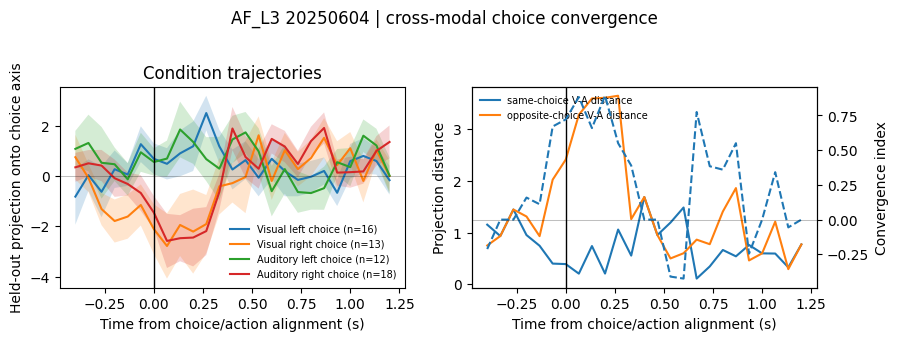

In [309]:
date = "20250604"  # change this

conv = compute_crossmodal_choice_convergence_one_session(
    axis_results=axis_results,
    date=date,
    axis_name="choice_side",
    side_source="choice",       # recommended for choice/action convergence
    correct_only=True,          # recommended for main figure
    min_trials=5,
    scalar_window=(0.0, 0.2),   # your choice-side decoder train window
)

display(pd.DataFrame([conv["summary"]]))

fig, axes = plot_crossmodal_choice_convergence_session(
    conv,
    title=f"{mouse} {date} | cross-modal choice convergence",
)

In [290]:
def collect_crossmodal_choice_convergence_one_mouse(
    axis_results,
    mouse,
    axis_name="choice_side",
    side_source="choice",
    correct_only=True,
    min_trials=5,
    scalar_window=(0.0, 0.2),
):
    rows = []
    curves = []

    for date in sorted(axis_results.keys(), key=_date_sort_key):
        if axis_name not in axis_results[date]:
            continue

        try:
            conv = compute_crossmodal_choice_convergence_one_session(
                axis_results=axis_results,
                date=date,
                axis_name=axis_name,
                side_source=side_source,
                correct_only=correct_only,
                min_trials=min_trials,
                scalar_window=scalar_window,
            )

            row = conv["summary"].copy()
            row["mouse"] = mouse
            rows.append(row)

            df_t = conv["df_time"].copy()
            df_t["mouse"] = mouse
            df_t["date"] = date
            df_t["axis_name"] = axis_name
            df_t["side_source"] = side_source
            df_t["correct_only"] = correct_only
            curves.append(df_t)

        except Exception as e:
            print(f"[skip] {mouse} {date}: {e}")

    df_summary = pd.DataFrame(rows)
    df_curves = pd.concat(curves, ignore_index=True) if len(curves) else pd.DataFrame()

    return df_summary, df_curves

In [310]:
df_ci_mouse, df_ci_curve_mouse = collect_crossmodal_choice_convergence_one_mouse(
    axis_results=axis_results,
    mouse=mouse,
    axis_name="choice_side",
    side_source="choice",
    correct_only=False,
    min_trials=5,
    scalar_window=(0.0, 0.2),
)

display(df_ci_mouse.head())

,date,axis_name,side_source,correct_only,scalar_window_start,scalar_window_end,ci_mean,d_same_mean,d_opp_mean,mean_auc,mean_bal_acc,n_neurons,n_trials_decoder,n_vis_left,n_vis_right,n_aud_left,n_aud_right,enough_trials,mouse
0,20250604,choice_side,choice,False,0.0,0.2,0.765888,0.386075,3.203704,0.816532,0.731624,1017.0,117.0,42,21,26,28,True,AF_L3
1,20250618_valvesilent,choice_side,choice,False,0.0,0.2,0.567994,0.538732,2.015913,0.752443,0.709647,1002.0,201.0,31,66,29,75,True,AF_L3
2,20250625_valvesilent,choice_side,choice,False,0.0,0.2,0.513626,0.600393,1.878502,0.728755,0.608826,731.0,262.0,24,106,47,85,True,AF_L3
3,20250702_valvesilent,choice_side,choice,False,0.0,0.2,0.105429,0.817834,1.114077,0.568591,0.550833,579.0,221.0,15,92,28,86,True,AF_L3
4,20250710_valvesilent,choice_side,choice,False,0.0,0.2,0.006155,0.732808,0.775262,0.449727,0.459973,773.0,277.0,40,94,24,119,True,AF_L3


C:\Users\dirk\AppData\Local\Temp\ipykernel_13924\2820173989.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


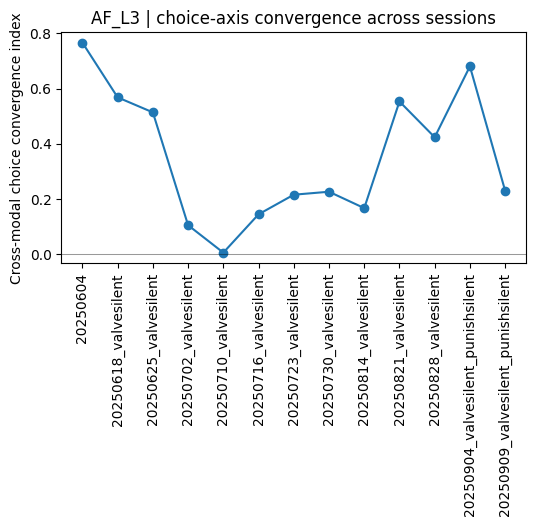

In [311]:
fig, ax = plt.subplots(figsize=(6, 3))

x = np.arange(len(df_ci_mouse))
ax.plot(x, df_ci_mouse["ci_mean"], marker="o")
ax.axhline(0, color="k", lw=0.75, alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(df_ci_mouse["date"], rotation=90)
ax.set_ylabel("Cross-modal choice convergence index")
ax.set_title(f"{mouse} | choice-axis convergence across sessions")

plt.tight_layout()

In [312]:
all_rows = []
all_curves = []

save_root = Path(r"I:\Cerebellum_Imaging_Dec2025")

for mouse in mouse_ids:
    try:
        axis_results, axis_path = load_mouse_axis_results(save_root, mouse)

        df_s, df_t = collect_crossmodal_choice_convergence_one_mouse(
            axis_results=axis_results,
            mouse=mouse,
            axis_name="choice_side",
            side_source="choice",
            correct_only=False,
            min_trials=5,
            scalar_window=(0.0, 0.2),
        )

        all_rows.append(df_s)
        all_curves.append(df_t)

        print(f"[ok] {mouse}: {len(df_s)} sessions")

    except Exception as e:
        print(f"[error] {mouse}: {e}")

df_ci_all = pd.concat(all_rows, ignore_index=True)
df_ci_curve_all = pd.concat(all_curves, ignore_index=True)

display(df_ci_all.head())

[ok] AE_L2: 7 sessions
[ok] AE_L3: 12 sessions
[ok] AF_R3: 15 sessions
[ok] AF_L2: 10 sessions
[ok] AF_L3: 13 sessions
[ok] AB_R2: 11 sessions


C:\Users\dirk\AppData\Local\Temp\ipykernel_13924\2082242226.py:105: RuntimeWarning: Mean of empty slice
  "ci_mean": float(np.nanmean(convergence_index[wm])) if np.any(wm) else np.nan,
C:\Users\dirk\AppData\Local\Temp\ipykernel_13924\2082242226.py:106: RuntimeWarning: Mean of empty slice
  "d_same_mean": float(np.nanmean(d_same[wm])) if np.any(wm) else np.nan,
C:\Users\dirk\AppData\Local\Temp\ipykernel_13924\2082242226.py:107: RuntimeWarning: Mean of empty slice
  "d_opp_mean": float(np.nanmean(d_opp[wm])) if np.any(wm) else np.nan,


[ok] J_L2: 9 sessions
[ok] A_R2: 8 sessions
[ok] A_R3: 7 sessions
[ok] O_R2: 9 sessions
[ok] R_L2: 7 sessions


,date,axis_name,side_source,correct_only,scalar_window_start,scalar_window_end,ci_mean,d_same_mean,d_opp_mean,mean_auc,mean_bal_acc,n_neurons,n_trials_decoder,n_vis_left,n_vis_right,n_aud_left,n_aud_right,enough_trials,mouse
0,20250624_valvesilent,choice_side,choice,False,0.0,0.2,0.709416,0.526544,2.930247,0.776087,0.719746,1101.0,239.0,60,62,60,57,True,AE_L2
1,20250701_valvesilent,choice_side,choice,False,0.0,0.2,0.771131,0.272038,2.535349,0.752374,0.666813,1093.0,269.0,83,56,61,69,True,AE_L2
2,20250708_valvesilent,choice_side,choice,False,0.0,0.2,0.304549,0.614571,1.161571,0.632017,0.602222,939.0,221.0,26,81,18,96,True,AE_L2
3,20250715_valvesilent,choice_side,choice,False,0.0,0.2,0.562769,0.485670,1.455855,0.664957,0.618254,846.0,308.0,58,97,90,63,True,AE_L2
4,20250729_valvesilent,choice_side,choice,False,0.0,0.2,0.150508,1.260096,1.997926,0.678658,0.635889,849.0,303.0,114,42,77,70,True,AE_L2


In [313]:
df_ci_all = add_training_performance_to_decode_df(
    df_ci_all,
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    nearest_if_no_exact=True,
)


def assign_learning_stage_from_perf(row, thresh=0.65):
    v = row.get("perf_vis", np.nan)
    a = row.get("perf_aud", np.nan)

    if not np.isfinite(v) or not np.isfinite(a):
        return "unknown"

    if v < thresh and a < thresh:
        return "naive"
    elif v >= thresh and a < thresh:
        return "visual_expert"
    elif v < thresh and a >= thresh:
        return "auditory_expert"
    else:
        return "double_expert"


df_ci_all["stage"] = df_ci_all.apply(assign_learning_stage_from_perf, axis=1)

display(df_ci_all.head())

,date,axis_name,side_source,correct_only,scalar_window_start,scalar_window_end,ci_mean,d_same_mean,d_opp_mean,mean_auc,...,n_aud_left,n_aud_right,enough_trials,mouse,date_norm,training_i,perf_vis,perf_aud,perf_mean,stage
0,20250624_valvesilent,choice_side,choice,False,0.0,0.2,0.709416,0.526544,2.930247,0.776087,...,60,57,True,AE_L2,20250624,10.0,0.505882,0.425532,0.465707,naive
1,20250701_valvesilent,choice_side,choice,False,0.0,0.2,0.771131,0.272038,2.535349,0.752374,...,61,69,True,AE_L2,20250701,15.0,0.533333,0.483871,0.508602,naive
2,20250708_valvesilent,choice_side,choice,False,0.0,0.2,0.304549,0.614571,1.161571,0.632017,...,18,96,True,AE_L2,20250708,20.0,0.446154,0.367188,0.406671,naive
3,20250715_valvesilent,choice_side,choice,False,0.0,0.2,0.562769,0.485670,1.455855,0.664957,...,90,63,True,AE_L2,20250715,25.0,0.458101,0.461538,0.459820,naive
4,20250729_valvesilent,choice_side,choice,False,0.0,0.2,0.150508,1.260096,1.997926,0.678658,...,77,70,True,AE_L2,20250729,36.0,0.578313,0.612500,0.595407,naive


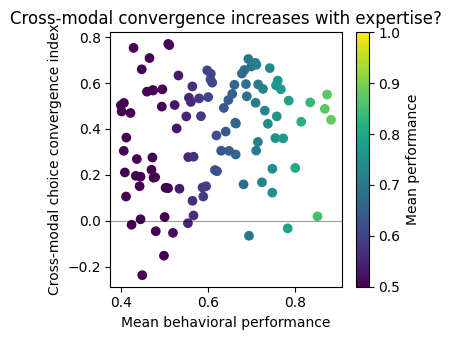

In [314]:
fig, ax = plt.subplots(figsize=(4, 3.5))

m = (
    np.isfinite(df_ci_all["perf_mean"]) &
    np.isfinite(df_ci_all["ci_mean"]) &
    df_ci_all["enough_trials"].astype(bool)
)

sc = ax.scatter(
    df_ci_all.loc[m, "perf_mean"],
    df_ci_all.loc[m, "ci_mean"],
    c=df_ci_all.loc[m, "perf_mean"],
    vmin=0.5,
    vmax=1.0,
)

ax.axhline(0, color="k", lw=0.75, alpha=0.4)
ax.set_xlabel("Mean behavioral performance")
ax.set_ylabel("Cross-modal choice convergence index")
ax.set_title("Cross-modal convergence increases with expertise?")

cb = fig.colorbar(sc, ax=ax)
cb.set_label("Mean performance")

plt.tight_layout()

In [153]:
def _get_n_neurons_from_result(result):
    for k in ["n_neurons", "num_neurons"]:
        if k in result:
            arr = np.asarray(result[k])
            if arr.size > 0:
                return int(np.nanmean(arr.astype(float)))
    return None


def _coerce_weight_vector(x, n_neurons=None):
    """
    Convert stored decoder axis / coefficients into a 1D vector.

    Handles:
      - vector: n_neurons
      - fold x neurons: average across folds
      - neurons x fold: average across folds
      - 1 x neurons / neurons x 1
    """
    arr = np.asarray(x, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2:
        if 1 in arr.shape:
            return arr.ravel()

        if n_neurons is not None:
            if arr.shape[1] == n_neurons:
                # folds x neurons
                return np.nanmean(arr, axis=0)
            if arr.shape[0] == n_neurons:
                # neurons x folds
                return np.nanmean(arr, axis=1)

        # fallback: assume folds x neurons
        return np.nanmean(arr, axis=0)

    if arr.ndim > 2:
        if n_neurons is not None:
            neuron_axes = [i for i, s in enumerate(arr.shape) if s == n_neurons]
            if len(neuron_axes) == 1:
                neuron_axis = neuron_axes[0]
                arr = np.moveaxis(arr, neuron_axis, -1)
                return np.nanmean(arr.reshape(-1, n_neurons), axis=0)

        raise ValueError(f"Cannot coerce weight array with shape {arr.shape} to vector.")

    raise ValueError("Empty or invalid weight array.")


def extract_axis_vector(result, verbose=False):
    """
    Extract decoder axis vector from result dict.

    For your _fit_population_axis output, the decoder weights are stored in:
        result["fold_weights"]

    Usually shape is:
        n_folds x n_neurons

    We average across folds to get one session-level axis vector.
    """
    if "fold_weights" not in result:
        raise KeyError(
            f"Could not find 'fold_weights'. Available keys: {list(result.keys())}"
        )

    w = np.asarray(result["fold_weights"], dtype=float)
    w = np.squeeze(w)

    n_neurons = int(np.asarray(result["n_neurons"]).ravel()[0])

    if verbose:
        print("fold_weights shape:", w.shape)
        print("n_neurons:", n_neurons)

    if w.ndim == 1:
        axis_vec = w

    elif w.ndim == 2:
        if w.shape[1] == n_neurons:
            # folds x neurons
            axis_vec = np.nanmean(w, axis=0)
        elif w.shape[0] == n_neurons:
            # neurons x folds
            axis_vec = np.nanmean(w, axis=1)
        else:
            raise ValueError(
                f"fold_weights shape {w.shape} does not match n_neurons={n_neurons}"
            )

    else:
        raise ValueError(f"Unexpected fold_weights shape: {w.shape}")

    if len(axis_vec) != n_neurons:
        raise ValueError(
            f"Extracted axis length {len(axis_vec)} does not match n_neurons={n_neurons}"
        )

    return axis_vec

In [148]:
def angle_between_vectors(v1, v2, unsigned=True, eps=1e-12):
    """
    Returns angle in degrees.

    unsigned=True:
        treats w and -w as the same axis, angle range 0-90 deg.
        Best for asking whether two decoder axes occupy similar neural dimensions.

    unsigned=False:
        signed direction matters, angle range 0-180 deg.
    """
    v1 = np.asarray(v1, dtype=float).ravel()
    v2 = np.asarray(v2, dtype=float).ravel()

    if len(v1) != len(v2):
        raise ValueError(f"Vector length mismatch: {len(v1)} vs {len(v2)}")

    ok = np.isfinite(v1) & np.isfinite(v2)
    v1 = v1[ok]
    v2 = v2[ok]

    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)

    if n1 < eps or n2 < eps:
        return np.nan

    cos = np.dot(v1, v2) / (n1 * n2)
    cos = np.clip(cos, -1, 1)

    if unsigned:
        cos = abs(cos)

    return np.degrees(np.arccos(cos))

In [149]:
def compute_axis_angle_matrix_one_session(
    axis_results,
    date,
    axes_to_use=None,
    unsigned=True,
    verbose=False,
):
    if axes_to_use is None:
        axes_to_use = [
            "context_cue",
            "pre_stim_context_state",
            "visual_stim_side",
            "auditory_stim_side",
            "choice_side",
            "outcome",
        ]

    vecs = {}

    for axis_name in axes_to_use:
        if axis_name not in axis_results[date]:
            if verbose:
                print(f"[skip] {date} missing {axis_name}")
            continue

        result = axis_results[date][axis_name]["result"]
        vecs[axis_name] = extract_axis_vector(result, verbose=verbose)

    axes_ok = list(vecs.keys())
    mat = pd.DataFrame(np.nan, index=axes_ok, columns=axes_ok, dtype=float)

    for a in axes_ok:
        for b in axes_ok:
            mat.loc[a, b] = angle_between_vectors(vecs[a], vecs[b], unsigned=unsigned)

    return mat, vecs


def plot_axis_angle_matrix(angle_mat, title=None, vmin=0, vmax=90):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(angle_mat.values, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(angle_mat.columns)))
    ax.set_yticks(np.arange(len(angle_mat.index)))
    ax.set_xticklabels(angle_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(angle_mat.index)

    for i in range(angle_mat.shape[0]):
        for j in range(angle_mat.shape[1]):
            val = angle_mat.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Axis angle (deg)")

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

In [274]:
mouse = "AE_L2"  # change this

save_dir = Path(r"I:\Cerebellum_Imaging_Dec2025") / mouse / "trajectory_axis_results"

axis_results_path = save_dir / "axis_results.pkl"
summary_path = save_dir / "axes_summary.csv"

with open(axis_results_path, "rb") as f:
    axis_results = pickle.load(f)

summary = pd.read_csv(summary_path)

print(f"Loaded {mouse}")
print(f"axis_results dates: {len(axis_results)}")
print(summary.head())

Loaded AE_L2
axis_results dates: 8
   mouse      date               axis_name population  n_neurons  n_trials  \
0  AE_L2  20250612             context_cue        all     1074.0     130.0   
1  AE_L2  20250612  pre_stim_context_state        all     1074.0     130.0   
2  AE_L2  20250612        visual_stim_side        all     1074.0      70.0   
3  AE_L2  20250612      auditory_stim_side        all     1074.0      60.0   
4  AE_L2  20250612                 outcome        all     1074.0     130.0   

        auc  balanced_accuracy             activity_mode  
0  0.939286                NaN  target_retained_residual  
1  0.561905                NaN  target_retained_residual  
2  0.383636                NaN  target_retained_residual  
3  0.677321                NaN  target_retained_residual  
4  0.959722                NaN  target_retained_residual  


fold_weights shape: (5, 1075)
n_neurons: 1075
fold_weights shape: (5, 1075)
n_neurons: 1075
fold_weights shape: (5, 1075)
n_neurons: 1075
fold_weights shape: (5, 1075)
n_neurons: 1075
fold_weights shape: (5, 1075)
n_neurons: 1075
fold_weights shape: (5, 1075)
n_neurons: 1075


,context_cue,pre_stim_context_state,visual_stim_side,auditory_stim_side,choice_side,outcome
context_cue,0.000000,89.849652,87.376054,86.539826,8.736862e+01,89.882780
pre_stim_context_state,89.849652,0.000000,88.456879,88.241598,8.814480e+01,89.737706
visual_stim_side,87.376054,88.456879,0.000001,85.739259,8.653370e+01,86.432287
auditory_stim_side,86.539826,88.241598,85.739259,0.000000,8.726927e+01,89.787305
choice_side,87.368623,88.144804,86.533704,87.269265,8.537736e-07,89.554574
outcome,89.882780,89.737706,86.432287,89.787305,8.955457e+01,0.000000


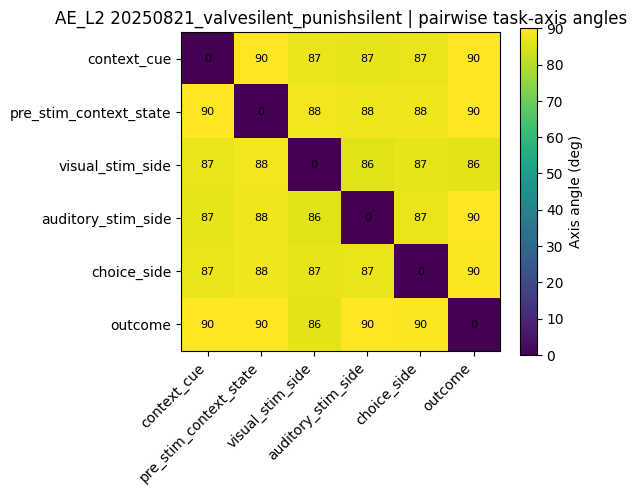

In [275]:
date = "20250821_valvesilent_punishsilent"

angle_mat, axis_vecs = compute_axis_angle_matrix_one_session(
    axis_results = axis_results,
    date=date,
    unsigned=True,   # 0-90 deg, recommended
    verbose=True,
)

display(angle_mat)

fig, ax = plot_axis_angle_matrix(
    angle_mat,
    title=f"{mouse} {date} | pairwise task-axis angles"
)

In [158]:
def compute_fold_axis_stability(result, unsigned=True):
    """
    Computes pairwise angles between fold decoder weights for one axis.
    Low angle = stable decoder axis across folds.
    High angle near 90 = unreliable/noisy axis.
    """
    w = np.asarray(result["fold_weights"], dtype=float)
    w = np.squeeze(w)

    n_neurons = int(np.asarray(result["n_neurons"]).ravel()[0])

    if w.ndim == 1:
        return np.nan, np.array([[0.0]])

    if w.shape[1] != n_neurons and w.shape[0] == n_neurons:
        w = w.T  # folds x neurons

    n_folds = w.shape[0]
    mat = np.full((n_folds, n_folds), np.nan)

    for i in range(n_folds):
        for j in range(n_folds):
            mat[i, j] = angle_between_vectors(w[i], w[j], unsigned=unsigned)

    upper = mat[np.triu_indices(n_folds, k=1)]
    return np.nanmean(upper), mat


def summarize_axis_reliability_one_session(axis_results, date):
    rows = []

    for axis_name, pack in axis_results[date].items():
        if axis_name.startswith("_"):
            continue

        result = pack["result"]
        mean_fold_angle, fold_angle_mat = compute_fold_axis_stability(result)

        rows.append({
            "date": date,
            "axis_name": axis_name,
            "mean_auc": result.get("mean_auc", np.nan),
            "mean_bal_acc": result.get("mean_bal_acc", np.nan),
            "mean_fold_angle_deg": mean_fold_angle,
            "n_neurons": result.get("n_neurons", np.nan),
            "n_trials": result.get("n_trials", np.nan),
        })

    return pd.DataFrame(rows)

In [272]:
reliability_20250612 = summarize_axis_reliability_one_session(
    axis_results,
    "20250909_valvesilent_punishsilent"
)

display(reliability_20250612)

,date,axis_name,mean_auc,mean_bal_acc,mean_fold_angle_deg,n_neurons,n_trials
0,20250909_valvesilent_punishsilent,context_cue,0.558927,0.519085,52.584569,1100,401
1,20250909_valvesilent_punishsilent,pre_stim_context_state,0.529101,0.508659,52.004336,1100,401
2,20250909_valvesilent_punishsilent,visual_stim_side,0.892349,0.835326,50.316876,1100,201
3,20250909_valvesilent_punishsilent,auditory_stim_side,0.992990,0.960238,42.740311,1100,200
4,20250909_valvesilent_punishsilent,choice_side,0.799365,0.681291,48.947697,1100,368
5,20250909_valvesilent_punishsilent,outcome,0.754778,0.655710,51.266317,1100,401


Face decoding context pre stim vs neural decoding

In [229]:
def _safe_mean_in_window(y, t, window=(-0.3, -0.1)):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)

    m = (t >= window[0]) & (t <= window[1]) & np.isfinite(y)
    if not np.any(m):
        return np.nan

    return float(np.nanmean(y[m]))


def _get_scalar_auc_from_axis_result(result):
    """
    For neural axis result.
    Prefer mean_auc if available, otherwise scalarize auc.
    """
    if result is None:
        return np.nan

    if "mean_auc" in result:
        return float(np.nanmean(np.asarray(result["mean_auc"], dtype=float)))

    if "auc" in result:
        return float(np.nanmean(np.asarray(result["auc"], dtype=float)))

    return np.nan


def _get_scalar_bal_acc_from_axis_result(result):
    if result is None:
        return np.nan

    for key in ["mean_bal_acc", "balanced_accuracy", "acc_bal", "mean_balanced_accuracy"]:
        if key in result:
            return float(np.nanmean(np.asarray(result[key], dtype=float)))

    return np.nan


def load_face_motion_decode_payload(
    save_root,
    mouse,
    motion_key="face_motion",
    label_key="modality",
    align_pred="stimOn_times",
):
    path = (
        Path(save_root)
        / mouse
        / f"{motion_key}_decode_{label_key}_aligned_{align_pred}.pkl"
    )

    with open(path, "rb") as f:
        payload = pickle.load(f)

    return payload, path


def load_axis_results_payload(
    save_root,
    mouse,
    filename="axis_results.pkl",
):
    path = Path(save_root) / mouse / "trajectory_axis_results" / filename

    with open(path, "rb") as f:
        axis_results = pickle.load(f)

    return axis_results, path
def collect_face_vs_neural_context_decoding(
    save_root,
    mouse_ids,
    face_motion_key="face_motion",
    face_label_key="modality",
    face_align_pred="stimOn_times",
    neural_axis_name="pre_stim_context_state",
    face_auc_window=(-0.3, -0.1),
):
    rows = []

    for mouse in mouse_ids:
        try:
            face_payload, face_path = load_face_motion_decode_payload(
                save_root=save_root,
                mouse=mouse,
                motion_key=face_motion_key,
                label_key=face_label_key,
                align_pred=face_align_pred,
            )

            axis_results, axis_path = load_axis_results_payload(
                save_root=save_root,
                mouse=mouse,
            )

        except Exception as e:
            print(f"[skip mouse] {mouse}: {repr(e)}")
            continue

        face_results = face_payload.get("results", {})

        for date, face_res in face_results.items():
            if date not in axis_results:
                continue

            if neural_axis_name not in axis_results[date]:
                continue

            neural_pack = axis_results[date][neural_axis_name]
            neural_res = neural_pack["result"]

            # Face motion AUC time course averaged in the same pre-stim window
            face_t = np.asarray(face_res["timepoints"], dtype=float)
            face_auc = _safe_mean_in_window(
                face_res["auc"],
                face_t,
                window=face_auc_window,
            )

            if "shuf_auc" in face_res and face_res["shuf_auc"] is not None:
                face_shuf_auc = _safe_mean_in_window(
                    face_res["shuf_auc"],
                    face_t,
                    window=face_auc_window,
                )
            else:
                face_shuf_auc = np.nan

            # Optional balanced acc in same window
            if "acc_bal" in face_res:
                face_bal_acc = _safe_mean_in_window(
                    face_res["acc_bal"],
                    face_t,
                    window=face_auc_window,
                )
            else:
                face_bal_acc = np.nan

            if "shuf_acc_bal" in face_res and face_res["shuf_acc_bal"] is not None:
                face_shuf_bal_acc = _safe_mean_in_window(
                    face_res["shuf_acc_bal"],
                    face_t,
                    window=face_auc_window,
                )
            else:
                face_shuf_bal_acc = np.nan

            # Neural pre-stim context axis decoding
            neural_auc = _get_scalar_auc_from_axis_result(neural_res)
            neural_bal_acc = _get_scalar_bal_acc_from_axis_result(neural_res)

            n_neurons = neural_res.get("n_neurons", np.nan)
            n_trials_neural = neural_res.get("n_trials", np.nan)

            if "final_trial_mask" in face_res:
                n_trials_face = int(np.sum(np.asarray(face_res["final_trial_mask"], dtype=bool)))
            else:
                n_trials_face = np.nan

            rows.append({
                "mouse": mouse,
                "date": date,
                "neural_axis": neural_axis_name,

                "face_auc_pre_stim": face_auc,
                "face_shuf_auc_pre_stim": face_shuf_auc,
                "face_auc_minus_shuf": face_auc - face_shuf_auc,

                "face_bal_acc_pre_stim": face_bal_acc,
                "face_shuf_bal_acc_pre_stim": face_shuf_bal_acc,
                "face_bal_acc_minus_shuf": face_bal_acc - face_shuf_bal_acc,

                "neural_auc_pre_stim_axis": neural_auc,
                "neural_auc_minus_0p5": neural_auc - 0.5,

                "neural_bal_acc_pre_stim_axis": neural_bal_acc,
                "neural_bal_acc_minus_0p5": neural_bal_acc - 0.5,

                "n_neurons": n_neurons,
                "n_trials_neural": n_trials_neural,
                "n_trials_face": n_trials_face,
            })

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df["date_num"] = (
            df["date"]
            .astype(str)
            .str.extract(r"(\d+)", expand=False)
            .astype(float)
        )
        df = df.sort_values(["mouse", "date_num", "date"]).reset_index(drop=True)

    return df

def plot_face_vs_neural_context_scatter(
    df,
    x_col="face_auc_pre_stim",
    y_col="neural_auc_pre_stim_axis",
    use_mouse_colors=True,
    title="Pre-stim context decoding: face motion vs neural population",
):
    d = df[[x_col, y_col, "mouse"]].copy()
    d = d[np.isfinite(d[x_col]) & np.isfinite(d[y_col])]

    fig, ax = plt.subplots(figsize=(5.2, 4.6))

    if use_mouse_colors:
        for mouse, dm in d.groupby("mouse"):
            ax.scatter(dm[x_col], dm[y_col], s=35, alpha=0.75, label=mouse)
    else:
        ax.scatter(d[x_col], d[y_col], s=35, alpha=0.75)

    ax.axvline(0.5, color="k", ls="--", lw=1, alpha=0.5)
    ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.5)

    if len(d) >= 3:
        r, p = stats.pearsonr(d[x_col], d[y_col])
        rho, p_s = stats.spearmanr(d[x_col], d[y_col])
        ax.set_title(
            f"{title}\nPearson r={r:.2f}, p={p:.2g}; Spearman ρ={rho:.2f}, p={p_s:.2g}",
            fontsize=10,
        )
    else:
        ax.set_title(title, fontsize=10)

    ax.set_xlabel("Face motion context AUC, mean -0.3 to -0.1 s before stim")
    ax.set_ylabel("Neural pre-stim context axis AUC")

    if use_mouse_colors:
        ax.legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    return fig, ax

def _normalize_date_string(x):
    """
    Convert '20250701_valvesilent' or training date entries into '20250701'.
    """
    if pd.isna(x):
        return None

    s = str(x)

    # handles strings like '20250701_valvesilent'
    m = pd.Series([s]).str.extract(r"(\d{8})", expand=False).iloc[0]
    if pd.notna(m):
        return str(m)

    # handles datetime-like objects
    try:
        ts = pd.to_datetime(x, errors="coerce")
        if pd.notna(ts):
            return ts.strftime("%Y%m%d")
    except Exception:
        pass

    return None


def build_training_performance_table(agg_data, mouse_ids):
    rows = []

    for mouse in mouse_ids:
        tr = agg_data[mouse]["training"]

        vis = np.asarray(tr["accuracies_vis"], dtype=float)
        aud = np.asarray(tr["accuracies_aud"], dtype=float)
        dates = np.asarray(tr["training_dates"])

        n = min(len(vis), len(aud), len(dates))

        for i in range(n):
            v = vis[i]
            a = aud[i]

            # convert percent to fraction if needed
            if np.isfinite(v) and v > 1.5:
                v = v / 100.0
            if np.isfinite(a) and a > 1.5:
                a = a / 100.0

            rows.append({
                "mouse": mouse,
                "date_norm": _normalize_date_string(dates[i]),
                "training_i": i,
                "perf_vis": v,
                "perf_aud": a,
                "perf_mean": np.nanmean([v, a]),
            })

    return pd.DataFrame(rows)


def add_training_performance_to_face_neural_df(
    df,
    agg_data,
    mouse_ids,
    nearest_if_no_exact=True,
):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["date_norm"] = df["date"].apply(_normalize_date_string)

    perf_df = build_training_performance_table(agg_data, mouse_ids)

    merged = df.merge(
        perf_df,
        on=["mouse", "date_norm"],
        how="left",
    )

    # Fallback: if exact imaging date is not in training_dates, use nearest date within mouse
    if nearest_if_no_exact:
        missing = merged["perf_mean"].isna()

        if missing.any():
            perf_df2 = perf_df.copy()
            perf_df2 = perf_df2[np.isfinite(perf_df2["perf_mean"])].copy()
            perf_df2["date_num_perf"] = perf_df2["date_norm"].astype(float)

            for idx in merged.index[missing]:
                mouse = merged.loc[idx, "mouse"]
                date_norm = merged.loc[idx, "date_norm"]

                if date_norm is None or pd.isna(date_norm):
                    continue

                dnum = float(date_norm)
                pm = perf_df2[perf_df2["mouse"] == mouse].copy()

                if len(pm) == 0:
                    continue

                nearest_idx = (pm["date_num_perf"] - dnum).abs().idxmin()

                for col in ["training_i", "perf_vis", "perf_aud", "perf_mean"]:
                    merged.loc[idx, col] = perf_df2.loc[nearest_idx, col]

    return merged

def plot_face_vs_neural_context_scatter_by_perf(
    df,
    x_col="face_auc_pre_stim",
    y_col="neural_auc_pre_stim_axis",
    perf_col="perf_mean",
    title="Pre-stim context decoding: face motion vs neural population",
    cmap="viridis",
    vmin=0.5,
    vmax=1.0,
    annotate_mouse=False,
):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    needed = [x_col, y_col, perf_col, "mouse", "date"]
    needed = [c for c in needed if c in df.columns]

    d = df[needed].copy()
    d = d[
        np.isfinite(d[x_col]) &
        np.isfinite(d[y_col]) &
        np.isfinite(d[perf_col])
    ]

    fig, ax = plt.subplots(figsize=(5.4, 4.7))

    sc = ax.scatter(
        d[x_col],
        d[y_col],
        c=d[perf_col],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )

    ax.axvline(0.5, color="k", ls="--", lw=1, alpha=0.5)
    ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.5)

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Mean training performance\n(visual/auditory average)")

    if len(d) >= 3:
        r, p = stats.pearsonr(d[x_col], d[y_col])
        rho, p_s = stats.spearmanr(d[x_col], d[y_col])
        ax.set_title(
            f"{title}\nPearson r={r:.2f}, p={p:.2g}; Spearman ρ={rho:.2f}, p={p_s:.2g}",
            fontsize=10,
        )
    else:
        ax.set_title(title, fontsize=10)

    ax.set_xlabel("Face motion context AUC, mean -0.3 to -0.1 s before stim")
    ax.set_ylabel("Neural pre-stim context axis AUC")

    if annotate_mouse:
        for _, row in d.iterrows():
            ax.text(
                row[x_col],
                row[y_col],
                row["mouse"],
                fontsize=6,
                alpha=0.65,
            )

    plt.tight_layout()
    return fig, ax

In [191]:
save_root = Path(r"I:\Cerebellum_Imaging_Dec2025")

df_face_neural_context = collect_face_vs_neural_context_decoding(
    save_root=save_root,
    mouse_ids=mouse_ids,
    face_motion_key="face_motion",
    face_label_key="modality",
    face_align_pred="stimOn_times",
    neural_axis_name="pre_stim_context_state",
    face_auc_window=(-0.3, -0.1),
)

df_face_neural_context.head()

,mouse,date,neural_axis,face_auc_pre_stim,face_shuf_auc_pre_stim,face_auc_minus_shuf,face_bal_acc_pre_stim,face_shuf_bal_acc_pre_stim,face_bal_acc_minus_shuf,neural_auc_pre_stim_axis,neural_auc_minus_0p5,neural_bal_acc_pre_stim_axis,neural_bal_acc_minus_0p5,n_neurons,n_trials_neural,n_trials_face,date_num
0,AB_R2,20250527,pre_stim_context_state,0.533686,0.502161,0.031525,0.550361,0.510294,0.040067,0.574111,0.074111,0.547833,0.047833,716,241,242,20250527.0
1,AB_R2,20250612_valvesilent,pre_stim_context_state,0.533879,0.498485,0.035394,0.539583,0.503150,0.036433,0.505710,0.005710,0.500000,0.000000,516,360,360,20250612.0
2,AB_R2,20250617_valvesilent,pre_stim_context_state,0.566044,0.498186,0.067857,0.575175,0.511167,0.064008,0.614474,0.114474,0.581579,0.081579,567,198,199,20250617.0
3,AB_R2,20250625_valvesilent,pre_stim_context_state,0.632794,0.500706,0.132088,0.597962,0.476697,0.121264,0.553794,0.053794,0.526326,0.026326,689,321,326,20250625.0
4,AB_R2,20250701_valvesilent,pre_stim_context_state,0.637931,0.499141,0.138789,0.619358,0.494240,0.125117,0.667525,0.167525,0.613542,0.113542,564,321,322,20250701.0


In [226]:
df_face_neural_context_perf = add_training_performance_to_face_neural_df(
    df_face_neural_context,
    agg_data=agg_data,
    mouse_ids=mouse_ids,
)

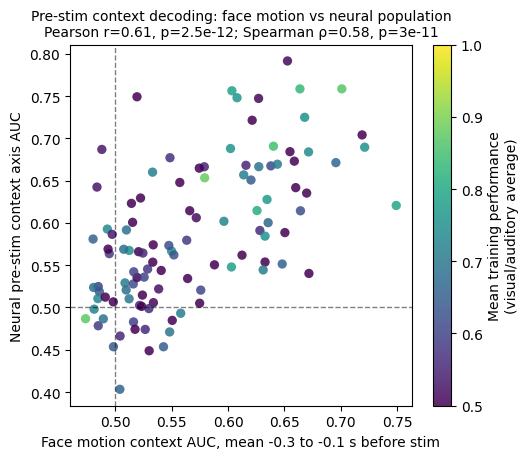

In [268]:

fig, ax = plot_face_vs_neural_context_scatter_by_perf(
    df_face_neural_context_perf,
    x_col="face_auc_pre_stim",
    y_col="neural_auc_pre_stim_axis",
    perf_col="perf_mean",
    title="Pre-stim context decoding: face motion vs neural population",
)

In [269]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\Fig3"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"scatter_prestim_neural_vs_face_motion_decoding_context.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"scatter_prestim_neural_vs_face_motion_decoding_context.png"),
                dpi=300, bbox_inches='tight')

In [249]:
def population_decode_timecourse_session_by_roi(
    data,
    mouse,
    date,
    predictors,
    preds_to_exclude,
    psth_time_start,
    psth_time_end,
    align_pred,
    roi_masks_full,          # REQUIRED for ROI decoding
    frac_thresh=0.2,
    roi_order=None,

    label_key='choice',
    custom_labels=None,
    trial_mask=None,
    frames_per_s=15,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=5000,
    return_tensor=False,
    do_shuffle=True,
    require_reward_psth=True,

    include_all_neurons=True,
    all_neurons_key='all',

    # NEW
    auc_n_shuffles=200,
    compute_auc=True,
    compute_accuracy=True,
):
    """
    Returns
    -------
    out_by_roi : dict
        dict[roi] -> session decode output.
        Includes `all_neurons_key` if include_all_neurons=True.

    meta : dict
        Session metadata and neuron counts by ROI/arm.

    Notes
    -----
    - Accuracy curves come from decode_timecourse_L1_fast directly.
    - AUC curves are computed from out-of-fold scores using returned cv_models.
    """
    from sklearn.metrics import roc_auc_score

    if roi_masks_full is None:
        raise ValueError("roi_masks_full must be provided for ROI-wise decoding.")

    # ---- load arm-level data once ----
    arm_data = {}
    for arm in ("arm1", "arm2"):
        if arm not in data[mouse][date]:
            continue

        arm_path = os.path.join(
            r'I:\Cerebellum_imaging_Dec2025',
            mouse, date, arm
        )
        dff = np.load(os.path.join(arm_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))
        if align_pred == 'consume_times':
            data[mouse][date][arm]['table_for_img']['consume_times'] = data[mouse][date][arm]['table_for_img']['reward_consume_times'].fillna(data[mouse][date][arm]['table_for_img']['punish_consume_times'])
        if align_pred == 'stimOn_times':
            data[mouse][date][arm]['table_for_img']['stimOn_times'] = data[mouse][date][arm]['table_for_img']["vis_stimOn_times"].combine_first(data[mouse][date][arm]['table_for_img']["aud_stimOn_times"])
            print(np.array(data[mouse][date][arm]['table_for_img']['stimOn_times']))
        arm_data[arm] = dict(
            dff=dff,
            neurons=data[mouse][date][arm]['stat'],
            design_matrix=data[mouse][date][arm]['design_matrix'],
            table_for_img=data[mouse][date][arm]['table_for_img'],
        )

    if len(arm_data) == 0:
        raise ValueError(f"No arms found for {mouse} {date}")

    # ---- group neurons into ROIs (separately per arm) ----
    roi_to_neurons_by_arm = {}
    roi_counts_by_arm = {}
    roi_neuron_idx_by_arm = {}
    final_roi_order = None

    for arm, ad in arm_data.items():
        roi_to_neurons, roi_neuron_idx, roi_counts, unassigned, final_roi_order = group_neurons_by_roi(
            ad["neurons"],
            roi_masks_full=roi_masks_full,
            roi_order=roi_order if final_roi_order is None else final_roi_order,
            frac_thresh=frac_thresh,
            require_reward_psth=require_reward_psth,
        )
        roi_to_neurons_by_arm[arm] = roi_to_neurons
        roi_neuron_idx_by_arm[arm] = roi_neuron_idx
        roi_counts_by_arm[arm] = roi_counts
    if final_roi_order is None:
        final_roi_order = list(np.asarray(list(roi_masks_full.keys())))

    decode_keys = list(final_roi_order)
    if include_all_neurons:
        if all_neurons_key in decode_keys:
            raise ValueError(f"`all_neurons_key`='{all_neurons_key}' already exists in roi_order.")
        decode_keys.append(all_neurons_key)

    # ---- labels: use arm1 if present else arm2 ----
    table_ref = arm_data["arm1"]["table_for_img"] if "arm1" in arm_data else arm_data["arm2"]["table_for_img"]
    if custom_labels is not None:
        labels_full = np.asarray(custom_labels).ravel()
    else:
        labels_full = np.asarray(table_ref[label_key]).ravel()

    timepoints = None
    out_by_roi = {}

    counts_total = {}
    counts_arm1 = {}
    counts_arm2 = {}

    def _scores_from_clf(clf, X, pos_col=1):
        if hasattr(clf, "predict_proba"):
            return clf.predict_proba(X)[:, pos_col]
        if hasattr(clf, "decision_function"):
            return clf.decision_function(X)
        raise ValueError("Classifier has neither predict_proba nor decision_function.")

    for roi in decode_keys:
        arm_tensors = []
        arm_trial_masks = []
        arm_psth_idxs = []

        for arm, ad in arm_data.items():
            if roi == all_neurons_key:
                neurons_roi = list(ad["neurons"])
                neurons_idx = np.arange(len(ad["neurons"]))
            else:
                neurons_roi = roi_to_neurons_by_arm[arm].get(roi, [])
                neurons_idx = roi_neuron_idx_by_arm[arm].get(roi, [])

            if len(neurons_roi) == 0:
                continue

            roi_dff = ad["dff"][neurons_idx, :]
            rt, psth_frame_idx, arm_trial_mask = build_residual_tensor(
                neurons_roi,
                roi_dff,
                ad["design_matrix"],
                predictors,
                ad["table_for_img"],
                preds_to_exclude,
                psth_time_start,
                psth_time_end,
                align_pred,
                frames_per_s,
            )
            if rt is None:
                continue

            arm_tensors.append(rt)
            arm_trial_masks.append(arm_trial_mask)
            arm_psth_idxs.append(psth_frame_idx)

        if len(arm_tensors) == 0:
            continue

        # ---- merge arms if both present ----
        if len(arm_tensors) == 2:
            rt1, rt2 = arm_tensors
            tm1, tm2 = arm_trial_masks
            idx1, idx2 = arm_psth_idxs

            if rt1.shape[1] != rt2.shape[1]:
                raise ValueError(f"{mouse} {date} ROI={roi}: arm1/arm2 trials mismatch")
            if not np.array_equal(tm1, tm2):
                raise ValueError(f"{mouse} {date} ROI={roi}: arm1/arm2 trial masks mismatch")

            residual_tensor = np.concatenate([rt1, rt2], axis=0)  # features x trials x time
            psth_frame_idx = idx1
            arm_trial_mask = tm1
        else:
            residual_tensor = arm_tensors[0]
            psth_frame_idx = arm_psth_idxs[0]
            arm_trial_mask = arm_trial_masks[0]

        # ---- labels and final trial mask ----
        labels = labels_full[arm_trial_mask]

        final_trial_mask = np.ones_like(labels, dtype=bool)
        if trial_mask is not None:
            trial_mask_local = np.asarray(trial_mask).ravel()
            trial_mask_local = trial_mask_local[arm_trial_mask]
            final_trial_mask &= trial_mask_local

        if label_key == 'choice':
            final_trial_mask &= (labels != 0)

        y_chk = labels[final_trial_mask]
        if y_chk.size == 0 or len(np.unique(y_chk)) != 2:
            continue
        print(f"{mouse} {date} ROI={roi}: decoding with {residual_tensor.shape[0]} neurons")
        decode_out = decode_timecourse_L1_fast(
            residual_tensor,
            labels,
            trial_mask=final_trial_mask,
            n_splits=n_splits,
            C=C,
            l1_ratio=l1_ratio,
            random_state=random_state,
            max_iter=max_iter,
            do_shuffle=do_shuffle,
            return_cv_models=bool(compute_auc),
        )

        n_time = psth_frame_idx.shape[1]
        if timepoints is None:
            timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

        out = dict(
            mouse=mouse,
            date=date,
            roi=roi,
            align_pred=align_pred,
            timepoints=timepoints,
            baseline=decode_out.get('majority_baseline', None),
            psth_frame_idx=psth_frame_idx,
            labels=labels,
            final_trial_mask=final_trial_mask,
            base_trial_mask=arm_trial_mask,
            n_neurons=residual_tensor.shape[0],
        )

        # -------------------------
        # Accuracy outputs
        # -------------------------
        if compute_accuracy:
            out.update(
                acc=decode_out['acc_time_raw'],
                acc_std=decode_out['acc_std_time_raw'],
                acc_bal=decode_out['acc_time_bal'],
                acc_bal_std=decode_out['acc_std_time_bal'],
                shuf_acc=decode_out.get('shuf_acc_time_raw', None),
                shuf_acc_std=decode_out.get('shuf_acc_std_time_raw', None),
                shuf_acc_bal=decode_out.get('shuf_acc_time_bal', None),
                shuf_acc_bal_std=decode_out.get('shuf_acc_std_time_bal', None),
            )

        # -------------------------
        # AUC outputs
        # -------------------------
        if compute_auc:
            cv = decode_out["cv_models"]
            fold_models_by_time = cv["fold_models_by_time"]   # list[n_time][n_splits]
            splits = cv["splits"]                             # list[(train_idx, test_idx)] in masked space
            classes_ = np.asarray(cv.get("classes_", None))

            keep = final_trial_mask
            y_all = np.asarray(labels)[keep].ravel()

            uniq = np.unique(y_all)
            if uniq.size != 2:
                raise ValueError(f"ROC AUC requires 2 classes after masking; got {uniq}.")

            pos_class = classes_[1] if classes_ is not None and classes_.size >= 2 else uniq.max()
            y01 = (y_all == pos_class).astype(int)

            # (time, trials_masked, features)
            X_all = residual_tensor[:, keep, :].transpose(2, 1, 0).astype(np.float32, copy=False)
            X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

            auc_time = np.full(n_time, np.nan, dtype=float)
            auc_fold_std = np.full(n_time, np.nan, dtype=float)

            shuf_auc_mean = np.full(n_time, np.nan, dtype=float) if do_shuffle else None
            shuf_auc_std = np.full(n_time, np.nan, dtype=float) if do_shuffle else None

            for t in range(n_time):
                scores = np.full(y01.shape[0], np.nan, dtype=float)
                fold_aucs = np.full(len(splits), np.nan, dtype=float)

                for k, (_, test_idx) in enumerate(splits):
                    test_idx = np.asarray(test_idx, dtype=int)

                    pack = fold_models_by_time[t][k]
                    mu = np.asarray(pack["mu"])
                    sd = np.asarray(pack["sd"])
                    clf = pack["clf"]

                    Xt = X_all[t][test_idx]

                    sd_safe = np.where(sd == 0, 1.0, sd)
                    Xt_z = (Xt - mu) / sd_safe

                    if hasattr(clf, "classes_"):
                        pos_matches = np.where(clf.classes_ == pos_class)[0]
                        pos_col = int(pos_matches[0]) if len(pos_matches) > 0 else 1
                    else:
                        pos_col = 1

                    s = _scores_from_clf(clf, Xt_z, pos_col=pos_col)
                    scores[test_idx] = s

                    y_fold = y01[test_idx]
                    if np.unique(y_fold).size == 2:
                        fold_aucs[k] = roc_auc_score(y_fold, s)

                if not np.all(np.isfinite(scores)):
                    raise ValueError(
                        f"{mouse} {date} ROI={roi}: missing out-of-fold scores at time index {t}. "
                        "This implies test_idx coverage is incomplete."
                    )

                auc_time[t] = roc_auc_score(y01, scores)
                good = np.isfinite(fold_aucs)
                auc_fold_std[t] = np.std(fold_aucs[good], ddof=1) if np.sum(good) > 1 else 0.0

                if do_shuffle:
                    rng = np.random.default_rng(random_state + 1000 + t)
                    shufs = np.empty(int(auc_n_shuffles), dtype=float)
                    for i in range(int(auc_n_shuffles)):
                        y_shuf = rng.permutation(y01)
                        shufs[i] = roc_auc_score(y_shuf, scores)
                    shuf_auc_mean[t] = shufs.mean()
                    shuf_auc_std[t] = shufs.std(ddof=1) if shufs.size > 1 else 0.0

            out.update(
                auc=auc_time,
                auc_std=auc_fold_std,
                shuf_auc=shuf_auc_mean,
                shuf_auc_std=shuf_auc_std,
            )
            print(f'peak AUC for {mouse} {date} ROI={roi}: {np.nanmax(auc_time):.3f}')
        if return_tensor:
            out['residual_tensor'] = residual_tensor

        out["cv_models_pack"] = dict(
            cv_models=decode_out.get("cv_models", None),
            roi=roi,
            align_pred=align_pred,
            psth_time_start=psth_time_start,
            psth_time_end=psth_time_end,
            frames_per_s=frames_per_s,
            label_key=label_key,
            auc_n_shuffles=int(auc_n_shuffles),
            compute_auc=bool(compute_auc),
            compute_accuracy=bool(compute_accuracy),
        )

        out_by_roi[roi] = out

        # ---- counts ----
        if roi == all_neurons_key:
            c1 = len(arm_data["arm1"]["neurons"]) if "arm1" in arm_data else 0
            c2 = len(arm_data["arm2"]["neurons"]) if "arm2" in arm_data else 0
        else:
            c1 = roi_counts_by_arm.get("arm1", {}).get(roi, 0)
            c2 = roi_counts_by_arm.get("arm2", {}).get(roi, 0)

        counts_arm1[roi] = c1
        counts_arm2[roi] = c2
        counts_total[roi] = c1 + c2

    meta = dict(
        mouse=mouse,
        date=date,
        frac_thresh=frac_thresh,
        roi_order=final_roi_order,
        decode_keys=decode_keys,
        all_neurons_key=all_neurons_key if include_all_neurons else None,
        n_neurons_by_roi_total=counts_total,
        n_neurons_by_roi_arm1=counts_arm1,
        n_neurons_by_roi_arm2=counts_arm2,
    )
    return out_by_roi, meta

In [213]:
align_pred = 'ruleCue_times'
preds_to_exclude = ['vis_ruleCue_times', 'aud_ruleCue_times']
label_key = 'modality'
for mouse in mouse_ids:
    dates = list(agg_data[mouse].keys())
    results_all = []
    for date in dates:
        print(date)
        # if date[:3] != '202' or 'valvesilent' not in date or 'punishsilent' not in date:
        #     continue
        if date == 'training':
            continue
        out_by_roi, meta = population_decode_timecourse_session_by_roi(
                agg_data,
                mouse,
                date,
                predictors,
                preds_to_exclude=preds_to_exclude,
                psth_time_start=psth_time_start,
                psth_time_end=psth_time_end,
                align_pred = align_pred,
                roi_masks_full = roi_masks_full,          # REQUIRED for ROI decoding
                frac_thresh=0.2,
                roi_order=None,

                label_key=label_key,
                custom_labels=None,
                trial_mask=None,
                frames_per_s=15,
                C=1.0,
                l1_ratio=1.0,
                n_splits=5,
                random_state=0,
                max_iter=5000,
                return_tensor=False,
                do_shuffle=True,
                require_reward_psth=False,
                include_all_neurons=True,
                all_neurons_key='all',

                # NEW
                auc_n_shuffles=100,
                compute_auc=True,
                compute_accuracy=True,
            )
        results_all.append(out_by_roi)
    if len(results_all) > 0:
        with open(os.path.join(r'I:\Cerebellum_imaging_Dec2025',mouse, 'ruleCue_neural_decoding_context_by_roi_shuffled_results_auc.pkl'), 'wb') as f:
            pickle.dump(results_all, f)

20250612
AE_L2 20250612 ROI=simplex: decoding with 406 neurons
peak AUC for AE_L2 20250612 ROI=simplex: 0.819
AE_L2 20250612 ROI=crus_I: decoding with 76 neurons
peak AUC for AE_L2 20250612 ROI=crus_I: 0.627
AE_L2 20250612 ROI=lob_V: decoding with 328 neurons
peak AUC for AE_L2 20250612 ROI=lob_V: 0.868
AE_L2 20250612 ROI=lob_VI: decoding with 162 neurons
peak AUC for AE_L2 20250612 ROI=lob_VI: 0.667
AE_L2 20250612 ROI=all: decoding with 1074 neurons
peak AUC for AE_L2 20250612 ROI=all: 0.890
20250624_valvesilent
AE_L2 20250624_valvesilent ROI=simplex: decoding with 405 neurons
peak AUC for AE_L2 20250624_valvesilent ROI=simplex: 0.730
AE_L2 20250624_valvesilent ROI=crus_I: decoding with 197 neurons
peak AUC for AE_L2 20250624_valvesilent ROI=crus_I: 0.666
AE_L2 20250624_valvesilent ROI=lob_V: decoding with 244 neurons
peak AUC for AE_L2 20250624_valvesilent ROI=lob_V: 0.786
AE_L2 20250624_valvesilent ROI=lob_VI: decoding with 219 neurons
peak AUC for AE_L2 20250624_valvesilent ROI=lob

In [295]:
def mean_in_window(y, t, window, inclusive=True):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)

    if inclusive:
        m = (t >= window[0]) & (t <= window[1]) & np.isfinite(y)
    else:
        m = (t >= window[0]) & (t < window[1]) & np.isfinite(y)

    if not np.any(m):
        return np.nan

    return float(np.nanmean(y[m]))


def scalarize_decoder_metric(res, keys=("mean_auc", "auc")):
    """
    For axis_results where auc may be scalar, 1D, or fold-wise.
    """
    if res is None:
        return np.nan

    for key in keys:
        if key in res and res[key] is not None:
            arr = np.asarray(res[key], dtype=float)
            if arr.size == 0:
                return np.nan
            return float(np.nanmean(arr))

    return np.nan

def load_rulecue_auc_results(
    save_root,
    mouse,
    filename="ruleCue_neural_decoding_context_by_roi_shuffled_results_auc.pkl",
):
    path = Path(save_root) / mouse / filename
    with open(path, "rb") as f:
        payload = pickle.load(f)
    return payload, path


def flatten_rulecue_auc_results(
    payload,
    mouse,
    window=(0.0, 0.2),
    rois_to_keep=None,   # e.g. ["all"] or ["lob_V", "lob_VI", "simplex", "crus_I"]
):
    rows = []

    for session_i, session_dict in enumerate(payload):
        if not isinstance(session_dict, dict):
            continue

        for roi, res in session_dict.items():
            if rois_to_keep is not None and roi not in rois_to_keep:
                continue

            if not isinstance(res, dict):
                continue

            if "timepoints" not in res:
                continue

            date = res.get("date", None)
            if date is None:
                continue

            t = np.asarray(res["timepoints"], dtype=float)

            rulecue_auc = (
                mean_in_window(res["auc"], t, window)
                if "auc" in res and res["auc"] is not None
                else np.nan
            )

            rulecue_shuf_auc = (
                mean_in_window(res["shuf_auc"], t, window)
                if "shuf_auc" in res and res["shuf_auc"] is not None
                else np.nan
            )

            rulecue_acc_bal = (
                mean_in_window(res["acc_bal"], t, window)
                if "acc_bal" in res and res["acc_bal"] is not None
                else np.nan
            )

            rulecue_shuf_acc_bal = (
                mean_in_window(res["shuf_acc_bal"], t, window)
                if "shuf_acc_bal" in res and res["shuf_acc_bal"] is not None
                else np.nan
            )

            rows.append({
                "mouse": mouse,
                "date": date,
                "roi": roi,
                "session_i": session_i,

                "rulecue_auc_0_to_0p2": rulecue_auc,
                "rulecue_shuf_auc_0_to_0p2": rulecue_shuf_auc,
                "rulecue_auc_minus_shuf": rulecue_auc - rulecue_shuf_auc,

                "rulecue_acc_bal_0_to_0p2": rulecue_acc_bal,
                "rulecue_shuf_acc_bal_0_to_0p2": rulecue_shuf_acc_bal,
                "rulecue_acc_bal_minus_shuf": rulecue_acc_bal - rulecue_shuf_acc_bal,

                "rulecue_n_neurons": res.get("n_neurons", np.nan),
                "rulecue_baseline": res.get("baseline", np.nan),
            })

    return pd.DataFrame(rows)

def load_axis_results(
    save_root,
    mouse,
    filename="axis_results.pkl",
):
    path = Path(save_root) / mouse / "trajectory_axis_results" / filename
    with open(path, "rb") as f:
        axis_results = pickle.load(f)
    return axis_results, path


def extract_prestim_context_axis_auc(
    axis_results,
    mouse,
    axis_name="pre_stim_context_state",
):
    rows = []

    for date, date_dict in axis_results.items():
        if axis_name not in date_dict:
            continue

        pack = date_dict[axis_name]
        res = pack["result"]

        auc = scalarize_decoder_metric(res, keys=("mean_auc", "auc"))
        bal_acc = scalarize_decoder_metric(
            res,
            keys=("mean_bal_acc", "balanced_accuracy", "acc_bal")
        )

        rows.append({
            "mouse": mouse,
            "date": date,
            "prestim_axis": axis_name,

            "prestim_auc_minus0p3_to_minus0p1": auc,
            "prestim_auc_minus_0p5": auc - 0.5,

            "prestim_bal_acc": bal_acc,
            "prestim_bal_acc_minus_0p5": bal_acc - 0.5,

            "prestim_n_neurons": res.get("n_neurons", np.nan),
            "prestim_n_trials": res.get("n_trials", np.nan),
        })

    return pd.DataFrame(rows)

def collect_rulecue_auc_vs_prestim_context_auc(
    save_root,
    mouse_ids,
    rulecue_filename="ruleCue_neural_decoding_context_by_roi_shuffled_results_auc.pkl",
    axis_filename="axis_results.pkl",
    axis_name="pre_stim_context_state",
    rulecue_window=(0.0, 0.2),
    rois_to_keep=("all",),
):
    all_rulecue = []
    all_prestim = []

    for mouse in mouse_ids:
        try:
            rulecue_payload, rulecue_path = load_rulecue_auc_results(
                save_root=save_root,
                mouse=mouse,
                filename=rulecue_filename,
            )

            df_rulecue_mouse = flatten_rulecue_auc_results(
                rulecue_payload,
                mouse=mouse,
                window=rulecue_window,
                rois_to_keep=None if rois_to_keep is None else list(rois_to_keep),
            )

            axis_results, axis_path = load_axis_results(
                save_root=save_root,
                mouse=mouse,
                filename=axis_filename,
            )

            df_prestim_mouse = extract_prestim_context_axis_auc(
                axis_results,
                mouse=mouse,
                axis_name=axis_name,
            )

            df_rulecue_mouse["rulecue_path"] = str(rulecue_path)
            df_prestim_mouse["axis_path"] = str(axis_path)

            all_rulecue.append(df_rulecue_mouse)
            all_prestim.append(df_prestim_mouse)

        except Exception as e:
            print(f"[skip mouse] {mouse}: {repr(e)}")

    df_rulecue = pd.concat(all_rulecue, ignore_index=True) if len(all_rulecue) else pd.DataFrame()
    df_prestim = pd.concat(all_prestim, ignore_index=True) if len(all_prestim) else pd.DataFrame()

    df = df_rulecue.merge(
        df_prestim,
        on=["mouse", "date"],
        how="inner",
    )

    if len(df) > 0:
        df["date_num"] = (
            df["date"]
            .astype(str)
            .str.extract(r"(\d+)", expand=False)
            .astype(float)
        )
        df = df.sort_values(["mouse", "date_num", "roi"]).reset_index(drop=True)

    return df, df_rulecue, df_prestim

def _normalize_date_string(x):
    """
    Convert dates like 20250701, '20250701_valvesilent',
    np.datetime64, or pandas Timestamp into 'YYYYMMDD'.
    """
    if pd.isna(x):
        return None

    # datetime-like
    try:
        ts = pd.to_datetime(x, errors="coerce")
        if pd.notna(ts):
            return ts.strftime("%Y%m%d")
    except Exception:
        pass

    s = str(x)

    # extract first 8 consecutive digits
    m = pd.Series([s]).str.extract(r"(\d{8})", expand=False).iloc[0]
    if pd.notna(m):
        return str(m)

    # fallback: extract first numeric block
    m = pd.Series([s]).str.extract(r"(\d+)", expand=False).iloc[0]
    if pd.notna(m):
        return str(m)[:8]

    return None


def build_training_performance_table(
    agg_data,
    mouse_ids,
    normalize_percent=True,
):
    """
    Builds table with visual, auditory, and mean performance per training day.

    Assumes:
        agg_data[mouse]['training']['accuracies_vis']
        agg_data[mouse]['training']['accuracies_aud']
        agg_data[mouse]['training']['training_dates']
    """
    rows = []

    for mouse in mouse_ids:
        tr = agg_data[mouse]["training"]

        vis = np.asarray(tr["accuracies_vis"], dtype=float)
        aud = np.asarray(tr["accuracies_aud"], dtype=float)
        dates = np.asarray(tr["training_dates"])

        n = min(len(vis), len(aud), len(dates))

        for i in range(n):
            v = vis[i]
            a = aud[i]

            # In case accuracies are stored as percent instead of fraction
            if normalize_percent:
                if np.isfinite(v) and v > 1.5:
                    v = v / 100.0
                if np.isfinite(a) and a > 1.5:
                    a = a / 100.0

            rows.append({
                "mouse": mouse,
                "date_norm": _normalize_date_string(dates[i]),
                "training_i": i,
                "perf_vis": v,
                "perf_aud": a,
                "perf_mean": np.nanmean([v, a]),
            })

    return pd.DataFrame(rows)


def add_training_performance_to_decode_df(
    df,
    agg_data,
    mouse_ids,
    nearest_if_no_exact=True,
):
    """
    Adds perf_vis, perf_aud, perf_mean to decoding dataframe.

    Exact match uses date prefix, e.g. '20250701_valvesilent' -> '20250701'.
    If no exact match, optionally uses nearest training date within mouse.
    """
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["date_norm"] = df["date"].apply(_normalize_date_string)

    perf_df = build_training_performance_table(
        agg_data,
        mouse_ids,
        normalize_percent=True,
    )

    merged = df.merge(
        perf_df,
        on=["mouse", "date_norm"],
        how="left",
    )

    if nearest_if_no_exact:
        missing = merged["perf_mean"].isna()

        if missing.any():
            perf_df2 = perf_df.copy()
            perf_df2["date_num_perf"] = perf_df2["date_norm"].astype(float)

            for idx in merged.index[missing]:
                mouse = merged.loc[idx, "mouse"]
                date_norm = merged.loc[idx, "date_norm"]

                if date_norm is None or pd.isna(date_norm):
                    continue

                dnum = float(date_norm)
                pm = perf_df2[perf_df2["mouse"] == mouse].copy()

                if len(pm) == 0:
                    continue

                nearest_idx = (pm["date_num_perf"] - dnum).abs().idxmin()

                for col in ["training_i", "perf_vis", "perf_aud", "perf_mean"]:
                    merged.loc[idx, col] = perf_df2.loc[nearest_idx, col]

    return merged

In [ ]:
save_root = Path(r"I:\Cerebellum_Imaging_Dec2025")

df_rulecue_vs_prestim_auc, df_rulecue_auc_only, df_prestim_axis_only = collect_rulecue_auc_vs_prestim_context_auc(
    save_root=save_root,
    mouse_ids=mouse_ids,
    rulecue_filename="ruleCue_neural_decoding_context_by_roi_shuffled_results_auc.pkl",
    axis_filename="axis_results.pkl",
    axis_name="pre_stim_context_state",
    rulecue_window=(0.0, 0.2),
    rois_to_keep=("all",),   # cleanest all-neuron vs all-neuron comparison
)

df_rulecue_vs_prestim_auc.head()

,mouse,date,roi,session_i,rulecue_auc_0_to_0p2,rulecue_shuf_auc_0_to_0p2,rulecue_auc_minus_shuf,rulecue_acc_bal_0_to_0p2,rulecue_shuf_acc_bal_0_to_0p2,rulecue_acc_bal_minus_shuf,...,rulecue_path,prestim_axis,prestim_auc_minus0p3_to_minus0p1,prestim_auc_minus_0p5,prestim_bal_acc,prestim_bal_acc_minus_0p5,prestim_n_neurons,prestim_n_trials,axis_path,date_num
0,AB_R2,20250527,all,0,0.778859,0.501192,0.277668,0.714375,0.471688,0.242687,...,I:\Cerebellum_Imaging_Dec2025\AB_R2\ruleCue_ne...,pre_stim_context_state,0.574111,0.074111,0.547833,0.047833,716,241,I:\Cerebellum_Imaging_Dec2025\AB_R2\trajectory...,20250527.0
1,AB_R2,20250612_valvesilent,all,1,0.713164,0.503112,0.210052,0.661111,0.474525,0.186586,...,I:\Cerebellum_Imaging_Dec2025\AB_R2\ruleCue_ne...,pre_stim_context_state,0.505710,0.005710,0.500000,0.000000,516,360,I:\Cerebellum_Imaging_Dec2025\AB_R2\trajectory...,20250612.0
2,AB_R2,20250617_valvesilent,all,2,0.753788,0.497398,0.256390,0.686974,0.524688,0.162286,...,I:\Cerebellum_Imaging_Dec2025\AB_R2\ruleCue_ne...,pre_stim_context_state,0.614474,0.114474,0.581579,0.081579,567,198,I:\Cerebellum_Imaging_Dec2025\AB_R2\trajectory...,20250617.0
3,AB_R2,20250625_valvesilent,all,3,0.809940,0.498419,0.311521,0.743111,0.504221,0.238889,...,I:\Cerebellum_Imaging_Dec2025\AB_R2\ruleCue_ne...,pre_stim_context_state,0.553794,0.053794,0.526326,0.026326,689,321,I:\Cerebellum_Imaging_Dec2025\AB_R2\trajectory...,20250625.0
4,AB_R2,20250701_valvesilent,all,4,0.748110,0.498632,0.249478,0.684967,0.500031,0.184936,...,I:\Cerebellum_Imaging_Dec2025\AB_R2\ruleCue_ne...,pre_stim_context_state,0.667525,0.167525,0.613542,0.113542,564,321,I:\Cerebellum_Imaging_Dec2025\AB_R2\trajectory...,20250701.0


In [222]:
df_rulecue_vs_prestim_auc_perf = add_training_performance_to_decode_df(
    df_rulecue_vs_prestim_auc,
    agg_data=agg_data,
    mouse_ids=mouse_ids,
)

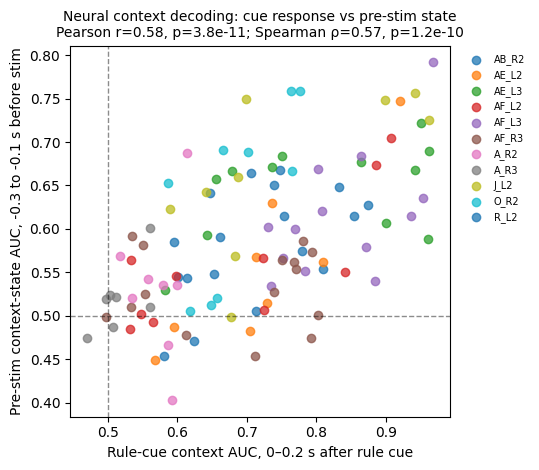

In [220]:
def plot_rulecue_vs_prestim_auc_scatter(
    df,
    x_col="rulecue_auc_0_to_0p2",
    y_col="prestim_auc_minus0p3_to_minus0p1",
    group_col="mouse",
    title="Neural context decoding: cue response vs pre-stim state",
):
    # avoid duplicate columns when group_col is already "mouse", "roi", etc.
    cols = []
    for c in [x_col, y_col, group_col, "mouse", "date", "roi"]:
        if c not in cols and c in df.columns:
            cols.append(c)

    d = df.loc[:, cols].copy()

    # extra safety: remove duplicated column names if any already exist
    d = d.loc[:, ~d.columns.duplicated()].copy()

    d = d[np.isfinite(d[x_col]) & np.isfinite(d[y_col])]

    fig, ax = plt.subplots(figsize=(5.5, 4.8))

    for group, dg in d.groupby(group_col):
        ax.scatter(
            dg[x_col],
            dg[y_col],
            s=36,
            alpha=0.75,
            label=group,
        )

    ax.axvline(0.5, color="k", ls="--", lw=1, alpha=0.45)
    ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.45)

    if len(d) >= 3:
        r, p = stats.pearsonr(d[x_col], d[y_col])
        rho, p_s = stats.spearmanr(d[x_col], d[y_col])
        ax.set_title(
            f"{title}\nPearson r={r:.2f}, p={p:.2g}; Spearman ρ={rho:.2f}, p={p_s:.2g}",
            fontsize=10,
        )
    else:
        ax.set_title(title, fontsize=10)

    ax.set_xlabel("Rule-cue context AUC, 0–0.2 s after rule cue")
    ax.set_ylabel("Pre-stim context-state AUC, -0.3 to -0.1 s before stim")
    ax.legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    return fig, ax


fig, ax = plot_rulecue_vs_prestim_auc_scatter(df_rulecue_vs_prestim_auc)

In [223]:
def plot_rulecue_vs_prestim_auc_scatter_by_perf(
    df,
    x_col="rulecue_auc_0_to_0p2",
    y_col="prestim_auc_minus0p3_to_minus0p1",
    perf_col="perf_mean",
    title="Context decoding: rule cue response vs pre-stim state",
    cmap="viridis",
    vmin=0.5,
    vmax=1.0,
    annotate_mouse=False,
):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    needed = [x_col, y_col, perf_col, "mouse", "date", "roi"]
    needed = [c for c in needed if c in df.columns]

    d = df[needed].copy()
    d = d[
        np.isfinite(d[x_col]) &
        np.isfinite(d[y_col]) &
        np.isfinite(d[perf_col])
    ]

    fig, ax = plt.subplots(figsize=(5.8, 4.9))

    sc = ax.scatter(
        d[x_col],
        d[y_col],
        c=d[perf_col],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )

    ax.axvline(0.5, color="k", ls="--", lw=1, alpha=0.45)
    ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.45)

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Mean training performance\n(visual/auditory average)")

    if len(d) >= 3:
        r, p = stats.pearsonr(d[x_col], d[y_col])
        rho, p_s = stats.spearmanr(d[x_col], d[y_col])
        ax.set_title(
            f"{title}\nPearson r={r:.2f}, p={p:.2g}; Spearman ρ={rho:.2f}, p={p_s:.2g}",
            fontsize=10,
        )
    else:
        ax.set_title(title, fontsize=10)

    ax.set_xlabel("Rule-cue context AUC, 0–0.2 s after rule cue")
    ax.set_ylabel("Pre-stim context-state AUC, -0.3 to -0.1 s before stim")

    if annotate_mouse:
        for _, row in d.iterrows():
            ax.text(
                row[x_col],
                row[y_col],
                row["mouse"],
                fontsize=6,
                alpha=0.7,
            )

    plt.tight_layout()
    return fig, ax

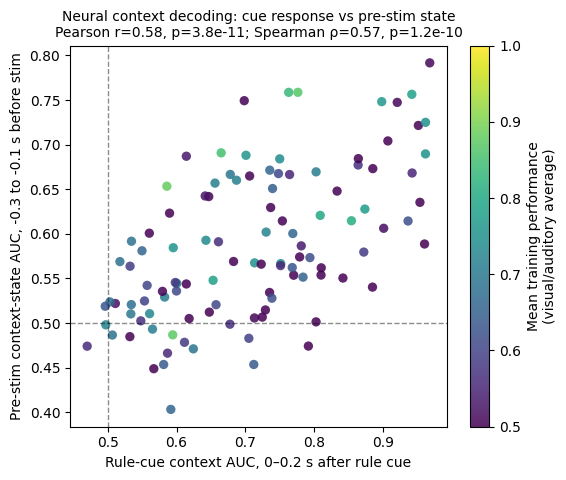

In [265]:
fig, ax = plot_rulecue_vs_prestim_auc_scatter_by_perf(
    df_rulecue_vs_prestim_auc_perf,
    x_col="rulecue_auc_0_to_0p2",
    y_col="prestim_auc_minus0p3_to_minus0p1",
    perf_col="perf_mean",
    title="Neural context decoding: cue response vs pre-stim state",
)

In [266]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\Fig3"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"scatter_prestim_vs_context_cue_neural_decoding.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"scatter_prestim_vs_context_cue_neural_decoding.png"),
                dpi=300, bbox_inches='tight')

In [325]:
import seaborn as sns
from scipy import stats

neural_save_root = r"I:\Cerebellum_Imaging_Dec2025"
face_root = r"I:\Cerebellum_imaging_Dec2025"

window = (0.0, 0.2)
face_filename = "face_ind_roi_decode_ruleCue_times_modality_auc.npz"


def _unwrap_npz_object(obj):
    try:
        return obj.item()
    except Exception:
        return obj


def _metric_mean_in_window(res, key, window):
    if res is None or key not in res or res[key] is None:
        return np.nan
    t = np.asarray(res["timepoints"], dtype=float)
    return mean_in_window(res[key], t, window)


def load_face_decode_res(face_root, mouse, date, region="all", filename=face_filename):
    path = os.path.join(
        face_root, mouse, date, "behavior", "raw_video_data", filename
    )

    if not os.path.exists(path):
        return None, path

    npz = np.load(path, allow_pickle=True)
    key = f"{region}_decode_res"

    if key not in npz.files:
        return None, path

    return _unwrap_npz_object(npz[key]), path


def flatten_face_rulecue_auc_results(
    face_root,
    agg_data,
    mice,
    region="all",
    window=(0.0, 0.2),
    filename=face_filename,
):
    rows = []

    for mouse in mice:
        for date in agg_data[mouse].keys():
            if "training" in date:
                continue

            res, path = load_face_decode_res(
                face_root=face_root,
                mouse=mouse,
                date=date,
                region=region,
                filename=filename,
            )

            if res is None or not isinstance(res, dict) or "timepoints" not in res:
                continue

            face_auc = _metric_mean_in_window(res, "auc", window)
            face_shuf_auc = _metric_mean_in_window(res, "shuf_auc", window)
            face_acc_bal = _metric_mean_in_window(res, "acc_bal", window)
            face_shuf_acc_bal = _metric_mean_in_window(res, "shuf_acc_bal", window)

            rows.append({
                "mouse": mouse,
                "date": date,
                "face_region": region,
                "face_path": path,

                "face_auc_0_to_0p2": face_auc,
                "face_shuf_auc_0_to_0p2": face_shuf_auc,
                "face_auc_minus_shuf": face_auc - face_shuf_auc,

                "face_acc_bal_0_to_0p2": face_acc_bal,
                "face_shuf_acc_bal_0_to_0p2": face_shuf_acc_bal,
                "face_acc_bal_minus_shuf": face_acc_bal - face_shuf_acc_bal,

                "face_baseline": res.get("baseline", np.nan),
                "face_n_trials": (
                    int(np.sum(np.asarray(res["final_trial_mask"], dtype=bool)))
                    if "final_trial_mask" in res else np.nan
                ),
            })

    return pd.DataFrame(rows)


# --- neural context cue decoding, ROI = all ---
df_neural = pd.concat(
    [
        flatten_rulecue_auc_results(
            load_rulecue_auc_results(neural_save_root, mouse)[0],
            mouse=mouse,
            window=window,
            rois_to_keep=["all"],
        )
        for mouse in mice
    ],
    ignore_index=True,
)

# --- face motion context cue decoding, region = all ---
df_face = flatten_face_rulecue_auc_results(
    face_root=face_root,
    agg_data=agg_data,
    mice=mice,
    region="all",
    window=window,
)

# --- merge session by session ---
df_face_neural = df_neural.merge(
    df_face,
    on=["mouse", "date"],
    how="inner",
)

plot_df = df_face_neural.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["face_auc_0_to_0p2", "rulecue_auc_0_to_0p2"]
)

print(f"Matched sessions: {len(plot_df)}")
display(plot_df.head())

Matched sessions: 109


,mouse,date,roi,session_i,rulecue_auc_0_to_0p2,rulecue_shuf_auc_0_to_0p2,rulecue_auc_minus_shuf,rulecue_acc_bal_0_to_0p2,rulecue_shuf_acc_bal_0_to_0p2,rulecue_acc_bal_minus_shuf,...,face_region,face_path,face_auc_0_to_0p2,face_shuf_auc_0_to_0p2,face_auc_minus_shuf,face_acc_bal_0_to_0p2,face_shuf_acc_bal_0_to_0p2,face_acc_bal_minus_shuf,face_baseline,face_n_trials
0,AE_L2,20250612,all,0,0.810238,0.499148,0.311090,0.738095,0.474551,0.263544,...,all,I:\Cerebellum_imaging_Dec2025\AE_L2\20250612\b...,0.801209,0.500315,0.300893,0.739469,0.472874,0.266595,0.538462,130
1,AE_L2,20250624_valvesilent,all,1,0.729123,0.500583,0.228539,0.660221,0.489909,0.170312,...,all,I:\Cerebellum_imaging_Dec2025\AE_L2\20250624_v...,0.802452,0.499482,0.302970,0.735985,0.486040,0.249945,0.503817,262
2,AE_L2,20250701_valvesilent,all,2,0.920644,0.499487,0.421157,0.868017,0.499578,0.368439,...,all,I:\Cerebellum_imaging_Dec2025\AE_L2\20250701_v...,0.891063,0.499774,0.391289,0.846826,0.476612,0.370214,0.508475,295
3,AE_L2,20250708_valvesilent,all,3,0.736764,0.500642,0.236122,0.670538,0.512854,0.157684,...,all,I:\Cerebellum_imaging_Dec2025\AE_L2\20250708_v...,0.792405,0.499443,0.292962,0.724627,0.497672,0.226955,0.503876,258
4,AE_L2,20250715_valvesilent,all,4,0.566994,0.495109,0.071885,0.546413,0.510716,0.035696,...,all,I:\Cerebellum_imaging_Dec2025\AE_L2\20250715_v...,0.612212,0.499590,0.112622,0.583025,0.513540,0.069485,0.501475,339


In [ ]:
def annotate_corr(ax, x, y):
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) >= 3:
        r, p = stats.pearsonr(x[good], y[good])
        rho, ps = stats.spearmanr(x[good], y[good])
        ax.text(
            0.05, 0.95,
            f"Pearson r = {r:.2f}, p = {p:.3g}\nSpearman ρ = {rho:.2f}, p = {ps:.3g}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )


fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
sns.scatterplot(
    data=plot_df,
    x="face_auc_0_to_0p2",
    y="rulecue_auc_0_to_0p2",
    hue="mouse",
    s=55,
    alpha=0.8,
    ax=ax,
)
sns.regplot(
    data=plot_df,
    x="face_auc_0_to_0p2",
    y="rulecue_auc_0_to_0p2",
    scatter=False,
    color="black",
    ax=ax,
)
ax.axvline(0.5, color="0.7", ls="--", lw=1)
ax.axhline(0.5, color="0.7", ls="--", lw=1)
ax.set_xlabel("Face motion context AUC, all PCs, 0-0.2 s")
ax.set_ylabel("Neural context AUC, all neurons, 0-0.2 s")
ax.set_title("Raw AUC")
annotate_corr(
    ax,
    plot_df["face_auc_0_to_0p2"].to_numpy(float),
    plot_df["rulecue_auc_0_to_0p2"].to_numpy(float),
)

ax = axes[1]
plot_df_corr = plot_df.dropna(
    subset=["face_auc_minus_shuf", "rulecue_auc_minus_shuf"]
)

sns.scatterplot(
    data=plot_df_corr,
    x="face_auc_minus_shuf",
    y="rulecue_auc_minus_shuf",
    hue="mouse",
    s=55,
    alpha=0.8,
    legend=False,
    ax=ax,
)
sns.regplot(
    data=plot_df_corr,
    x="face_auc_minus_shuf",
    y="rulecue_auc_minus_shuf",
    scatter=False,
    color="black",
    ax=ax,
)
ax.axvline(0, color="0.7", ls="--", lw=1)
ax.axhline(0, color="0.7", ls="--", lw=1)
ax.set_xlabel("Face motion AUC - shuffle, 0-0.2 s")
ax.set_ylabel("Neural AUC - shuffle, 0-0.2 s")
ax.set_title("Shuffle-corrected")
annotate_corr(
    ax,
    plot_df_corr["face_auc_minus_shuf"].to_numpy(float),
    plot_df_corr["rulecue_auc_minus_shuf"].to_numpy(float),
)

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.05, 1), frameon=False)
plt.show()

In [244]:
np.array(agg_data['AE_L3']['20250903_valvesilent']['arm1']['table_for_img']['stimOn_times'])

array([  101.,   202.,   279.,   350.,   505.,   577.,   645.,   750.,
         820.,   886.,   998.,  1089.,  1203.,  1290.,  1410.,  1515.,
        1581.,  1685.,  1758.,  1904.,  2057.,  2175.,  2244.,  2364.,
        2473.,  2595.,  2662.,  2755.,  2833.,  2971.,  3051.,  3156.,
        3276.,  3393.,  3505.,  3620.,  3688.,  3846.,  3956.,  4080.,
        4155.,  4231.,  4299.,  4403.,  4471.,  4604.,  4672.,  4784.,
        4902.,  5016.,  5082.,  5193.,  5307.,  5435.,  5504.,  5643.,
        5710.,  5856.,  5929.,  6003.,  6111.,  6182.,  6316.,  6389.,
        6497.,  6644.,  6716.,  6804.,  6910.,  7043.,  7113.,  7250.,
        7355.,  7525.,  7596.,  7662.,  7728.,  7903.,  8012.,  8099.,
        8199.,  8318.,  8392.,  8464.,  8532.,  8605.,  8675.,  8781.,
        8897.,  9045.,  9118.,  9218.,  9312.,  9414.,  9532.,  9681.,
        9751.,  9892.,  9994., 10107., 10236., 10363., 10431., 10584.,
       10676., 10759., 10844., 10954., 11073., 11160., 11291., 11361.,
      

In [258]:
align_pred = 'stimOn_times'
preds_to_exclude = ['vis_ruleCue_times', 'aud_ruleCue_times'
'left_vis_stimOn_times',
    'right_vis_stimOn_times',
    'left_aud_stimOn_times',
    'right_aud_stimOn_times',]
label_key = 'modality'
mouse = 'AE_L2'
date = '20250701_valvesilent'
out_by_roi, meta = population_decode_timecourse_session_by_roi(
    agg_data,
    mouse,
    date,
    predictors,
    preds_to_exclude,
    psth_time_start,
    psth_time_end,
    align_pred = align_pred,
    roi_masks_full = roi_masks_full,          # REQUIRED for ROI decoding
    frac_thresh=0.2,
    roi_order=None,

    label_key=label_key,
    custom_labels=None,
    trial_mask=None,
    frames_per_s=15,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=5000,
    return_tensor=False,
    do_shuffle=True,
    require_reward_psth=False,
)

[  279.   433.   512.   663.   924.  1188.  1336.  1484.  1575.  1739.
  1835.  1933.  2078.  2179.  2320.  2491.  2589.  2859.  3014.  3157.
  3289.  3383.  3502.  3632.  3759.  3902.  4069.  4191.  4314.  4460.
  4678.  4960.  5146.  5337.  5499.  5595.  5732.  5951.  6141.  6333.
  6546.  6802.  6952.  7315.  7579.  7747.  7873.  7976.  8087.  8182.
  8340.  8476.  8640.  8759.  8897.  8993.  9102.  9251.  9397.  9484.
  9605.  9727.  9832.  9954. 10087. 10207. 10304. 10404. 10540. 10660.
 10854. 11047. 11163. 11298. 11429. 11579. 11686. 11924. 12091. 12387.
 12623. 12780. 13023. 13161. 13297. 13473. 13651. 13794. 13935. 14067.
 14180. 14282. 14386. 14514. 14677. 14820. 14950. 15051. 15208. 15359.
 15460. 15570. 15669. 15772. 15890. 16002. 16075. 16154. 16240. 16320.
 16431. 16545. 16670. 16796. 16984. 17177. 17342. 17449. 17654. 17801.
 17908. 18014. 18095. 18210. 18406. 18598. 18700. 18823. 18954. 19074.
 19169. 19266. 19370. 19467. 19568. 19742. 19852. 19950. 20092. 20193.
 20287

In [322]:
res= motion_decode_timecourse_session(
    agg_data,
    mouse='AE_L2',
    date='20250624_valvesilent',
    motion_key='face_motion',
    psth_time_start=-0.4,
    psth_time_end=1.2,
    align_pred='ruleCue_times',
    SVD_comp_idxs= None,
    label_key='modality',   # or 'choice'
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    do_shuffle=True,
    auc_n_shuffles=100,
    compute_auc=True,
    compute_accuracy=True,
)

(262, 97, 500)


<Axes: xlabel='Time (ms)', ylabel='ROC AUC'>

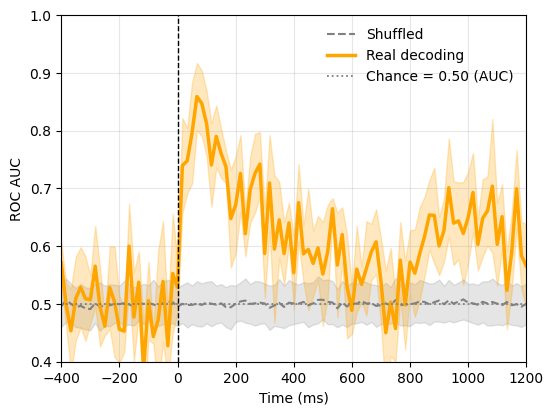

In [323]:
fig, ax = plt.subplots(figsize=(6, 4.5))
#plot_decoding_accuracy(out_by_roi['all'], ax=ax, title='context decoding from neuron stimulus response all', time_range_ms=(-400, 1200), metric = 'auc',color = 'blue')
plot_decoding_accuracy(res, ax=ax, time_range_ms=(-400, 1200), metric = 'auc',color = 'orange')

In [264]:
svg_out_dir = r"I:\Cerebellum_imaging_Dec2025\pub_fig\Fig3"
os.makedirs(svg_out_dir, exist_ok=True)

fig.savefig(
    os.path.join(svg_out_dir,f"example_decoding_context_stimOn_aligned_neural_vs_face.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

fig.savefig(os.path.join(svg_out_dir, f"example_decoding_context_stimOn_aligned_neural_vs_face.png"),
                dpi=300, bbox_inches='tight')

In [252]:
out_by_roi['all']['auc']

array([7.76091954e-01, 7.34988506e-01, 7.36367816e-01, 6.63494253e-01,
       6.32689655e-01, 6.87126437e-01, 1.56321839e-03, 0.00000000e+00,
       4.59770115e-05, 8.27586207e-04, 5.51724138e-04, 8.19586207e-01,
       7.56045977e-01, 7.63954023e-01, 6.70068966e-01, 7.04091954e-01,
       6.03770115e-01, 6.24827586e-01, 6.47678161e-01, 6.18574713e-01,
       6.03310345e-01, 5.81379310e-01, 5.31816092e-01, 5.78022989e-01,
       6.32137931e-01])

In [317]:
from scipy.stats import pearsonr, spearmanr
def _date_base(date):
    # handles dates like "20250701_valvesilent"
    return str(date).split("_")[0]


def _get_session_perf(mouse_data, date):
    """Return visual/auditory behavioral accuracy for this imaging session if available."""
    out = {"vis_perf": np.nan, "aud_perf": np.nan}

    if "training" not in mouse_data:
        return out

    tr = mouse_data["training"]
    if not all(k in tr for k in ["training_dates", "accuracies_vis", "accuracies_aud"]):
        return out

    training_dates = np.asarray(tr["training_dates"]).astype(str)
    base = _date_base(date)

    idx = np.where(training_dates == base)[0]
    if len(idx) == 0:
        return out

    i = idx[0]
    out["vis_perf"] = float(np.asarray(tr["accuracies_vis"])[i])
    out["aud_perf"] = float(np.asarray(tr["accuracies_aud"])[i])
    return out


def _find_beta_key(neuron, candidates):
    """
    candidates should be predictor base names, e.g.
    ['vis_ruleCue_times'] or ['left_vis_stimOn_times', 'vis_left_stimOn_times'].
    """
    for c in candidates:
        key = c if c.endswith("_beta") else c + "_beta"
        if key in neuron:
            return key
    return None


def _beta_to_scalar(beta, mode="mean"):
    """
    Convert time-shifted beta kernel into one scalar per dendrite.

    mode:
        'mean'        : mean signed beta across kernel lags
        'peak_signed' : beta value at max absolute magnitude
        'mean_abs'    : mean absolute beta
        'max'         : max beta
        'min'         : min beta
    """
    b = np.asarray(beta, dtype=float).ravel()
    b = b[np.isfinite(b)]

    if b.size == 0:
        return np.nan

    if mode == "mean":
        return float(np.nanmean(b))
    elif mode == "peak_signed":
        return float(b[np.nanargmax(np.abs(b))])
    elif mode == "mean_abs":
        return float(np.nanmean(np.abs(b)))
    elif mode == "max":
        return float(np.nanmax(b))
    elif mode == "min":
        return float(np.nanmin(b))
    else:
        raise ValueError(f"Unknown beta scalarization mode: {mode}")


def collect_sessionwise_beta_pair(
    agg_data,
    x_candidates,
    y_candidates,
    mouse_ids=None,
    arms=("arm1", "arm2"),
    beta_mode="mean",
    session_agg="mean",
    min_neurons=10,
):
    """
    Each returned row is one mouse-session.

    x = session-averaged rule cue beta
    y = session-averaged left stimulus beta
    """
    rows = []

    if mouse_ids is None:
        mouse_ids = list(agg_data.keys())

    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]

        dates = [
            d for d in mouse_data.keys()
            if d != "training" and isinstance(mouse_data[d], dict)
        ]
        dates = sorted(dates, key=lambda x: _date_base(x))

        for sess_i, date in enumerate(dates):
            x_vals = []
            y_vals = []

            for arm in arms:
                if arm not in mouse_data[date]:
                    continue

                neurons = mouse_data[date][arm]["stat"]

                for neuron in neurons:
                    x_key = _find_beta_key(neuron, x_candidates)
                    y_key = _find_beta_key(neuron, y_candidates)

                    if x_key is None or y_key is None:
                        continue

                    x = _beta_to_scalar(neuron[x_key], mode=beta_mode)
                    y = _beta_to_scalar(neuron[y_key], mode=beta_mode)

                    if np.isfinite(x) and np.isfinite(y):
                        x_vals.append(x)
                        y_vals.append(y)

            if len(x_vals) < min_neurons:
                continue

            if session_agg == "mean":
                x_session = float(np.nanmean(x_vals))
                y_session = float(np.nanmean(y_vals))
            elif session_agg == "median":
                x_session = float(np.nanmedian(x_vals))
                y_session = float(np.nanmedian(y_vals))
            else:
                raise ValueError("session_agg must be 'mean' or 'median'")

            perf = _get_session_perf(mouse_data, date)

            rows.append({
                "mouse": mouse,
                "date": date,
                "session_idx": sess_i,
                "x_beta": x_session,
                "y_beta": y_session,
                "n_neurons": len(x_vals),
                **perf,
            })

    return pd.DataFrame(rows)


def _scatter_one(ax, df, title, x_label, y_label, color_col=None):
    plot_df = df.copy()

    if color_col is not None and color_col in plot_df and plot_df[color_col].notna().any():
        c = plot_df[color_col]
        sc = ax.scatter(
            plot_df["x_beta"],
            plot_df["y_beta"],
            c=c,
            s=45,
            alpha=0.8,
            edgecolor="none",
        )
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(color_col)
    else:
        ax.scatter(
            plot_df["x_beta"],
            plot_df["y_beta"],
            s=45,
            alpha=0.8,
            edgecolor="none",
        )

    ax.axhline(0, color="0.8", lw=1)
    ax.axvline(0, color="0.8", lw=1)

    # regression line
    x = plot_df["x_beta"].to_numpy(dtype=float)
    y = plot_df["y_beta"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    if np.sum(ok) >= 3:
        coef = np.polyfit(x[ok], y[ok], deg=1)
        xx = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), 100)
        yy = coef[0] * xx + coef[1]
        ax.plot(xx, yy, color="black", lw=1.5)

        r, p = pearsonr(x[ok], y[ok])
        rho, p_s = spearmanr(x[ok], y[ok])
        ax.text(
            0.05, 0.95,
            f"Pearson r = {r:.2f}, p = {p:.3g}\n"
            f"Spearman ρ = {rho:.2f}, p = {p_s:.3g}\n"
            f"n sessions = {np.sum(ok)}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


def plot_rulecue_vs_leftstim_beta_scatter(
    agg_data,
    mouse_ids=None,
    beta_mode="mean",
    session_agg="mean",
    min_neurons=10,
):
    """
    Makes two scatter plots:

    Plot 1:
        x = visual rule cue beta
        y = left visual stimulus beta

    Plot 2:
        x = auditory rule cue beta
        y = left auditory stimulus beta
    """

    df_vis = collect_sessionwise_beta_pair(
        agg_data,
        x_candidates=["vis_ruleCue_times"],
        y_candidates=["left_vis_stimOn_times", "vis_left_stimOn_times"],
        mouse_ids=mouse_ids,
        beta_mode=beta_mode,
        session_agg=session_agg,
        min_neurons=min_neurons,
    )

    df_aud = collect_sessionwise_beta_pair(
        agg_data,
        x_candidates=["aud_ruleCue_times"],
        y_candidates=["left_aud_stimOn_times", "aud_left_stimOn_times"],
        mouse_ids=mouse_ids,
        beta_mode=beta_mode,
        session_agg=session_agg,
        min_neurons=min_neurons,
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

    _scatter_one(
        axes[0],
        df_vis,
        title="Visual sessions: rule cue vs left visual stimulus beta",
        x_label="Session mean visual rule cue beta",
        y_label="Session mean left visual stimulus beta",
        color_col="vis_perf",
    )

    _scatter_one(
        axes[1],
        df_aud,
        title="Auditory sessions: rule cue vs left auditory stimulus beta",
        x_label="Session mean auditory rule cue beta",
        y_label="Session mean left auditory stimulus beta",
        color_col="aud_perf",
    )

    return fig, axes, df_vis, df_aud

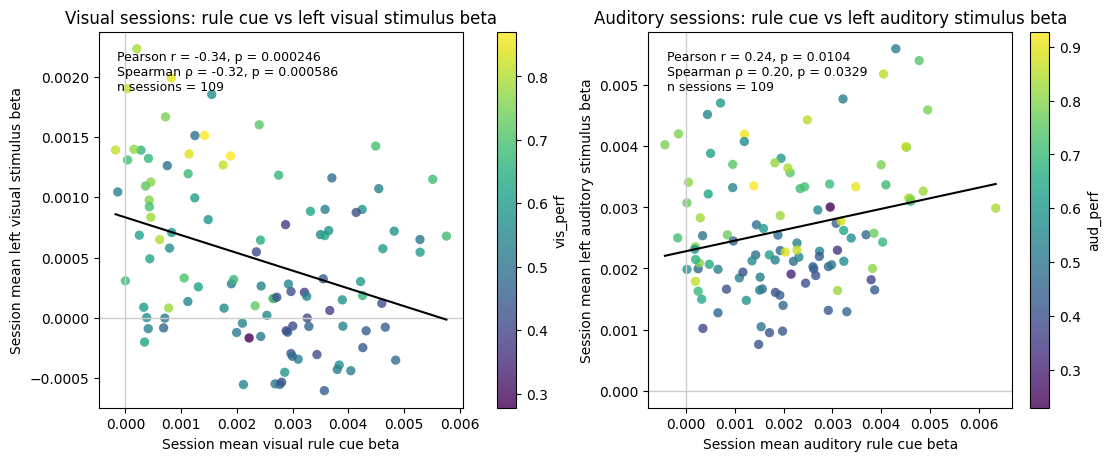

In [318]:
fig, axes, df_vis, df_aud = plot_rulecue_vs_leftstim_beta_scatter(
    agg_data,
    mouse_ids=mouse_ids,      # or None for all mice in agg_data
    beta_mode="mean",         # try "peak_signed" too
    session_agg="mean",
    min_neurons=20,
)

In [327]:
RULECUE_PREDS = ["vis_ruleCue_times", "aud_ruleCue_times"]


def _window_mask(t, window, inclusive=True):
    t = np.asarray(t, dtype=float)
    if inclusive:
        return (t >= window[0]) & (t <= window[1])
    return (t >= window[0]) & (t < window[1])


def _zscore_cols(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x, axis=0, keepdims=True)
    sd = np.nanstd(x, axis=0, keepdims=True)
    sd = np.where(sd == 0, 1.0, sd)
    return (x - mu) / sd


def collect_trialwise_context_response_one_session(
    agg_data,
    mouse,
    date,
    predictors,
    dff_root=None,
    align_pred="ruleCue_times",
    retained_predictors=RULECUE_PREDS,
    tensor_window=(-0.4, 1.2),
    response_window=(0.0, 0.2),
    img_frames_per_s=15,
    video_frames_per_s=60,
    face_comp_idxs=np.arange(30),
    zscore_motion=True,
    motion_amp_mode="rms",   # "rms" or "mean_abs"
):
    session = agg_data[mouse][date]

    # -------------------------
    # Neural: rule-cue-retained residual response
    # -------------------------
    neural_arm_rows = []

    for arm in ("arm1", "arm2"):
        if arm not in session:
            continue

        arm_session = session[arm]
        neurons = list(arm_session["stat"])
        if len(neurons) == 0:
            continue

        table_img = add_common_event_columns(arm_session["table_for_img"])
        design_matrix = arm_session["design_matrix"]

        dff_path = _resolve_dff_path(
            mouse=mouse,
            date=date,
            arm=arm,
            dff_root=dff_root,
        )
        dff = np.load(dff_path)

        rt, psth_frame_idx, event_trial_mask = build_residual_tensor(
            neurons=neurons,
            dff=dff,
            design_matrix=design_matrix,
            predictors=predictors,
            table_for_img=table_img,
            preds_to_exclude=retained_predictors,
            psth_time_start=tensor_window[0],
            psth_time_end=tensor_window[1],
            align_pred=align_pred,
            frames_per_s=img_frames_per_s,
        )

        t_img = np.linspace(tensor_window[0], tensor_window[1], rt.shape[2])
        w_img = _window_mask(t_img, response_window)

        trial_idx = np.flatnonzero(np.asarray(event_trial_mask, dtype=bool))
        if len(trial_idx) != rt.shape[1]:
            raise ValueError(
                f"{mouse} {date} {arm}: trial mask length does not match residual tensor."
            )

        vals = rt[:, :, w_img]  # neurons x trials x time

        # True pooled mean across all neurons and time bins.
        response_sum = np.nansum(vals, axis=(0, 2))
        response_n = np.sum(np.isfinite(vals), axis=(0, 2))

        # Optional magnitude version, useful if positive/negative neurons cancel.
        response_abs_sum = np.nansum(np.abs(vals), axis=(0, 2))

        neural_arm_rows.append(pd.DataFrame({
            "mouse": mouse,
            "date": date,
            "trial_idx": trial_idx,
            "arm": arm,
            "neural_response_sum": response_sum,
            "neural_response_abs_sum": response_abs_sum,
            "neural_response_n": response_n,
            "n_neurons_arm": rt.shape[0],
        }))

    if len(neural_arm_rows) == 0:
        return pd.DataFrame()

    neural_long = pd.concat(neural_arm_rows, ignore_index=True)

    neural = (
        neural_long
        .groupby(["mouse", "date", "trial_idx"], as_index=False)
        .agg(
            neural_response_sum=("neural_response_sum", "sum"),
            neural_response_abs_sum=("neural_response_abs_sum", "sum"),
            neural_response_n=("neural_response_n", "sum"),
            n_neurons=("n_neurons_arm", "sum"),
        )
    )

    neural["context_response_mean"] = (
        neural["neural_response_sum"] / neural["neural_response_n"]
    )
    neural["context_response_absmean"] = (
        neural["neural_response_abs_sum"] / neural["neural_response_n"]
    )

    # Add trial metadata from arm1 imaging table.
    table_ref = add_common_event_columns(session["arm1"]["table_for_img"])
    for col in ["modality", "choice", "feedbackType"]:
        if col in table_ref.columns:
            arr = table_ref[col].to_numpy()
            neural[col] = arr[neural["trial_idx"].to_numpy()]

    # -------------------------
    # Face motion: "all" = face_motion top 30 comps, same as previous control
    # -------------------------
    table_video = session["table_for_video"].copy()
    motion = np.asarray(session["face_motion"], dtype=float)

    if face_comp_idxs is not None:
        motion = motion[:, np.asarray(face_comp_idxs, dtype=int)]

    if zscore_motion:
        motion = _zscore_cols(motion)

    motion_tensor, motion_frame_idx, video_trial_mask = build_motion_tensor(
        motion=motion,
        table_for_video=table_video,
        psth_time_start=tensor_window[0],
        psth_time_end=tensor_window[1],
        align_pred=align_pred,
        frames_per_s=video_frames_per_s,
    )

    t_video = np.linspace(tensor_window[0], tensor_window[1], motion_tensor.shape[2])
    w_video = _window_mask(t_video, response_window)

    video_trial_idx = np.flatnonzero(np.asarray(video_trial_mask, dtype=bool))
    M = motion_tensor[:, :, w_video]  # comps x trials x time

    if motion_amp_mode == "rms":
        face_amp = np.sqrt(np.nanmean(M ** 2, axis=(0, 2)))
    elif motion_amp_mode == "mean_abs":
        face_amp = np.nanmean(np.abs(M), axis=(0, 2))
    else:
        raise ValueError("motion_amp_mode must be 'rms' or 'mean_abs'.")

    face = pd.DataFrame({
        "mouse": mouse,
        "date": date,
        "trial_idx": video_trial_idx,
        "face_motion_amp": face_amp,
        "n_face_components": motion_tensor.shape[0],
    })

    # -------------------------
    # Merge by original trial index
    # -------------------------
    df = neural.merge(
        face,
        on=["mouse", "date", "trial_idx"],
        how="inner",
    )

    return df

In [328]:
def collect_trialwise_context_face_all(
    agg_data,
    mice,
    predictors,
    dff_root=None,
    **kwargs,
):
    rows = []

    for mouse in mice:
        for date in agg_data[mouse].keys():
            if "training" in date:
                continue

            try:
                df_sess = collect_trialwise_context_response_one_session(
                    agg_data=agg_data,
                    mouse=mouse,
                    date=date,
                    predictors=predictors,
                    dff_root=dff_root,
                    **kwargs,
                )
                if len(df_sess) > 0:
                    rows.append(df_sess)
                    print(f"[ok] {mouse} {date}: {len(df_sess)} trials")
            except Exception as e:
                print(f"[skip] {mouse} {date}: {repr(e)}")

    if len(rows) == 0:
        return pd.DataFrame()

    df = pd.concat(rows, ignore_index=True)

    # Useful for pooled trial-level plots without session/mouse scale offsets.
    for col in ["context_response_mean", "context_response_absmean", "face_motion_amp"]:
        df[f"{col}_z_session"] = (
            df.groupby(["mouse", "date"])[col]
              .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
        )

    df["modality_name"] = df["modality"].map({0: "visual", 1: "auditory"})

    return df


df_trial = collect_trialwise_context_face_all(
    agg_data=agg_data,
    mice=mice,
    predictors=predictors,
    dff_root=None,  # or your dff_root
)

display(df_trial.head())

(130, 97, 30)
[ok] AE_L2 20250612: 130 trials
(262, 97, 30)
[ok] AE_L2 20250624_valvesilent: 262 trials
(295, 97, 30)
[ok] AE_L2 20250701_valvesilent: 295 trials
(258, 97, 30)
[ok] AE_L2 20250708_valvesilent: 258 trials
(339, 97, 30)
[ok] AE_L2 20250715_valvesilent: 339 trials
(326, 97, 30)
[ok] AE_L2 20250729_valvesilent: 326 trials
(312, 97, 30)
[ok] AE_L2 20250814_valvesilent_punishsilent: 312 trials
(254, 97, 30)
[ok] AE_L2 20250821_valvesilent_punishsilent: 254 trials
(248, 97, 30)
[ok] AE_L3 20250612: 248 trials
(320, 97, 30)
[ok] AE_L3 20250617_valvesilent: 320 trials
(301, 97, 30)
[ok] AE_L3 20250624_valvesilent: 301 trials
(367, 97, 30)
[ok] AE_L3 20250701_valvesilent: 367 trials
(323, 97, 30)
[ok] AE_L3 20250708_valvesilent: 323 trials
(373, 97, 30)
[ok] AE_L3 20250722_valvesilent: 373 trials
(397, 97, 30)
[ok] AE_L3 20250729_valvesilent: 397 trials
(391, 97, 30)
[ok] AE_L3 20250812_valvesilent: 391 trials
(341, 97, 30)
[ok] AE_L3 20250820_valvesilent: 341 trials
(321, 97, 30

,mouse,date,trial_idx,neural_response_sum,neural_response_abs_sum,neural_response_n,n_neurons,context_response_mean,context_response_absmean,modality,choice,feedbackType,face_motion_amp,n_face_components,context_response_mean_z_session,context_response_absmean_z_session,face_motion_amp_z_session,modality_name
0,AE_L2,20250612,0,872.441564,933.124495,4296,1074,0.203082,0.217208,0,1,-1,4.005210,30,-0.289459,-0.164706,2.073151,visual
1,AE_L2,20250612,1,864.691932,915.623657,4296,1074,0.201278,0.213134,0,1,-1,3.292793,30,-0.348484,-0.305225,1.294062,visual
2,AE_L2,20250612,2,1065.288575,1084.118708,4296,1074,0.247972,0.252355,0,1,1,2.786948,30,1.179352,1.047674,0.740878,visual
3,AE_L2,20250612,3,994.130976,1038.980888,4296,1074,0.231409,0.241848,0,1,1,2.001740,30,0.637383,0.685248,-0.117815,visual
4,AE_L2,20250612,4,926.962166,978.909505,4296,1074,0.215773,0.227865,0,1,-1,2.165811,30,0.125795,0.202916,0.061611,visual


c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

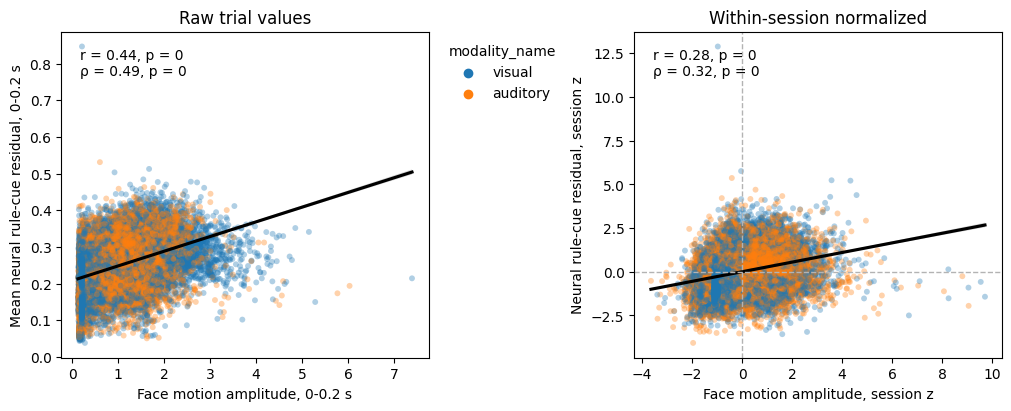

In [329]:
def _annotate_corr(ax, data, x, y):
    d = data[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) >= 3:
        r, p = stats.pearsonr(d[x], d[y])
        rho, ps = stats.spearmanr(d[x], d[y])
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}, p = {p:.2g}\nρ = {rho:.2f}, p = {ps:.2g}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )


plot_df = df_trial.dropna(
    subset=["face_motion_amp", "context_response_mean"]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
sns.scatterplot(
    data=plot_df,
    x="face_motion_amp",
    y="context_response_mean",
    hue="modality_name",
    s=18,
    alpha=0.35,
    linewidth=0,
    ax=ax,
)
sns.regplot(
    data=plot_df,
    x="face_motion_amp",
    y="context_response_mean",
    scatter=False,
    color="black",
    ax=ax,
)
ax.set_xlabel("Face motion amplitude, 0-0.2 s")
ax.set_ylabel("Mean neural rule-cue residual, 0-0.2 s")
ax.set_title("Raw trial values")
_annotate_corr(ax, plot_df, "face_motion_amp", "context_response_mean")

ax = axes[1]
sns.scatterplot(
    data=plot_df,
    x="face_motion_amp_z_session",
    y="context_response_mean_z_session",
    hue="modality_name",
    s=18,
    alpha=0.35,
    linewidth=0,
    legend=False,
    ax=ax,
)
sns.regplot(
    data=plot_df,
    x="face_motion_amp_z_session",
    y="context_response_mean_z_session",
    scatter=False,
    color="black",
    ax=ax,
)
ax.axvline(0, color="0.7", ls="--", lw=1)
ax.axhline(0, color="0.7", ls="--", lw=1)
ax.set_xlabel("Face motion amplitude, session z")
ax.set_ylabel("Neural rule-cue residual, session z")
ax.set_title("Within-session normalized")
_annotate_corr(ax, plot_df, "face_motion_amp_z_session", "context_response_mean_z_session")

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1), frameon=False)
plt.show()